# Ordinal (cumulative-link) regression — raw-data refit

This notebook refits the cumulative-link (ordered logit) regression models for frog call intensity **using raw (non-detrended) covariates**.

For each species we fit:
1. A model using **all available hours**.
2. A model using an **expected calling window** based on (i) removing daytime hours and (ii) removing long stretches of no calling (≥2 days).

We compare **linear predictors** vs **spline predictors** for temperature and humidity, then evaluate:
- AIC
- blocked time-series cross-validation
- out-of-sample ordinal predictive performance (log-likelihood + $R^2$ on expected level)

The notebook also includes diagnostics, prediction curves, parameter summaries, and **ALE/PDP** plots.

Finally, we include a pragmatic joint model using a shared latent activity index.

# TEMP and RH_Z for Linear modellll

## 0. Setup & configuration

In [66]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import warnings
from zoneinfo import ZoneInfo

from patsy import dmatrix
from patsy.builtins import Q
from statsmodels.miscmodels.ordinal_model import OrderedModel
from astral import LocationInfo
from astral.sun import sun

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(linewidth=150)
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

# ── Plot style (adapted from data_analysis_df2020.ipynb) ─────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

COLORS = {
    "gastro": "#1f77b4",
    "oreo": "#ff7f0e",
    "both": "#2ca02c",
    "temp": "#d62728",
    "rh": "#9467bd",
}

SPECIES = ["Gastrotheca chrysosticta", "Oreobates berdemenos"]
SP_SHORT = {
    "Gastrotheca chrysosticta": "G. chrysosticta",
    "Oreobates berdemenos": "O. berdemenos",
}
SP_COLOR = {
    "Gastrotheca chrysosticta": COLORS["gastro"],
    "Oreobates berdemenos": COLORS["oreo"],
}

PLOT_DIR = Path("plots_ordinal_normalised")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


Fig_counter = {'i':1}
def savefig(fig, name, format="pdf"):
    """Save figure in requested formats with tight bbox."""
    count = Fig_counter['i']
    count_str = f"{count:03d}"  # zero-pad to 3 digits (e.g. 001, 042, 123)
    fig.savefig(PLOT_DIR / f"{count_str}_{name}.{format}", bbox_inches="tight")
    print(f"  ✓ Saved: {count_str}_{name}.{format} ")
    Fig_counter['i'] += 1

print("Setup complete. Plots will be saved to:", PLOT_DIR.resolve())

Setup complete. Plots will be saved to: /Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/arunan/Coding/yungas_aruna/Gastros_helechos/Granger_causality/plots_ordinal_normalised


## 1. Load data

In [67]:
# Path used in the existing notebooks
PT_drive = "/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/arunan/Martin_google_drive"
DATA_PATH = f"{PT_drive}/df_helechos_with2020.csv"

df = pd.read_csv(DATA_PATH)
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
df = df.set_index("DateTime").sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Shape: (13257, 8)
Date range: 2018-09-02 00:00:00 → 2020-07-18 23:00:00


,Date,Month,Day,hour,Temp,RH%,Gastrotheca chrysosticta,Oreobates berdemenos
DateTime,,,,,,,,
2018-09-02 00:00:00,2018-09-02,9,245,0,4.553,100.0,0,0
2018-09-02 01:00:00,2018-09-02,9,245,1,4.051,100.0,0,0
2018-09-02 02:00:00,2018-09-02,9,245,2,4.553,100.0,0,0
2018-09-02 03:00:00,2018-09-02,9,245,3,3.550,100.0,0,0
2018-09-02 04:00:00,2018-09-02,9,245,4,3.048,100.0,0,0


## 2. Basic cleaning + core time features

In [68]:
# Ensure required columns exist
required_cols = SPECIES + ["Temp", "RH%"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.copy()
df["hour"] = df.index.hour
df["doy"] = df.index.dayofyear
df["Month"] = df.get("Month", df.index.month)

# Localize to site timezone if naive (assumes timestamps are local time)
SITE_TZ = "America/La_Paz"
if df.index.tz is None:
    df = df.tz_localize(ZoneInfo(SITE_TZ))
else:
    df = df.tz_convert(ZoneInfo(SITE_TZ))

# Coerce to numeric where needed
for c in required_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df[required_cols].isna().sum())

Gastrotheca chrysosticta       0
Oreobates berdemenos           0
Temp                           0
RH%                         1954
dtype: int64


## 3. Expected calling windows (sunrise/sunset + no-calling stretches)
We define expected calling windows by removing:
- long stretches with no calling from either species (\u22652 days),
- hours outside species-specific windows relative to **sunrise/sunset**.

For each species, we estimate how many hours **before sunset** and **after sunrise** calls are typically observed and keep only those hours.

In [69]:
# filter out days of year
# Day-of-year removal windows (inclusive)
SPECIES_DOY_REMOVE = {
    "Gastrotheca chrysosticta": (25, 100),
    "Oreobates berdemenos": (25, 270),
}
# filter out times of day
# Time-of-day removal windows (inclusive)
SPECIES_TOD_REMOVE = {
    "Gastrotheca chrysosticta": (9, 17),  
    "Oreobates berdemenos": (8, 17),  
}


  ✓ Saved: 001_dict_filter_doy_gastrotheca.pdf 


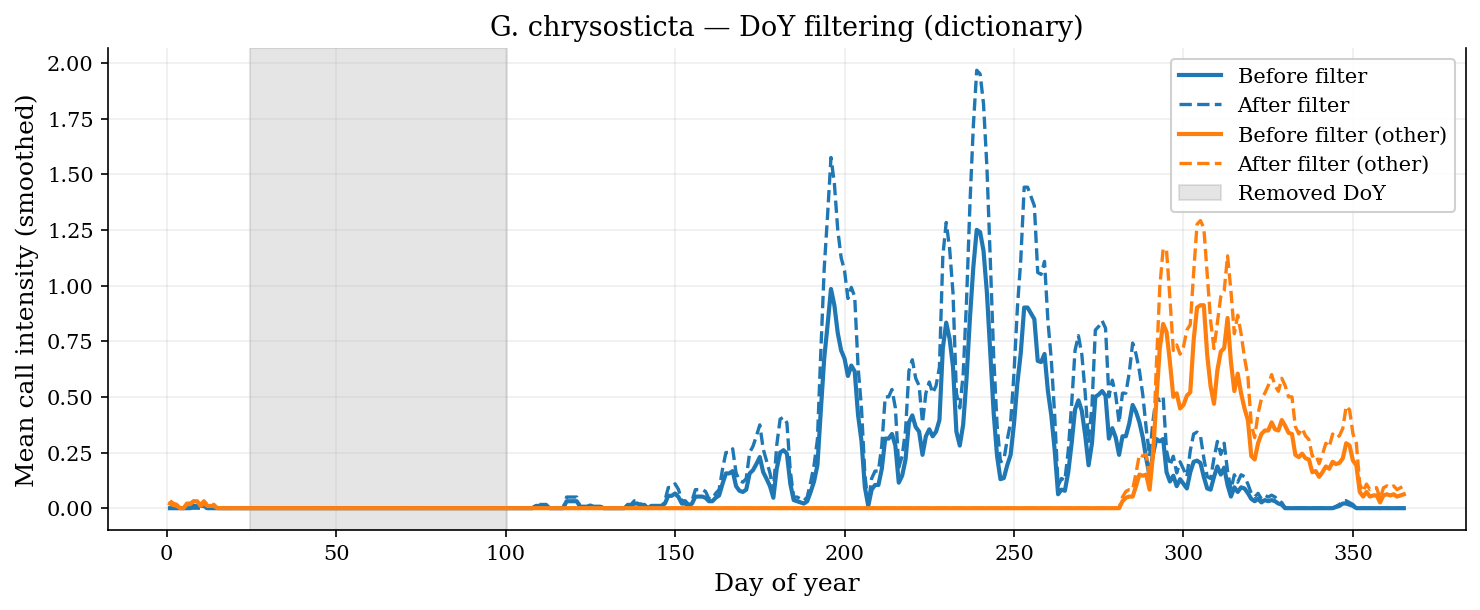

  ✓ Saved: 002_dict_filter_tod_gastrotheca.pdf 


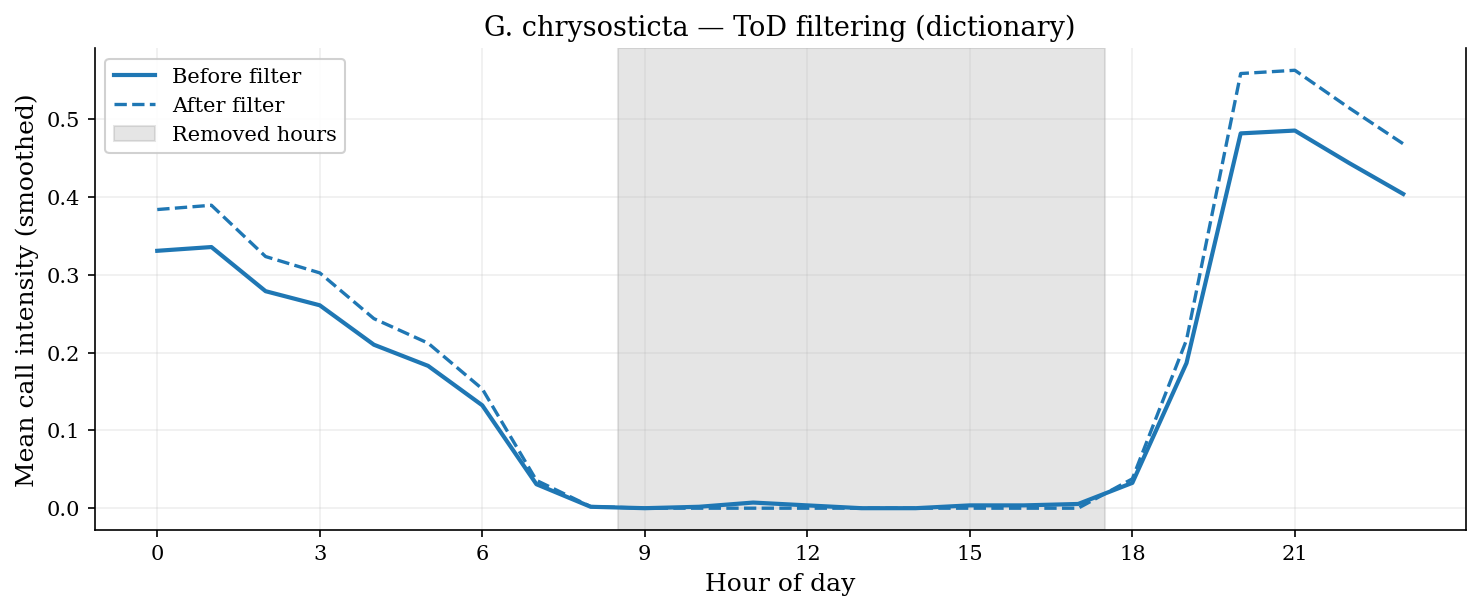

  ✓ Saved: 003_dict_filter_doy_oreobates.pdf 


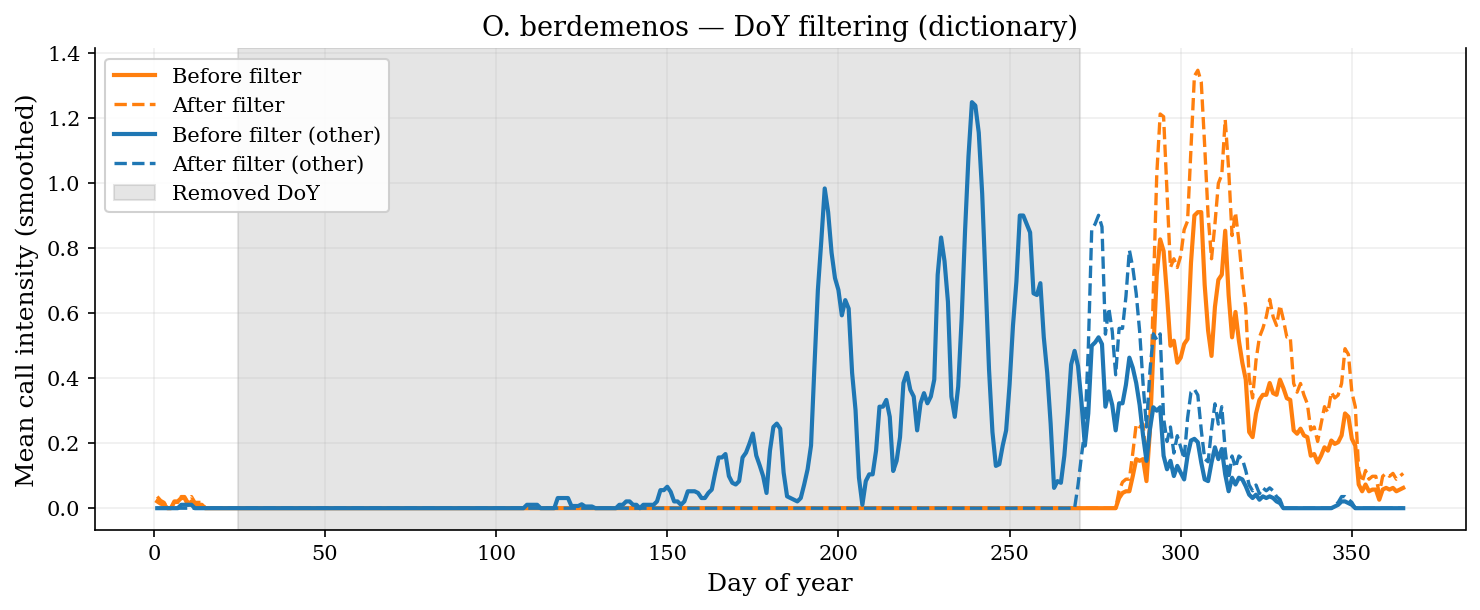

  ✓ Saved: 004_dict_filter_tod_oreobates.pdf 


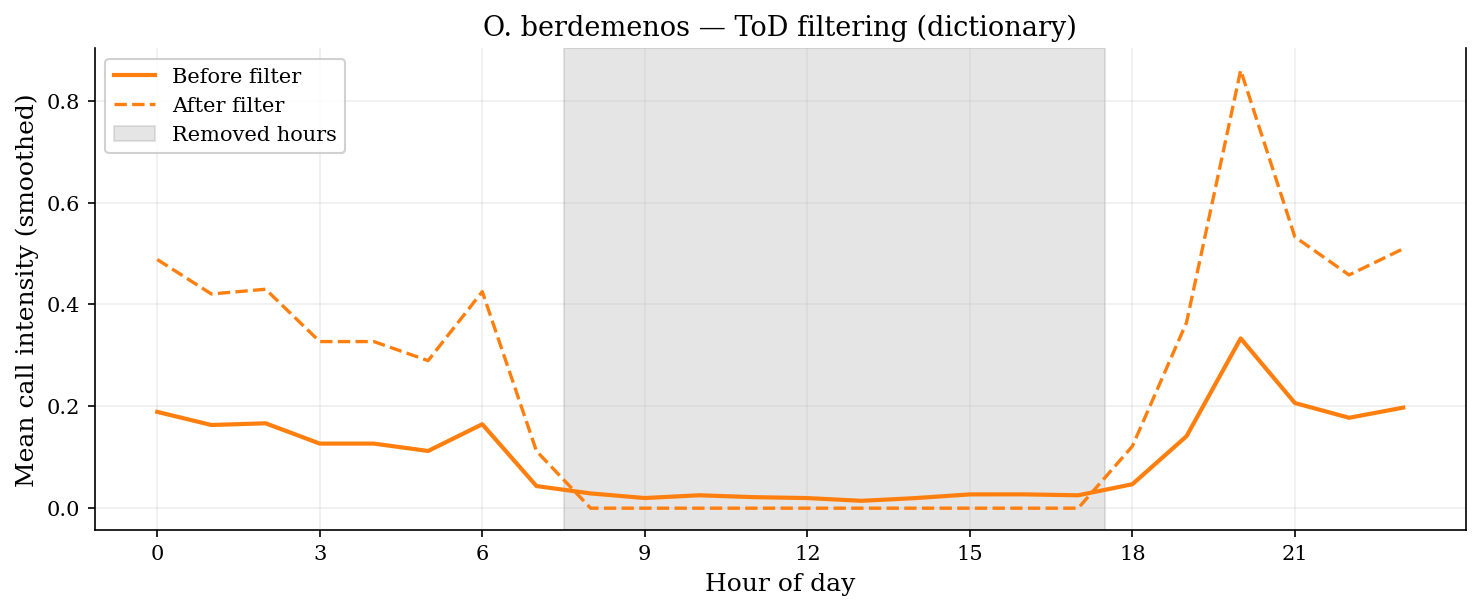

In [70]:
# Dictionary-based filtering (DoY + ToD)
def _smooth_series(s: pd.Series, window: int) -> pd.Series:
    return s.rolling(window=window, center=True, min_periods=1).mean()

def apply_dict_filters(df_in: pd.DataFrame, sp: str):
    doy_start, doy_end = SPECIES_DOY_REMOVE.get(sp, (1, 366))
    tod_start, tod_end = SPECIES_TOD_REMOVE.get(sp, (0, 23))

    doy_mask = (df_in.index.dayofyear >= doy_start) & (df_in.index.dayofyear <= doy_end)
    tod_mask = (df_in.index.hour >= tod_start) & (df_in.index.hour <= tod_end)

    removed_doy = df_in.loc[doy_mask].copy()
    removed_tod = df_in.loc[~doy_mask & tod_mask].copy()
    keep = df_in.loc[~(doy_mask | tod_mask)].copy()
    return keep, removed_doy, removed_tod

def plot_dict_filters(sp: str):
    smooth_window_doy = 4
    smooth_window_tod = 1
    # select the other species column name (to avoid using ~ on a string)
    other_sp = [s for s in SPECIES if s != sp][0]
    base = df.copy()
    kept = species_windows_dict[sp].copy()
    doy_start, doy_end = SPECIES_DOY_REMOVE.get(sp, (1, 366))
    tod_start, tod_end = SPECIES_TOD_REMOVE.get(sp, (0, 23))

    base_doy = _smooth_series(base.groupby(base.index.dayofyear)[sp].mean(), window=smooth_window_doy)
    kept_doy = _smooth_series(kept.groupby(kept.index.dayofyear)[sp].mean().reindex(base_doy.index).fillna(0.0), window=smooth_window_doy)
    base_doy_other = _smooth_series(base.groupby(base.index.dayofyear)[other_sp].mean(), window=smooth_window_doy)
    kept_doy_other = _smooth_series(kept.groupby(kept.index.dayofyear)[other_sp].mean().reindex(base_doy_other.index).fillna(0.0), window=smooth_window_doy)

    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(base_doy.index, base_doy.values, color=SP_COLOR[sp], linewidth=2, label="Before filter")
    ax.plot(kept_doy.index, kept_doy.values, color=SP_COLOR[sp], linestyle="--", linewidth=1.6, label="After filter")
    ax.plot(base_doy_other.index, base_doy_other.values, color=SP_COLOR[other_sp], linewidth=2, label="Before filter (other)")
    ax.plot(kept_doy_other.index, kept_doy_other.values, color=SP_COLOR[other_sp], linestyle="--", linewidth=1.6, label="After filter (other)")
    ax.axvspan(doy_start - 0.5, doy_end + 0.5, color="gray", alpha=0.2, label="Removed DoY")
    ax.set_title(f"{SP_SHORT[sp]} — DoY filtering (dictionary)")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Mean call intensity (smoothed)")
    ax.grid(alpha=0.2)
    ax.legend(framealpha=0.9)
    fig.tight_layout()
    savefig(fig, f"dict_filter_doy_{sp.split()[0].lower()}")
    plt.show()

    base_tod = _smooth_series(base.groupby(base.index.hour)[sp].mean(), window=smooth_window_tod)
    kept_tod = _smooth_series(kept.groupby(kept.index.hour)[sp].mean().reindex(base_tod.index).fillna(0.0), window=smooth_window_tod)



    # base_tod_other = _smooth_series(base.groupby(base.index.hour)[other_sp].mean(), window=smooth_window_tod)
    # kept_tod_other = _smooth_series(kept.groupby(kept.index.hour)[other_sp].mean().reindex(base_tod.index).fillna(0.0), window=smooth_window_tod)

    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(base_tod.index, base_tod.values, color=SP_COLOR[sp], linewidth=2, label="Before filter")
    ax.plot(kept_tod.index, kept_tod.values, color=SP_COLOR[sp], linestyle="--", linewidth=1.6, label="After filter")
    # ax.plot(base_tod_other.index, base_tod_other.values, color=SP_COLOR[other_sp], linewidth=2, label="Before filter (other)")
    # ax.plot(kept_tod_other.index, kept_tod_other.values, color=SP_COLOR[other_sp], linestyle="--", linewidth=1.6, label="After filter (other)")
    ax.axvspan(tod_start - 0.5, tod_end + 0.5, color="gray", alpha=0.2, label="Removed hours")
    ax.set_title(f"{SP_SHORT[sp]} — ToD filtering (dictionary)")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean call intensity (smoothed)")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(alpha=0.2)
    ax.legend(framealpha=0.9)
    fig.tight_layout()
    savefig(fig, f"dict_filter_tod_{sp.split()[0].lower()}")
    plt.show()

species_windows_dict = {}
species_removed_dict = {}
species_removed_doy_dict = {}
species_removed_tod_dict = {}
species_removed_ranges_dict = {}

for sp in SPECIES:
    kept, removed_doy, removed_tod = apply_dict_filters(df, sp)
    species_windows_dict[sp] = kept
    species_removed_doy_dict[sp] = removed_doy
    species_removed_tod_dict[sp] = removed_tod
    species_removed_dict[sp] = pd.concat([removed_doy, removed_tod]).sort_index()
    species_removed_ranges_dict[sp] = {
        "doy": SPECIES_DOY_REMOVE.get(sp, (1, 366)),
        "tod": SPECIES_TOD_REMOVE.get(sp, (0, 23)),
    }

for sp in SPECIES:
    plot_dict_filters(sp)

In [71]:
print(species_windows_dict[SPECIES[0]].info())
print(species_windows_dict[SPECIES[1]].info())
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7138 entries, 2018-09-02 00:00:00-04:00 to 2020-07-18 23:00:00-04:00
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      7138 non-null   object 
 1   Month                     7138 non-null   int64  
 2   Day                       7138 non-null   int64  
 3   hour                      7138 non-null   int32  
 4   Temp                      7138 non-null   float64
 5   RH%                       5924 non-null   float64
 6   Gastrotheca chrysosticta  7138 non-null   int64  
 7   Oreobates berdemenos      7138 non-null   int64  
 8   doy                       7138 non-null   int32  
dtypes: float64(2), int32(2), int64(4), object(1)
memory usage: 501.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2995 entries, 2018-09-28 00:00:00-04:00 to 2019-12-31 23:00:00-04:00
Data columns (total 9 columns):
 #   Col

In [72]:
sunrise_filter = False

## sunrise

In [73]:
if sunrise_filter:
    # Expected calling windows per species
    MAX_CALLS_IN_WINDOW = 20
    DEFAULT_AFTER_SUNRISE_H = 1.0
    DEFAULT_BEFORE_SUNSET_H = 2.0

    # Site coordinates for sunrise/sunset (update if needed)
    SITE_LAT = -23
    SITE_LON = -65
    SITE_NAME = "Helechos"
    SITE_REGION = "Argentina"

    loc = LocationInfo(SITE_NAME, SITE_REGION, SITE_TZ, SITE_LAT, SITE_LON)
    tz = ZoneInfo(SITE_TZ)

    def _build_sun_table(dt_index: pd.DatetimeIndex) -> pd.DataFrame:
        min_date = dt_index.min().date()
        max_date = dt_index.max().date()
        dates = pd.date_range(min_date - pd.Timedelta(days=1), max_date + pd.Timedelta(days=1), freq="D")
        sun_rows = []
        for d in dates:
            s = sun(loc.observer, date=d.date(), tzinfo=tz)
            sun_rows.append({"date": d.date(), "sunrise": s["sunrise"], "sunset": s["sunset"]})
        return pd.DataFrame(sun_rows).set_index("date")

    def _lookup_series(dt_index: pd.DatetimeIndex, sun_df: pd.DataFrame, col: str, offset_days: int = 0) -> pd.Series:
        keys = (dt_index + pd.Timedelta(days=offset_days)).date
        vals = [sun_df.loc[k, col] for k in keys]
        return pd.Series(pd.DatetimeIndex(vals).tz_convert(tz), index=dt_index)

    def _contiguous_ranges(values):
        if not values:
            return []
        vals = sorted(values)
        ranges = []
        start = prev = vals[0]
        for v in vals[1:]:
            if v == prev + 1:
                prev = v
                continue
            ranges.append((start, prev))
            start = prev = v
        ranges.append((start, prev))
        return ranges

    def _find_max_removal_deltas(delta_from_sunrise: np.ndarray, delta_to_sunset: np.ndarray):
        if len(delta_from_sunrise) == 0:
            return DEFAULT_AFTER_SUNRISE_H, DEFAULT_BEFORE_SUNSET_H

        cand_after = np.unique(np.round(delta_from_sunrise, 3))
        cand_before = np.unique(np.round(delta_to_sunset, 3))
        cand_after = np.sort(np.concatenate([cand_after, [cand_after.min() - 0.1]]))
        cand_before = np.sort(np.concatenate([cand_before, [cand_before.min() - 0.1]]))

        best = None
        for a in cand_after:
            mask_after = delta_from_sunrise >= a
            for b in cand_before:
                calls_in_window = int(np.sum(mask_after & (delta_to_sunset >= b)))
                if calls_in_window < MAX_CALLS_IN_WINDOW:
                    score = (a + b, a, b)
                    if best is None or score < best[0]:
                        best = (score, a, b)
        if best is None:
            return DEFAULT_AFTER_SUNRISE_H, DEFAULT_BEFORE_SUNSET_H
        return float(best[1]), float(best[2])

    species_stage1_sunrise = {}
    species_windows_sunrise = {}
    species_deltas_sunrise = {}
    species_removed_sunrise = {}
    species_removed_ranges_sunrise = {}
    species_removed_doy_sunrise = {}

    for sp in SPECIES:
        # 1) Remove specified DoY ranges first (same dicts as fallback)
        df_stage1 = df.copy()
        doy_start, doy_end = SPECIES_DOY_REMOVE.get(sp, (1, 366))
        doy_mask = (df_stage1.index.dayofyear >= doy_start) & (df_stage1.index.dayofyear <= doy_end)
        species_removed_doy_sunrise[sp] = df_stage1.loc[doy_mask].copy()
        df_stage1 = df_stage1.loc[~doy_mask].copy()
        species_stage1_sunrise[sp] = df_stage1
        if df_stage1.empty:
            species_windows_sunrise[sp] = df_stage1.copy()
            species_deltas_sunrise[sp] = {"before_sunset": DEFAULT_BEFORE_SUNSET_H, "after_sunrise": DEFAULT_AFTER_SUNRISE_H}
            species_removed_sunrise[sp] = df_stage1.copy()
            species_removed_ranges_sunrise[sp] = []
            continue

        # 2) Sunrise/sunset windows per species
        sun_df = _build_sun_table(df_stage1.index)
        sunrise_same = _lookup_series(df_stage1.index, sun_df, "sunrise", offset_days=0)
        sunset_same = _lookup_series(df_stage1.index, sun_df, "sunset", offset_days=0)

        calling = df_stage1[sp] > 0
        sunrise_vals = pd.DatetimeIndex(sunrise_same[calling])
        sunset_vals = pd.DatetimeIndex(sunset_same[calling])
        call_times = df_stage1.index[calling]
        delta_from_sunrise = (call_times - sunrise_vals).total_seconds() / 3600.0
        delta_to_sunset = (sunset_vals - call_times).total_seconds() / 3600.0
        after_sunrise, before_sunset = _find_max_removal_deltas(
            np.asarray(delta_from_sunrise), np.asarray(delta_to_sunset)
        )
        species_deltas_sunrise[sp] = {"before_sunset": before_sunset, "after_sunrise": after_sunrise}

        remove_mask = pd.Series(False, index=df_stage1.index)
        removed_ranges = []
        for day in sun_df.index:
            day_df = df_stage1.loc[df_stage1.index.date == day]
            if day_df.empty:
                continue
            day_start = sun_df.loc[day, "sunrise"] + pd.to_timedelta(after_sunrise, unit="h")
            day_end = sun_df.loc[day, "sunset"] - pd.to_timedelta(before_sunset, unit="h")
            if day_start >= day_end:
                continue
            day_interval = (day_df.index >= day_start) & (day_df.index <= day_end)
            remove_mask.loc[day_df.index[day_interval]] = True
            start_hour = day_start.hour + day_start.minute / 60 + day_start.second / 3600
            end_hour = day_end.hour + day_end.minute / 60 + day_end.second / 3600
            removed_ranges.append({
                "date": day,
                "doy": pd.Timestamp(day).dayofyear,
                "start": day_start,
                "end": day_end,
                "start_hour": float(start_hour),
                "end_hour": float(end_hour),
            })

        species_removed_ranges_sunrise[sp] = removed_ranges
        species_removed_sunrise[sp] = df_stage1.loc[remove_mask].copy()
        species_windows_sunrise[sp] = df_stage1.loc[~remove_mask].copy()

    for sp in SPECIES:
        stage1_n = len(species_stage1_sunrise[sp])
        stage2_n = len(species_windows_sunrise[sp])
        doy_start, doy_end = SPECIES_DOY_REMOVE.get(sp, (1, 366))
        print(f"{sp}: stage1 kept {stage1_n:,} / {len(df):,}")
        print(f"  DoY removal window: {doy_start}–{doy_end}")
        print(f"  window = sunrise + {species_deltas_sunrise[sp]['after_sunrise']:.2f}h to sunset - {species_deltas_sunrise[sp]['before_sunset']:.2f}h")
        print(f"  stage2 kept {stage2_n:,} (removed {stage1_n - stage2_n:,})")

    def _plot_removed_windows(sp: str):
        base = species_stage1_sunrise[sp].copy()
        removed = species_removed_sunrise[sp].copy()
        removed_ranges = species_removed_ranges_sunrise[sp]
        removed_doy_df = species_removed_doy_sunrise[sp].copy()
        if base.empty:
            print(f"No data to plot for {sp}.")
            return

        # Day-of-year profile
        base_doy = base.groupby(base.index.dayofyear)[sp].mean()
        kept_doy = species_windows_sunrise[sp].groupby(species_windows_sunrise[sp].index.dayofyear)[sp].mean()
        removed_daywin = removed.groupby(removed.index.dayofyear)[sp].mean()
        removed_doy = removed_doy_df.groupby(removed_doy_df.index.dayofyear)[sp].mean()
        base_doy = _smooth_series(base_doy, window=7)
        kept_doy = _smooth_series(kept_doy.reindex(base_doy.index).fillna(0.0), window=7)
        removed_daywin = _smooth_series(removed_daywin.reindex(base_doy.index).fillna(0.0), window=7)
        removed_doy = _smooth_series(removed_doy.reindex(base_doy.index).fillna(0.0), window=7)

        # Time-of-day profile
        base_tod = base.groupby(base.index.hour)[sp].mean()
        kept_tod = species_windows_sunrise[sp].groupby(species_windows_sunrise[sp].index.hour)[sp].mean()
        removed_tod = removed.groupby(removed.index.hour)[sp].mean()
        base_tod = _smooth_series(base_tod, window=3)
        kept_tod = _smooth_series(kept_tod.reindex(base_tod.index).fillna(0.0), window=3)
        removed_tod = _smooth_series(removed_tod.reindex(base_tod.index).fillna(0.0), window=3)

        # Relative-to-sunrise/sunset profile
        sun_df = _build_sun_table(base.index)
        sunrise_series = _lookup_series(base.index, sun_df, "sunrise", offset_days=0)
        sunset_series = _lookup_series(base.index, sun_df, "sunset", offset_days=0)
        rel_from_sunrise = (base.index - pd.DatetimeIndex(sunrise_series)).total_seconds() / 3600.0
        rel_to_sunset = (pd.DatetimeIndex(sunset_series) - base.index).total_seconds() / 3600.0
        rel_df = pd.DataFrame({"from_sunrise": rel_from_sunrise, "to_sunset": rel_to_sunset, "calls": base[sp].values})
        rel_df = rel_df[(rel_df["from_sunrise"] >= -12) & (rel_df["from_sunrise"] <= 24)]
        rel_bins = np.linspace(-6, 18, 49)
        rel_df["bin"] = pd.cut(rel_df["from_sunrise"], bins=rel_bins, labels=False, include_lowest=True)
        rel_mean = rel_df.groupby("bin")["calls"].mean()
        rel_x = rel_bins[:-1] + np.diff(rel_bins) / 2
        rel_y = _smooth_series(rel_mean.reindex(range(len(rel_x))).fillna(0.0), window=3)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
        axes[0].plot(base_doy.index, base_doy.values, color=SP_COLOR[sp], linewidth=2, label="Stage1 (after DoY filter)")
        axes[0].plot(kept_doy.index, kept_doy.values, color="black", linestyle="--", linewidth=1.6, label="Stage2 kept")
        axes[0].fill_between(removed_doy.index, 0, removed_doy.values, color="gray", alpha=0.25, label="Removed DoY")
        axes[0].fill_between(removed_daywin.index, 0, removed_daywin.values, color="gray", alpha=0.45, label="Removed (day window)")

        doy_start, doy_end = SPECIES_DOY_REMOVE.get(sp, (1, 366))
        axes[0].axvspan(doy_start - 0.5, doy_end + 0.5, color="gray", alpha=0.15)
        axes[0].axvline(doy_start, color="gray", linewidth=1, alpha=0.5)
        axes[0].axvline(doy_end, color="gray", linewidth=1, alpha=0.5)

        axes[0].set_title(f"{SP_SHORT[sp]} — DoY profile")
        axes[0].set_xlabel("Day of year")
        axes[0].set_ylabel("Mean call intensity")
        axes[0].grid(alpha=0.2)

        axes[1].plot(base_tod.index, base_tod.values, color=SP_COLOR[sp], linewidth=2, label="Stage1 (after DoY filter)")
        axes[1].plot(kept_tod.index, kept_tod.values, color="black", linestyle="--", linewidth=1.6, label="Stage2 kept")
        axes[1].fill_between(removed_tod.index, 0, removed_tod.values, color="gray", alpha=0.3, label="Removed (day window)")

        if removed_ranges:
            start_hours = [r["start_hour"] for r in removed_ranges]
            end_hours = [r["end_hour"] for r in removed_ranges]
            start_hour = float(np.median(start_hours))
            end_hour = float(np.median(end_hours))
            axes[1].axvspan(start_hour, end_hour, color="gray", alpha=0.15, label="Removed hours")
            axes[1].axvline(start_hour, color="gray", linewidth=1, alpha=0.5)
            axes[1].axvline(end_hour, color="gray", linewidth=1, alpha=0.5)

        axes[1].set_title(f"{SP_SHORT[sp]} — Time-of-day profile")
        axes[1].set_xlabel("Hour of day")
        axes[1].set_ylabel("Mean call intensity")
        axes[1].set_xticks(range(0, 24, 3))
        axes[1].grid(alpha=0.2)

        axes[2].plot(rel_x, rel_y.values, color=SP_COLOR[sp], linewidth=2, label="Mean calls")
        axes[2].axvline(0, color="black", linewidth=1, alpha=0.4, label="Sunrise")
        axes[2].axvline((sunset_series - sunrise_series).dt.total_seconds().median() / 3600.0, color="black", linestyle="--", linewidth=1, alpha=0.4, label="Sunset (median)")
        axes[2].set_title(f"{SP_SHORT[sp]} — Hours since sunrise")
        axes[2].set_xlabel("Hours relative to sunrise")
        axes[2].set_ylabel("Mean call intensity")
        axes[2].grid(alpha=0.2)

        axes[1].legend(framealpha=0.9)
        axes[2].legend(framealpha=0.9)
        fig.suptitle(f"Removed windows summary — {SP_SHORT[sp]}", fontsize=13)
        fig.tight_layout()
        savefig(fig, f"removed_windows_{sp.split()[0].lower()}")
        plt.show()

    for sp in SPECIES:
        _plot_removed_windows(sp)

if sunrise_filter:
    species_windows = species_windows_sunrise
    species_removed = species_removed_sunrise
    species_removed_ranges = species_removed_ranges_sunrise
    species_removed_doy = species_removed_doy_sunrise
else:
    species_windows = species_windows_dict
    species_removed = species_removed_dict
    species_removed_ranges = species_removed_ranges_dict
    species_removed_doy = species_removed_doy_dict

species_windows_active = species_windows


## 4. Feature engineering (raw data)
We use cyclic Fourier terms for hour-of-day and day-of-year, plus a binary indicator for the other species calling (no lag).

We create both **linear** and **spline** predictors for temperature and humidity (raw values).

In [74]:
two_pi = 2 * np.pi

def add_fourier_terms(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    # hour (period 24)
    d["sin_h1"] = np.sin(two_pi * d["hour"] / 24.0)
    d["cos_h1"] = np.cos(two_pi * d["hour"] / 24.0)
    d["sin_h2"] = np.sin(2 * two_pi * d["hour"] / 24.0)
    d["cos_h2"] = np.cos(2 * two_pi * d["hour"] / 24.0)

    # doy (period 366)
    d["sin_d1"] = np.sin(two_pi * d["doy"] / 366.0)
    d["cos_d1"] = np.cos(two_pi * d["doy"] / 366.0)
    d["sin_d2"] = np.sin(2 * two_pi * d["doy"] / 366.0)
    d["cos_d2"] = np.cos(2 * two_pi * d["doy"] / 366.0)
    return d

def get_species_df(sp: str) -> pd.DataFrame:
    """Return the filtered dataframe for a given species, with all engineered columns."""
    base = df.copy()
    if "sin_h1" not in base.columns:
        base = add_fourier_terms(base)
    if "gastro_calling" not in base.columns or "oreo_calling" not in base.columns:
        base["gastro_calling"] = (base["Gastrotheca chrysosticta"] > 0).astype(int)
        base["oreo_calling"] = (base["Oreobates berdemenos"] > 0).astype(int)
    return base.loc[species_windows_active[sp].index].copy()

df = add_fourier_terms(df)

# Binary indicator: other species calling (no lag)
df["gastro_calling"] = (df["Gastrotheca chrysosticta"] > 0).astype(int)
df["oreo_calling"]   = (df["Oreobates berdemenos"] > 0).astype(int)

# Bounds for spline stability (avoid knots outside the range)
TEMP_BOUNDS = (df["Temp"].quantile(0.01), df["Temp"].quantile(0.99))
RH_BOUNDS = (df["RH%"].quantile(0.01), df["RH%"].quantile(0.99))

# >>> Add scaling for spline stability
TEMP_MEAN, TEMP_STD = df["Temp"].mean(), df["Temp"].std(ddof=0)
RH_MEAN, RH_STD = df["RH%"].mean(), df["RH%"].std(ddof=0)
df["Temp_z"] = (df["Temp"] - TEMP_MEAN) / (TEMP_STD if TEMP_STD > 0 else 1.0)
df["RH_z"] = (df["RH%"] - RH_MEAN) / (RH_STD if RH_STD > 0 else 1.0)
TEMPZ_BOUNDS = (df["Temp_z"].quantile(0.01), df["Temp_z"].quantile(0.99))
RHZ_BOUNDS = (df["RH_z"].quantile(0.01), df["RH_z"].quantile(0.99))

df[["Temp", "RH%", "gastro_calling", "oreo_calling"]].describe()

,Temp,RH%,gastro_calling,oreo_calling
count,13257.000000,11303.000000,13257.000000,13257.000000
mean,15.520983,89.388759,0.086671,0.059139
std,5.033237,15.923785,0.281363,0.235893
min,0.232000,15.000000,0.000000,0.000000
25%,12.110000,83.535000,0.000000,0.000000
50%,15.855000,98.140000,0.000000,0.000000
75%,18.711000,100.000000,0.000000,0.000000
max,37.274000,100.000000,1.000000,1.000000


## 5. Model fitting helpers
We fit linear and spline models (raw Temp/RH). We keep a consistent design matrix for each fit.

Note: For `statsmodels` `OrderedModel`, the cutpoints act like an intercept, so we use `0 + ...` in the Patsy design.

In [75]:
# linear_formula = (
#     "0 + Temp + Q('RH%') + sin_h1 + cos_h1 + sin_h2 + cos_h2 + sin_d1 + cos_d1 + sin_d2 + cos_d2 + other_calling"
#  )

# spline_formula = (
#     "0 + bs(Temp_z, df=3, degree=3, lower_bound=TEMPZ_BOUNDS[0], upper_bound=TEMPZ_BOUNDS[1]) "
#     "+ bs(RH_z, df=3, degree=3, lower_bound=RHZ_BOUNDS[0], upper_bound=RHZ_BOUNDS[1]) "
#     "+ sin_h1 + cos_h1 + sin_h2 + cos_h2 + sin_d1 + cos_d1 + sin_d2 + cos_d2 + other_calling"
# )


# no second harmonics for stability (especially with smaller window dfs)
linear_formula = (
    "0 + Temp_z + RH_z + sin_h1 + cos_h1 + sin_d1 + cos_d1 + other_calling"
 )

spline_formula = (
    "0 + bs(Temp_z, df=3, degree=3, lower_bound=TEMPZ_BOUNDS[0], upper_bound=TEMPZ_BOUNDS[1]) "
    "+ bs(RH_z, df=3, degree=3, lower_bound=RHZ_BOUNDS[0], upper_bound=RHZ_BOUNDS[1]) "
    "+ sin_h1 + cos_h1 + sin_d1 + cos_d1 + other_calling"
)

# def prep_model_df(df_in: pd.DataFrame, y_col: str, other_call_col: str) -> pd.DataFrame:
#     d = df_in.copy()
#     needed = [y_col, "Temp", "RH%", "hour", "doy",
#               "sin_h1", "cos_h1", "sin_h2", "cos_h2",
#               "sin_d1", "cos_d1", "sin_d2", "cos_d2", other_call_col]
#     d = d.dropna(subset=needed).copy()
#     d[y_col] = d[y_col].astype(int)
#     d["other_calling"] = d[other_call_col].astype(int)

#     # Clip to spline bounds for stability
#     d["Temp"] = d["Temp"].clip(TEMP_BOUNDS[0], TEMP_BOUNDS[1])
#     d["RH%"] = d["RH%"].clip(RH_BOUNDS[0], RH_BOUNDS[1])
#     return d


def prep_model_df(df_in: pd.DataFrame, y_col: str, other_call_col: str) -> pd.DataFrame:
    d = df_in.copy()
    needed = [y_col, "Temp", "RH%", "hour", "doy",
              "sin_h1", "cos_h1",
              "sin_d1", "cos_d1", other_call_col]
    d = d.dropna(subset=needed).copy()
    d[y_col] = d[y_col].astype(int)
    d["other_calling"] = d[other_call_col].astype(int)

    # Clip to spline bounds for stability
    d["Temp"] = d["Temp"].clip(TEMP_BOUNDS[0], TEMP_BOUNDS[1])
    d["RH%"] = d["RH%"].clip(RH_BOUNDS[0], RH_BOUNDS[1])

    # >>> Add scaled variables for spline fit
    d["Temp_z"] = (d["Temp"] - TEMP_MEAN) / (TEMP_STD if TEMP_STD > 0 else 1.0)
    d["RH_z"] = (d["RH%"] - RH_MEAN) / (RH_STD if RH_STD > 0 else 1.0)
    d["Temp_z"] = d["Temp_z"].clip(TEMPZ_BOUNDS[0], TEMPZ_BOUNDS[1])
    d["RH_z"] = d["RH_z"].clip(RHZ_BOUNDS[0], RHZ_BOUNDS[1])

    return d

def fit_ordered_logit(d: pd.DataFrame, y_col: str, formula: str):
    X_proto = dmatrix(formula, d, return_type="dataframe")
    design_info = X_proto.design_info
    X = dmatrix(design_info, d, return_type="dataframe")
    y = d[y_col].values
    mod = OrderedModel(endog=y, exog=X, distr="logit")
    res = mod.fit(method="bfgs", maxiter=2000, disp=False)
    return res, design_info

def fit_two_scopes(species: str, formula: str, tag: str):
    if species == "Gastrotheca chrysosticta":
        y_col = species
        other_call_col = "oreo_calling"
    elif species == "Oreobates berdemenos":
        y_col = species
        other_call_col = "gastro_calling"
    else:
        raise ValueError(species)

    # Per-species filtered dataframe (accounts for DoY/ToD removals)
    base_df = get_species_df(species)

    # all rows (filtered per species)
    d_all = prep_model_df(df, y_col=y_col, other_call_col=other_call_col)
    res_all, di_all = fit_ordered_logit(d_all, y_col=y_col, formula=formula)

    # expected calling window (species-specific, already filtered)
    d_win_src = base_df.copy()
    d_win = prep_model_df(d_win_src, y_col=y_col, other_call_col=other_call_col)
    res_win, di_win = fit_ordered_logit(d_win, y_col=y_col, formula=formula)

    return {
        "y_col": y_col,
        "other_call_col": other_call_col,
        "all": {"res": res_all, "design": di_all, "df": d_all},
        "win": {"res": res_win, "design": di_win, "df": d_win},
        "tag": tag,
    }

fits_linear = {sp: fit_two_scopes(sp, linear_formula, tag="linear") for sp in SPECIES}
fits_spline = {sp: fit_two_scopes(sp, spline_formula, tag="spline") for sp in SPECIES}

print("Linear and spline fits complete.")

Linear and spline fits complete.


In [76]:
# check the window and all have been applied correctly in the model fitting
for sp in SPECIES:
    print(f"Species: {sp}")
    for scope in ["all", "win"]:
        res = fits_linear[sp][scope]["res"]
        d = fits_linear[sp][scope]["df"]
        print(f"  {scope} - linear: n={len(d)}, params={len(res.params)}")
        res = fits_spline[sp][scope]["res"]
        d = fits_spline[sp][scope]["df"]
        print(f"  {scope} - spline: n={len(d)}, params={len(res.params)}")

Species: Gastrotheca chrysosticta
  all - linear: n=11303, params=10
  all - spline: n=11303, params=14
  win - linear: n=5924, params=10
  win - spline: n=5924, params=14
Species: Oreobates berdemenos
  all - linear: n=11303, params=10
  all - spline: n=11303, params=14
  win - linear: n=2785, params=10
  win - spline: n=2785, params=14


In [77]:
for sp in SPECIES:
    print("\n" + sp, "(SPLINE, ALL DATA)")
    print(fits_spline[sp]["all"]["res"].summary())
    print("\n" + "="*100)


Gastrotheca chrysosticta (SPLINE, ALL DATA)
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -2631.2
Model:                   OrderedModel   AIC:                             5290.
Method:            Maximum Likelihood   BIC:                             5393.
Date:                Fri, 08 May 2026                                         
Time:                        17:29:16                                         
No. Observations:               11303                                         
Df Residuals:                   11289                                         
Df Model:                          11                                         
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

Gastrotheca chrysosticta | all | linear  --  N=11303
  Ordinal accuracy (exact class): 0.9167
  Binary accuracy (call vs no-call, thresh 0.5): 0.9342
Observed: (array([0, 1, 2, 3]), array([10288,   378,   384,   253]))
Predicted: (array([0, 2, 3]), array([10939,   193,   171]))
  ✓ Saved: 005_confusion_linear_gastrotheca_all.pdf 


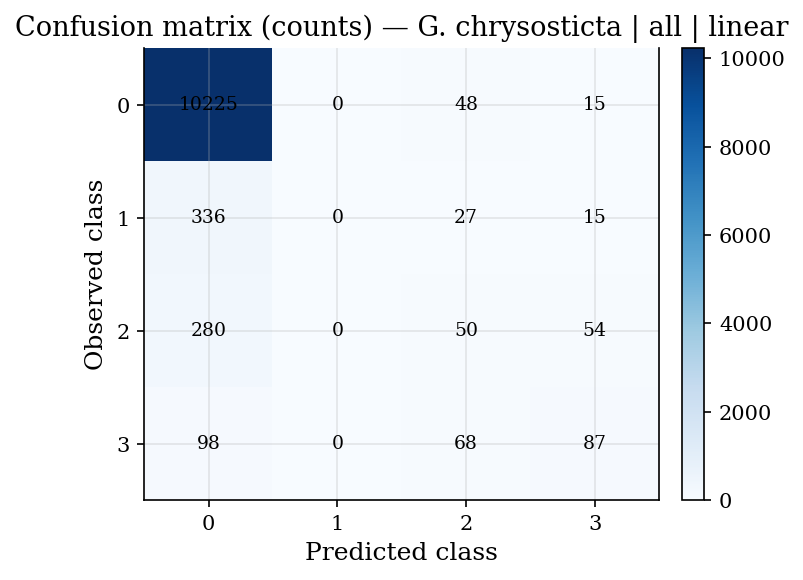

  ✓ Saved: 006_time_series_pred_vs_obs_linear_gastrotheca_all.pdf 


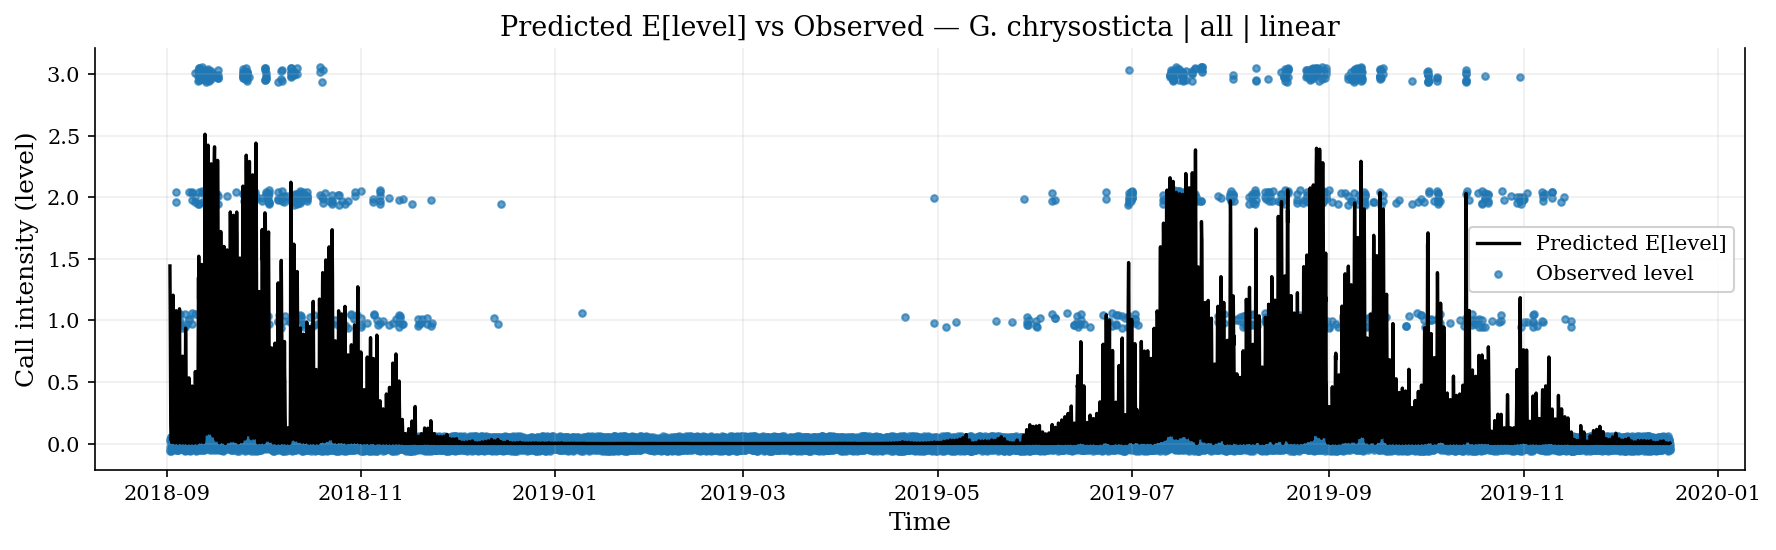

  AUC-ROC (call vs no-call): 0.9442
Gastrotheca chrysosticta | win | linear  --  N=5924
  Ordinal accuracy (exact class): 0.8430
  Binary accuracy (call vs no-call, thresh 0.5): 0.8759
Observed: (array([0, 1, 2, 3]), array([4920,  367,  384,  253]))
Predicted: (array([0, 2, 3]), array([5542,  213,  169]))
  ✓ Saved: 007_confusion_linear_gastrotheca_win.pdf 


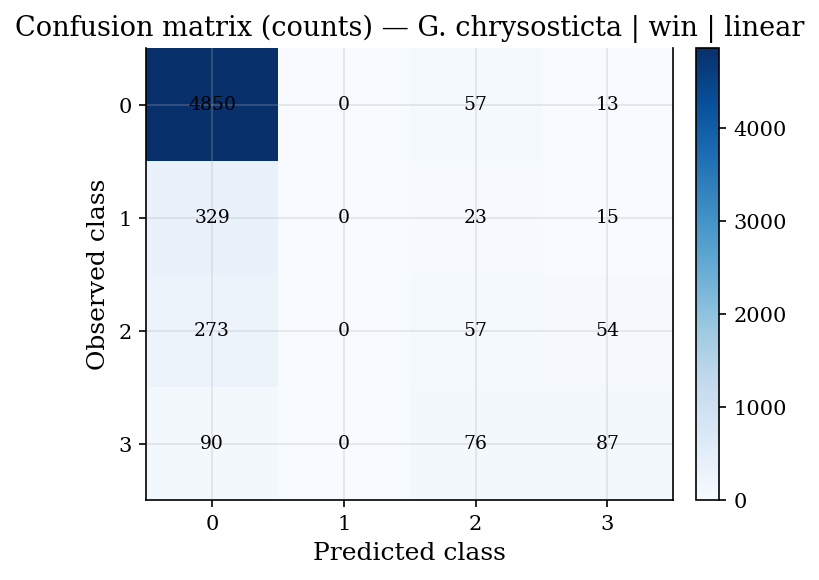

  ✓ Saved: 008_time_series_pred_vs_obs_linear_gastrotheca_win.pdf 


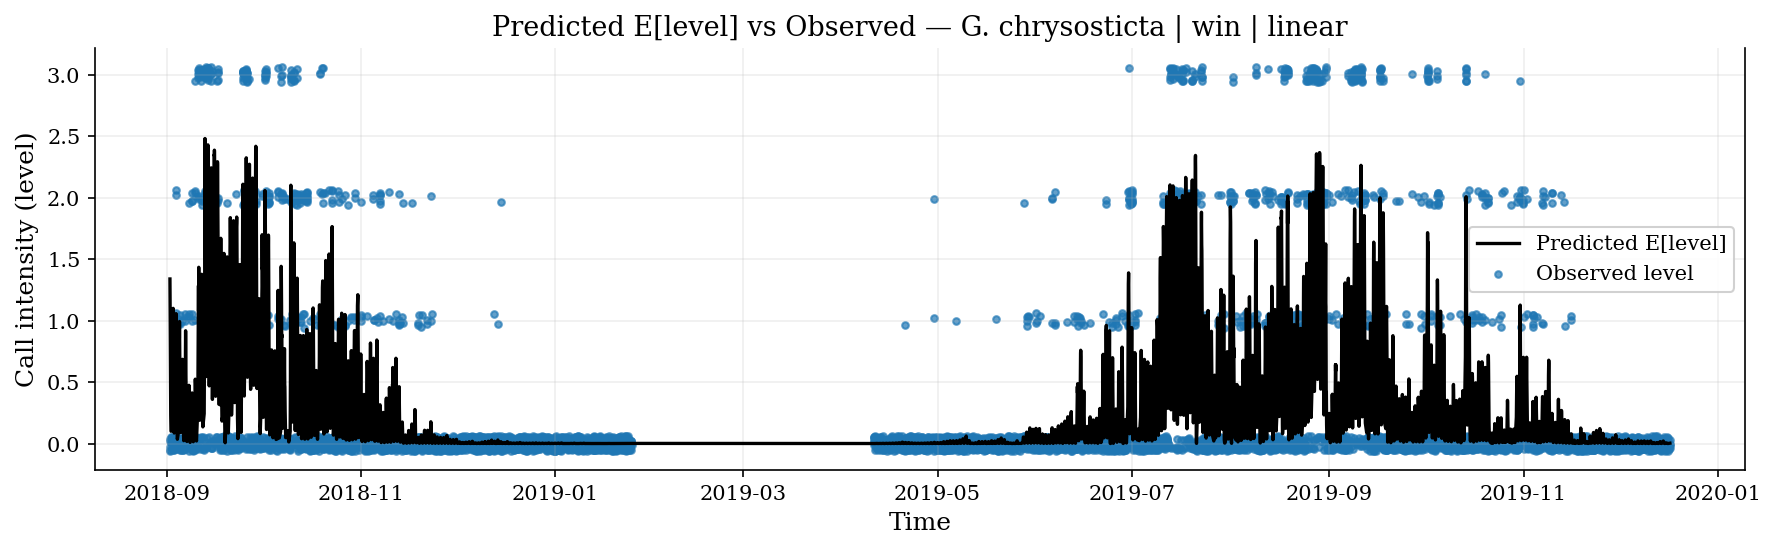

  AUC-ROC (call vs no-call): 0.9025
Oreobates berdemenos | all | linear  --  N=11303
  Ordinal accuracy (exact class): 0.9297
  Binary accuracy (call vs no-call, thresh 0.5): 0.9374
Observed: (array([0, 1, 2, 3]), array([10534,   305,   377,    87]))
Predicted: (array([0, 2]), array([11173,   130]))
  ✓ Saved: 009_confusion_linear_oreobates_all.pdf 


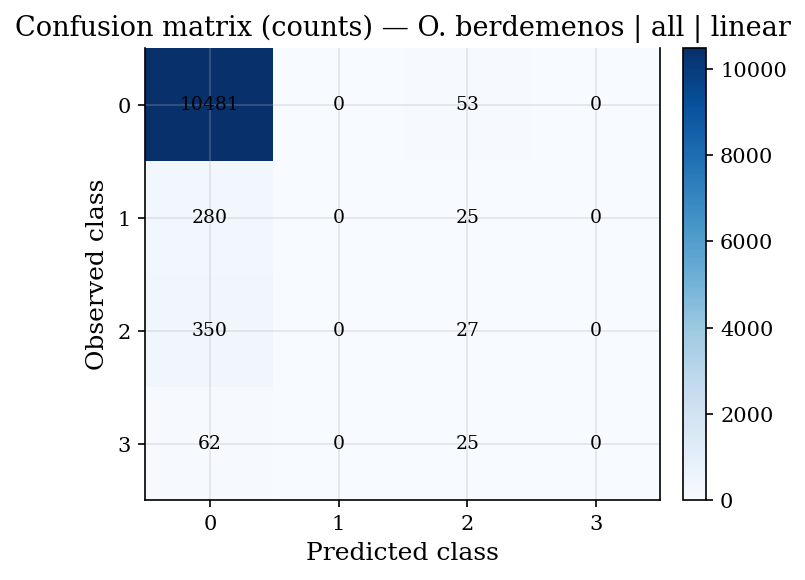

  ✓ Saved: 010_time_series_pred_vs_obs_linear_oreobates_all.pdf 


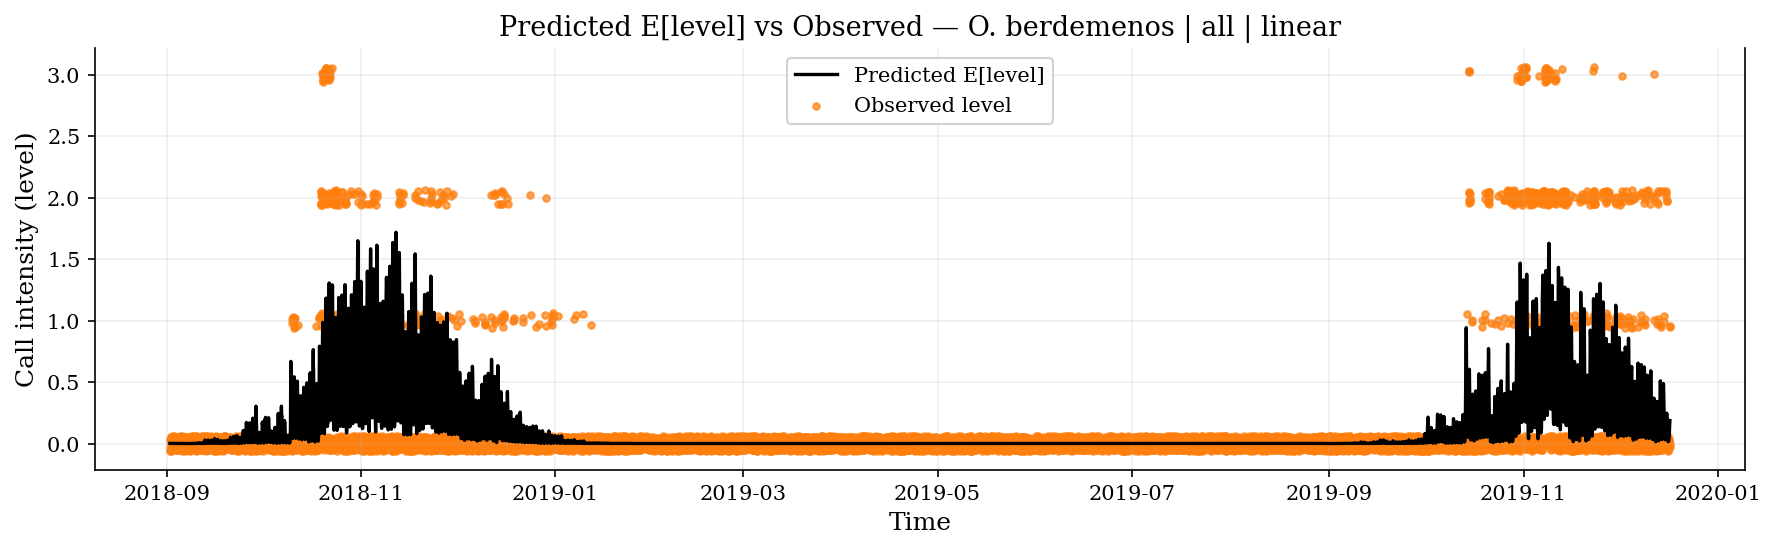

  AUC-ROC (call vs no-call): 0.9444
Oreobates berdemenos | win | linear  --  N=2785
  Ordinal accuracy (exact class): 0.7433
  Binary accuracy (call vs no-call, thresh 0.5): 0.7785
Observed: (array([0, 1, 2, 3]), array([2095,  271,  334,   85]))
Predicted: (array([0, 2]), array([2688,   97]))
  ✓ Saved: 011_confusion_linear_oreobates_win.pdf 


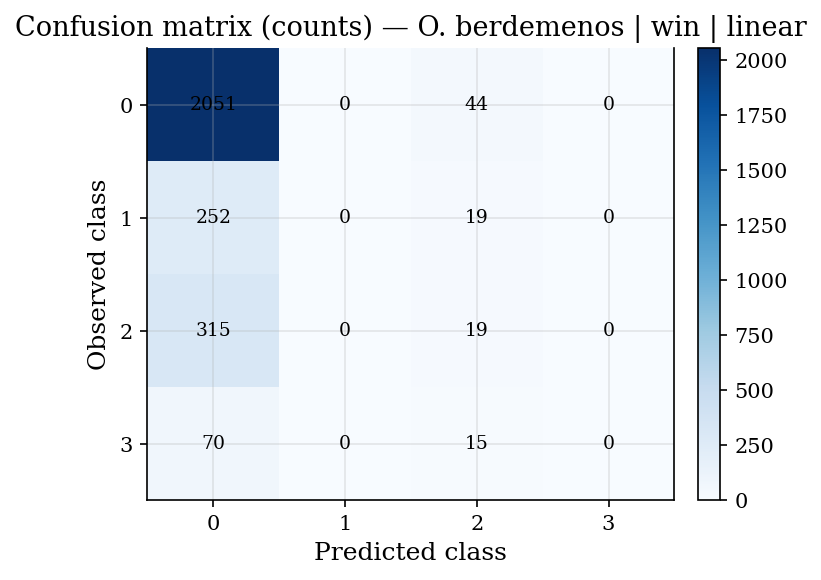

  ✓ Saved: 012_time_series_pred_vs_obs_linear_oreobates_win.pdf 


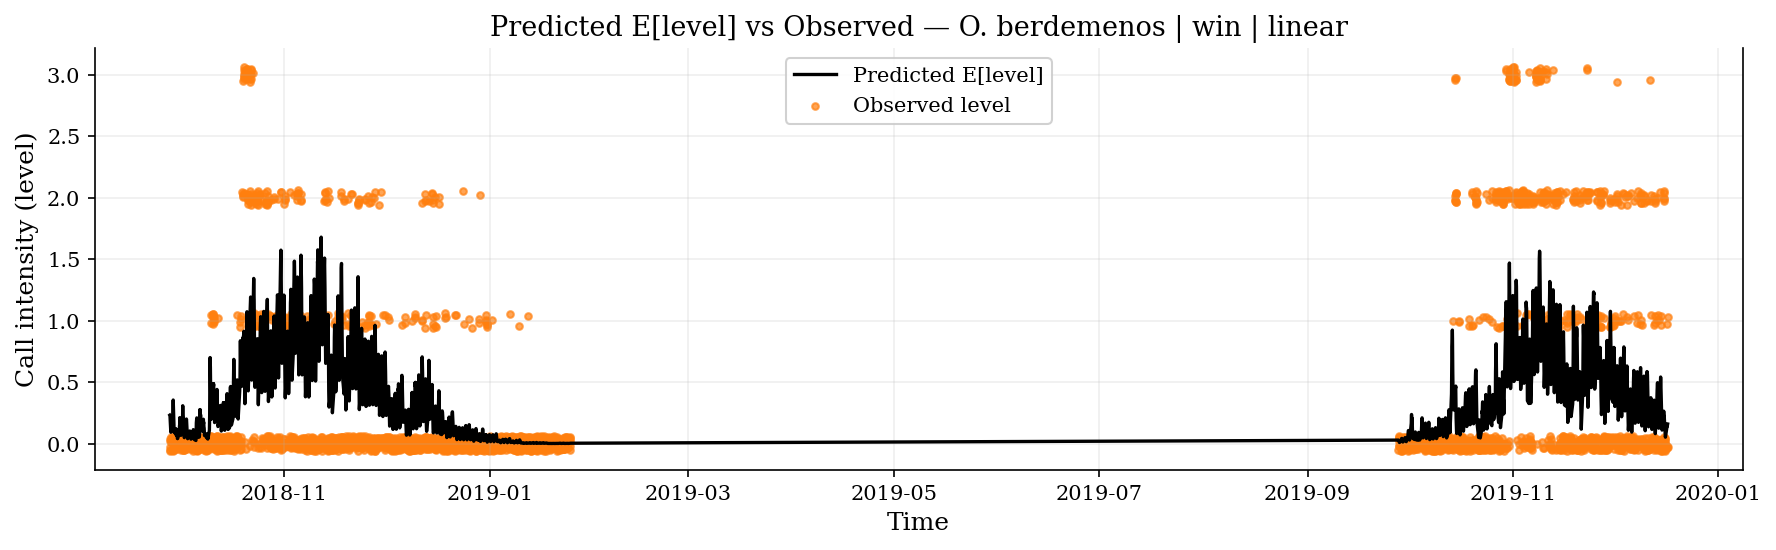

  AUC-ROC (call vs no-call): 0.8100
Gastrotheca chrysosticta | all | spline  --  N=11303
  Ordinal accuracy (exact class): 0.9195
  Binary accuracy (call vs no-call, thresh 0.5): 0.9393
Observed: (array([0, 1, 2, 3]), array([10288,   378,   384,   253]))
Predicted: (array([0, 2, 3]), array([10875,   246,   182]))
  ✓ Saved: 013_confusion_spline_gastrotheca_all.pdf 


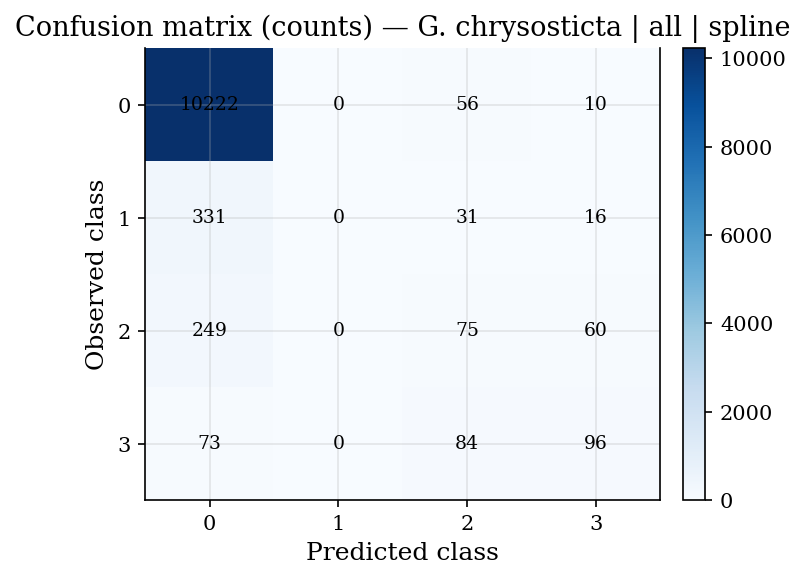

  ✓ Saved: 014_time_series_pred_vs_obs_spline_gastrotheca_all.pdf 


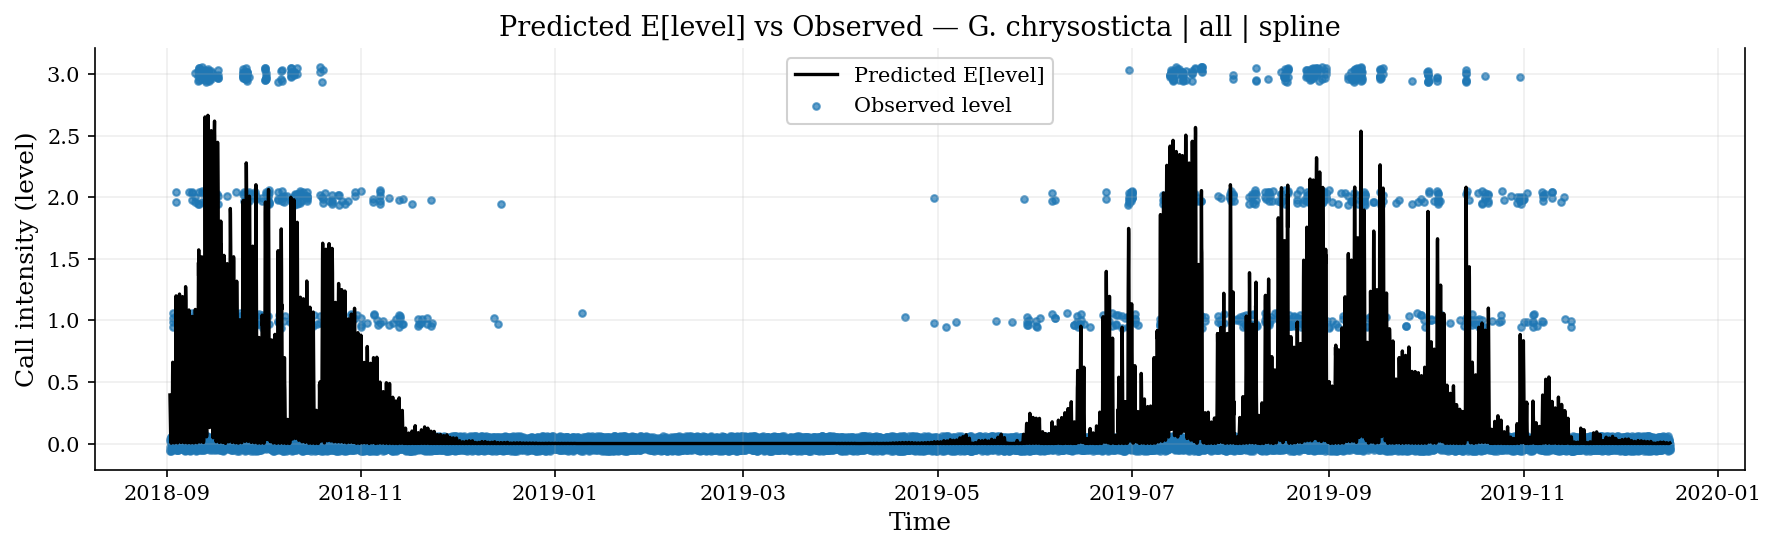

  AUC-ROC (call vs no-call): 0.9494
Gastrotheca chrysosticta | win | spline  --  N=5924
  Ordinal accuracy (exact class): 0.8482
  Binary accuracy (call vs no-call, thresh 0.5): 0.8893
Observed: (array([0, 1, 2, 3]), array([4920,  367,  384,  253]))
Predicted: (array([0, 2, 3]), array([5477,  274,  173]))
  ✓ Saved: 015_confusion_spline_gastrotheca_win.pdf 


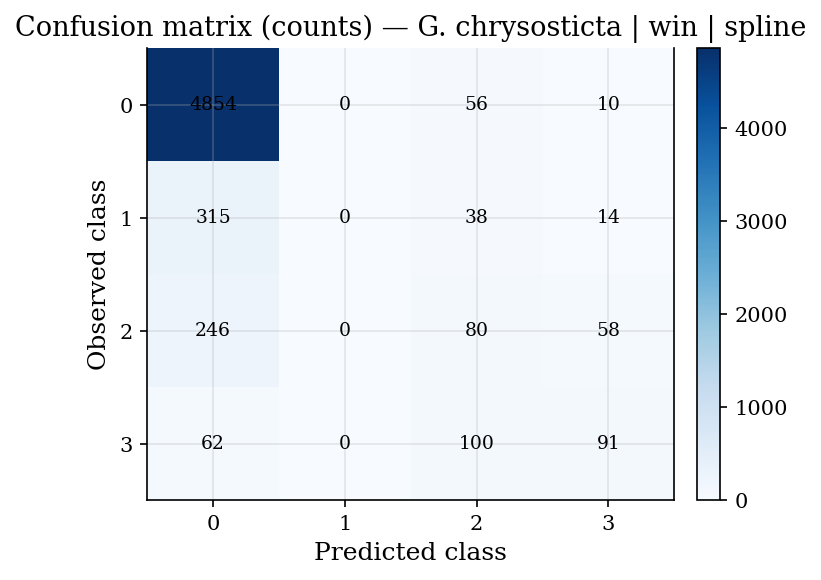

  ✓ Saved: 016_time_series_pred_vs_obs_spline_gastrotheca_win.pdf 


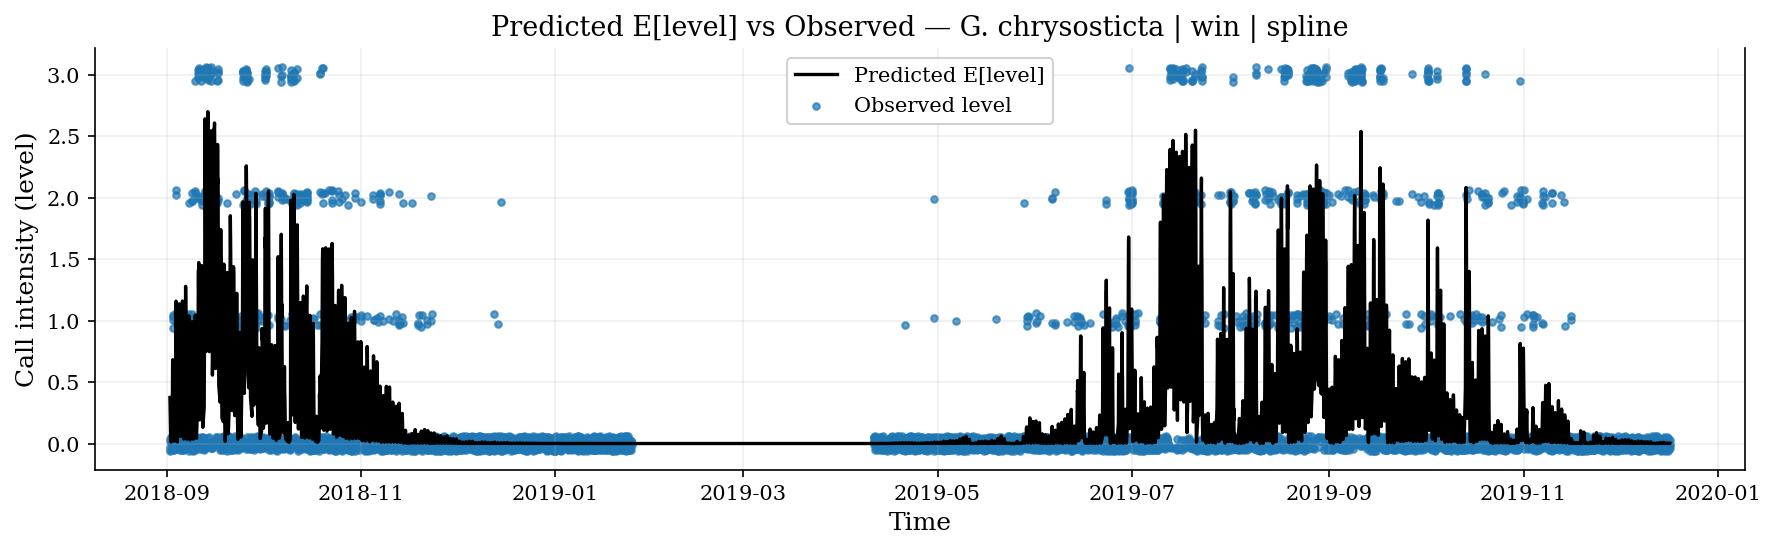

  AUC-ROC (call vs no-call): 0.9142
Oreobates berdemenos | all | spline  --  N=11303
  Ordinal accuracy (exact class): 0.9289
  Binary accuracy (call vs no-call, thresh 0.5): 0.9360
Observed: (array([0, 1, 2, 3]), array([10534,   305,   377,    87]))
Predicted: (array([0, 2]), array([11125,   178]))
  ✓ Saved: 017_confusion_spline_oreobates_all.pdf 


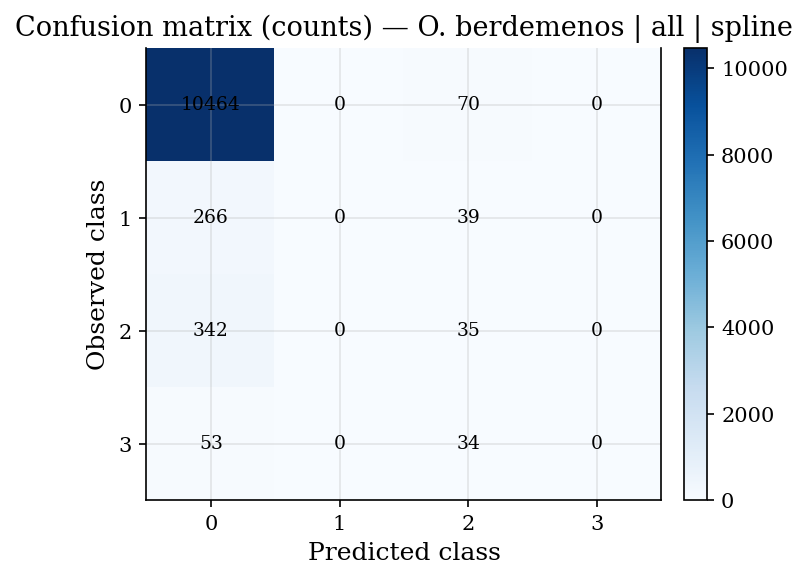

  ✓ Saved: 018_time_series_pred_vs_obs_spline_oreobates_all.pdf 


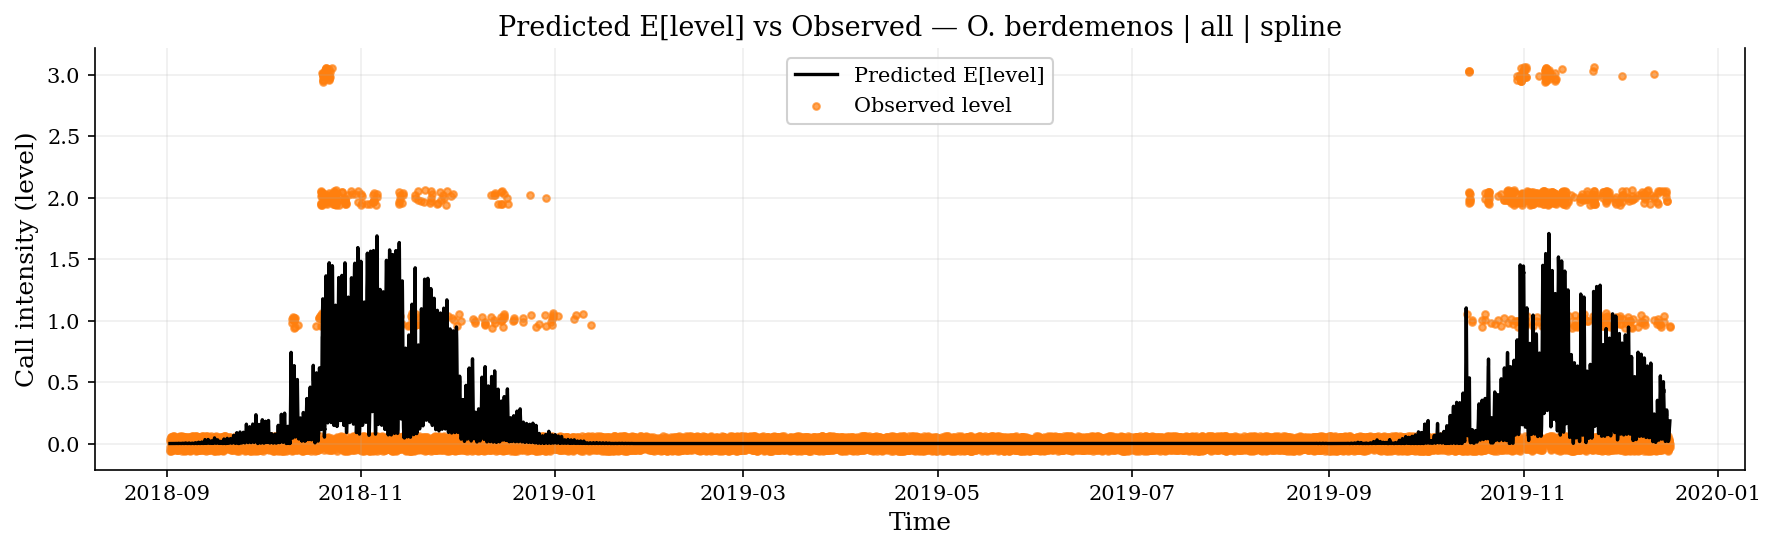

  AUC-ROC (call vs no-call): 0.9472
Oreobates berdemenos | win | spline  --  N=2785
  Ordinal accuracy (exact class): 0.7415
  Binary accuracy (call vs no-call, thresh 0.5): 0.7756
Observed: (array([0, 1, 2, 3]), array([2095,  271,  334,   85]))
Predicted: (array([0, 2]), array([2657,  128]))
  ✓ Saved: 019_confusion_spline_oreobates_win.pdf 


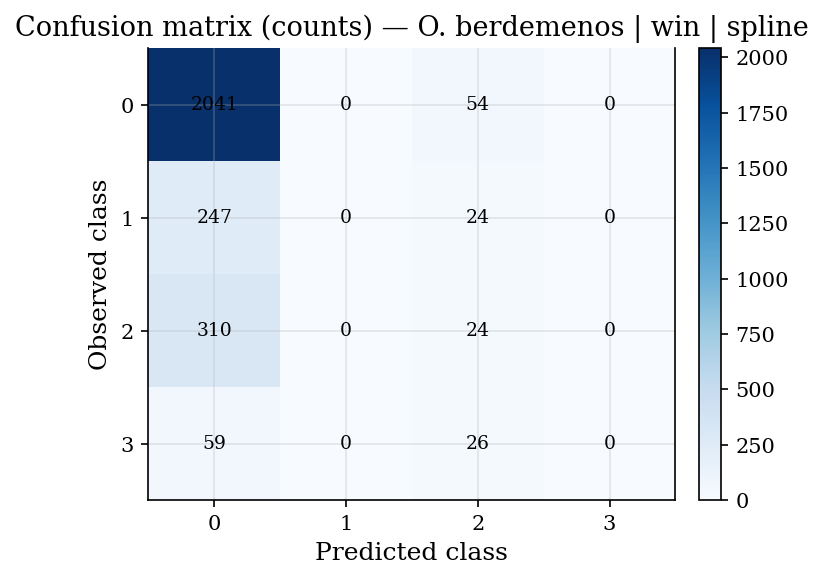

  ✓ Saved: 020_time_series_pred_vs_obs_spline_oreobates_win.pdf 


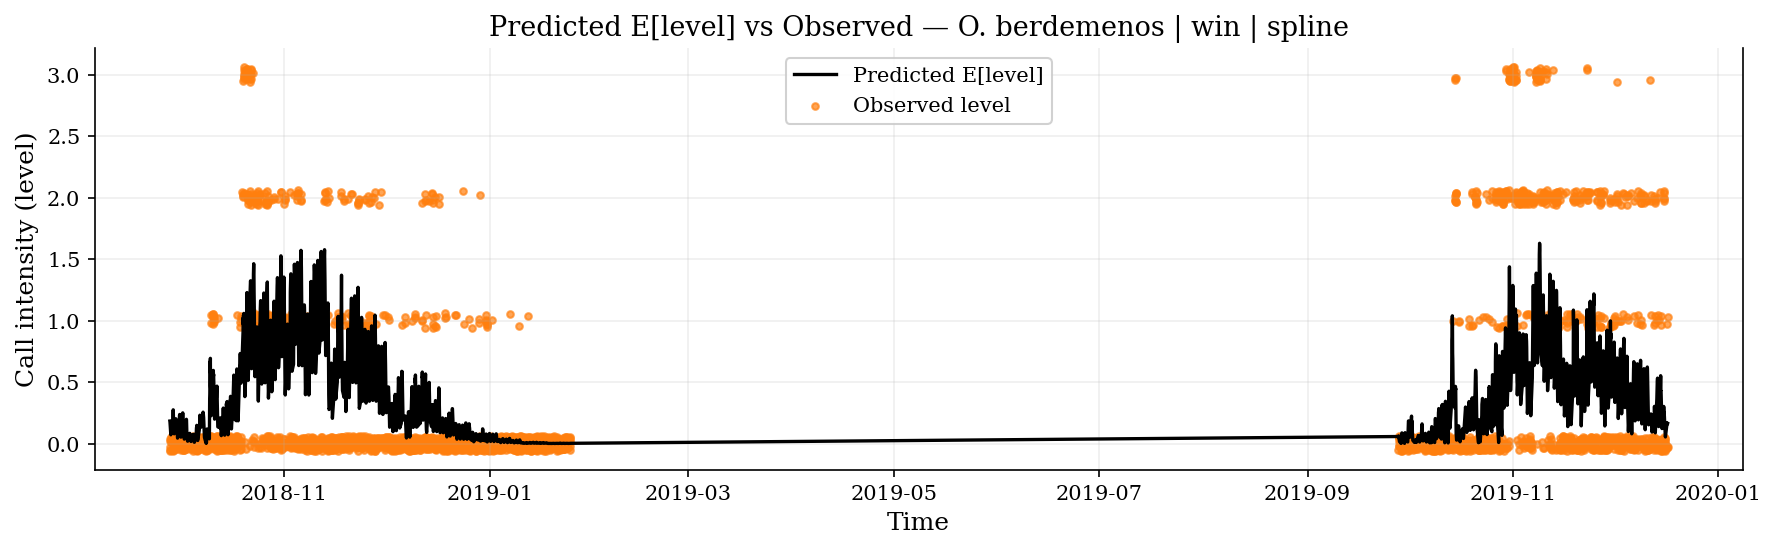

  AUC-ROC (call vs no-call): 0.8149


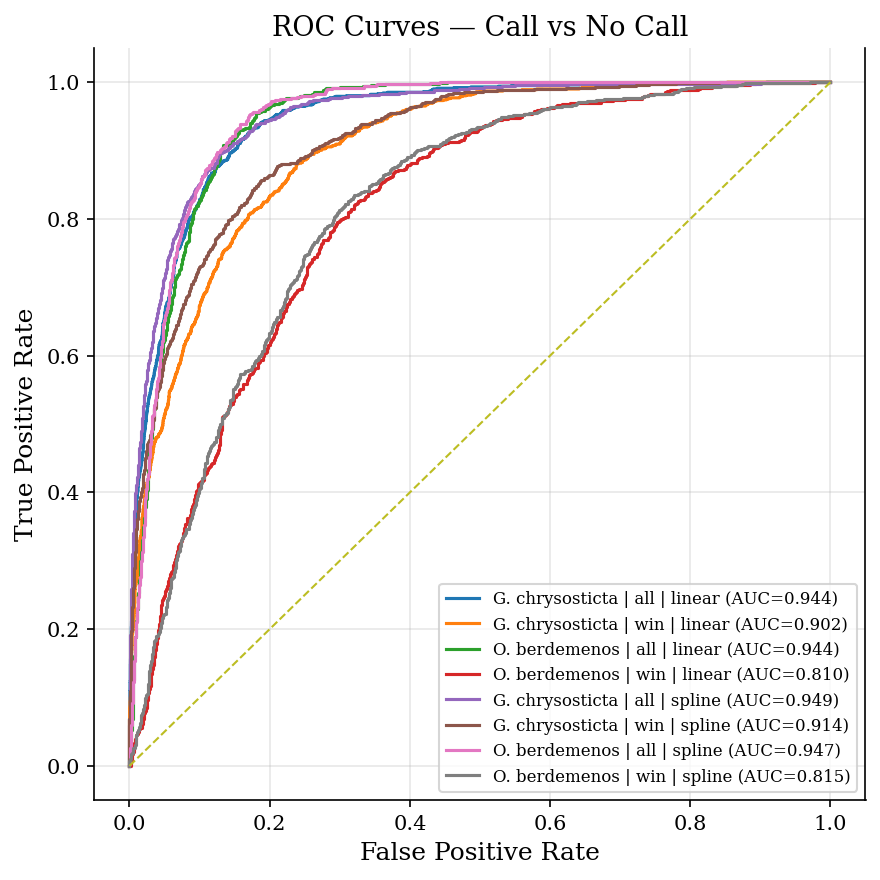

In [78]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc

# Evaluate ordinal and binary (call/no-call) accuracy and plot model vs actual
import matplotlib.pyplot as plt


def expected_level(res, design_info, d: pd.DataFrame):
    X = dmatrix(design_info, d, return_type="dataframe")
    probs = res.model.predict(res.params, exog=X, which="prob")
    probs_np = np.asarray(probs)
    cats = np.arange(probs_np.shape[1])
    return pd.Series((probs_np * cats).sum(axis=1), index=d.index)

def evaluate_and_plot(res, design_info, d: pd.DataFrame, y_col: str, tag: str, sp: str, scope: str):
    # prepare design matrix and predicted probabilities
    X = dmatrix(design_info, d, return_type="dataframe")
    probs = res.model.predict(res.params, exog=X, which="prob")
    probs_np = np.asarray(probs)  # shape (n_obs, n_classes)
    n_classes = probs_np.shape[1]

    # predicted ordinal class (0..K-1), observed class (should be 0..K-1)
    pred_class = probs_np.argmax(axis=1)
    obs_class = d[y_col].astype(int).values

    # binary: call present if level > 0
    p_call = 1.0 - probs_np[:, 0]  # P(level > 0)
    pred_call = (p_call >= 0.5).astype(int)   # threshold 0.5
    obs_call = (d[y_col] > 0).astype(int).values

    # accuracy metrics
    class_acc = (pred_class == obs_class).mean()
    binary_acc = (pred_call == obs_call).mean()

    # print summary
    print(f"{sp} | {scope} | {tag}  --  N={len(d)}")
    print(f"  Ordinal accuracy (exact class): {class_acc:.4f}")
    print(f"  Binary accuracy (call vs no-call, thresh 0.5): {binary_acc:.4f}")

    print("Observed:", np.unique(obs_class, return_counts=True))
    print("Predicted:", np.unique(pred_class, return_counts=True))
    
      # confusion matrix for ordinal classes

    class_labels = np.arange(n_classes)

    obs_cat = pd.Categorical(obs_class, categories=class_labels, ordered=True)

    pred_cat = pd.Categorical(pred_class, categories=class_labels, ordered=True)

    cm = pd.crosstab(
        pd.Series(obs_cat, name="obs"),
        pd.Series(pred_cat, name="pred"),
        dropna=False
    ).reindex(index=class_labels, columns=class_labels, fill_value=0)

    # confusion matrix for ordinal classes
    # cm = pd.crosstab(pd.Series(obs_class, name="obs"), pd.Series(pred_class, name="pred"), normalize=False)
    # plot confusion matrix (counts)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm.values, cmap="Blues", aspect="auto", interpolation="nearest")
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    ax.set_xticklabels(cm.columns)
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Observed class")
    ax.set_title(f"Confusion matrix (counts) — {SP_SHORT.get(sp, sp)} | {scope} | {tag}")
    # annotate cells
    for (i, j), val in np.ndenumerate(cm.values):
        ax.text(j, i, int(val), ha="center", va="center", color="black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    savefig(fig, f"confusion_{tag}_{sp.split()[0].lower()}_{scope}")
    plt.show()

    # Time series: plot expected level vs actual (use expected_level helper)
    e_y = expected_level(res, design_info, d)
    # choose a manageable subset for plotting (contiguous)
    n_plot = max(1000, len(d))
    if scope == "all":
        n_plot = max(n_plot, 2000)  # for "all" scope, show more points to get to good calling stuff
    if n_plot == 0:
        print("  No data to plot for time series.")
        return
    subset = d.iloc[:n_plot].copy()
    e_subset = e_y.reindex(subset.index)

    fig, ax = plt.subplots(figsize=(12, 3.8))
    # plot expected level as line
    ax.plot(subset.index, e_subset, color="black", linestyle="-", linewidth=1.6, label="Predicted E[level]")
    # scatter actual levels (jitter for visibility)
    rng = np.random.default_rng(0)
    jitter = (rng.random(len(subset)) - 0.5) * 0.12
    ax.scatter(subset.index, subset[y_col].values + jitter, c=SP_COLOR.get(sp, "#333333"), s=10, alpha=0.7, label="Observed level")
    ax.set_ylabel("Call intensity (level)")
    ax.set_xlabel("Time")
    ax.set_title(f"Predicted E[level] vs Observed — {SP_SHORT.get(sp, sp)} | {scope} | {tag}")
    ax.legend(framealpha=0.9)
    ax.grid(alpha=0.2)
    # nicer x-axis formatting for dates if available
    fig.tight_layout()
    savefig(fig, f"time_series_pred_vs_obs_{tag}_{sp.split()[0].lower()}_{scope}")
    plt.show()

    # ROC + AUC (binary: call vs no-call)
    fpr, tpr, thresholds = roc_curve(obs_call, p_call)
    roc_auc = auc(fpr, tpr)

    print(f"  AUC-ROC (call vs no-call): {roc_auc:.4f}")

    return {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "label": f"{SP_SHORT.get(sp, sp)} | {scope} | {tag}"
    }



# Run evaluation for linear and spline fits (both scopes) for both species
roc_results = []

for fits, tag in [(fits_linear, "linear"), (fits_spline, "spline")]:
    for sp in SPECIES:
        for scope in ["all", "win"]:
            try:
                info = fits[sp][scope]
                res = info["res"]
                di = info["design"]
                d = info["df"]

                out = evaluate_and_plot(
                    res, di, d,
                    y_col=sp,
                    tag=tag,
                    sp=sp,
                    scope=scope
                )

                if out is not None:
                    roc_results.append(out)

            except Exception as e:
                print(f"Skipping {sp} {scope} {tag}: {e}")

# for fits, tag in [(fits_linear, "linear"), (fits_spline, "spline")]:
#     for sp in SPECIES:
#         for scope in ["all", "win"]:
#             try:
#                 info = fits[sp][scope]
#                 res = info["res"]
#                 di = info["design"]
#                 d = info["df"]
#                 evaluate_and_plot(res, di, d, y_col=sp, tag=tag, sp=sp, scope=scope)
#             except Exception as e:
#                 print(f"Skipping {sp} {scope} {tag}: {e}")
fig, ax = plt.subplots(figsize=(6, 6))

for r in roc_results:
    ax.plot(r["fpr"], r["tpr"], label=f"{r['label']} (AUC={r['auc']:.3f})")

# diagonal reference
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Call vs No Call")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Parameter summaries (linear vs spline)
We print model summaries for both linear and spline variants.

In [79]:
for sp in SPECIES:
    print("\n" + "="*100)
    print(sp, "(LINEAR, ALL DATA)")
    print(fits_linear[sp]["all"]["res"].summary())
    print("\n" + sp, "(SPLINE, ALL DATA)")
    print(fits_spline[sp]["all"]["res"].summary())
    print("\n" + "="*100)
    print(sp, "(LINEAR, WINDOWED DATA)")
    print(fits_linear[sp]["win"]["res"].summary())
    print("\n" + sp, "(SPLINE, WINDOWED DATA)")
    print(fits_spline[sp]["win"]["res"].summary())


Gastrotheca chrysosticta (LINEAR, ALL DATA)
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -2739.9
Model:                   OrderedModel   AIC:                             5500.
Method:            Maximum Likelihood   BIC:                             5573.
Date:                Fri, 08 May 2026                                         
Time:                        17:29:19                                         
No. Observations:               11303                                         
Df Residuals:                   11293                                         
Df Model:                           7                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Temp_z            1.3548      0.070     19.260      0.000       1.217       1.49

## 7. Diagnostics: observed vs fitted category frequencies

  ✓ Saved: 021_calibration_linear_gastrotheca.pdf 


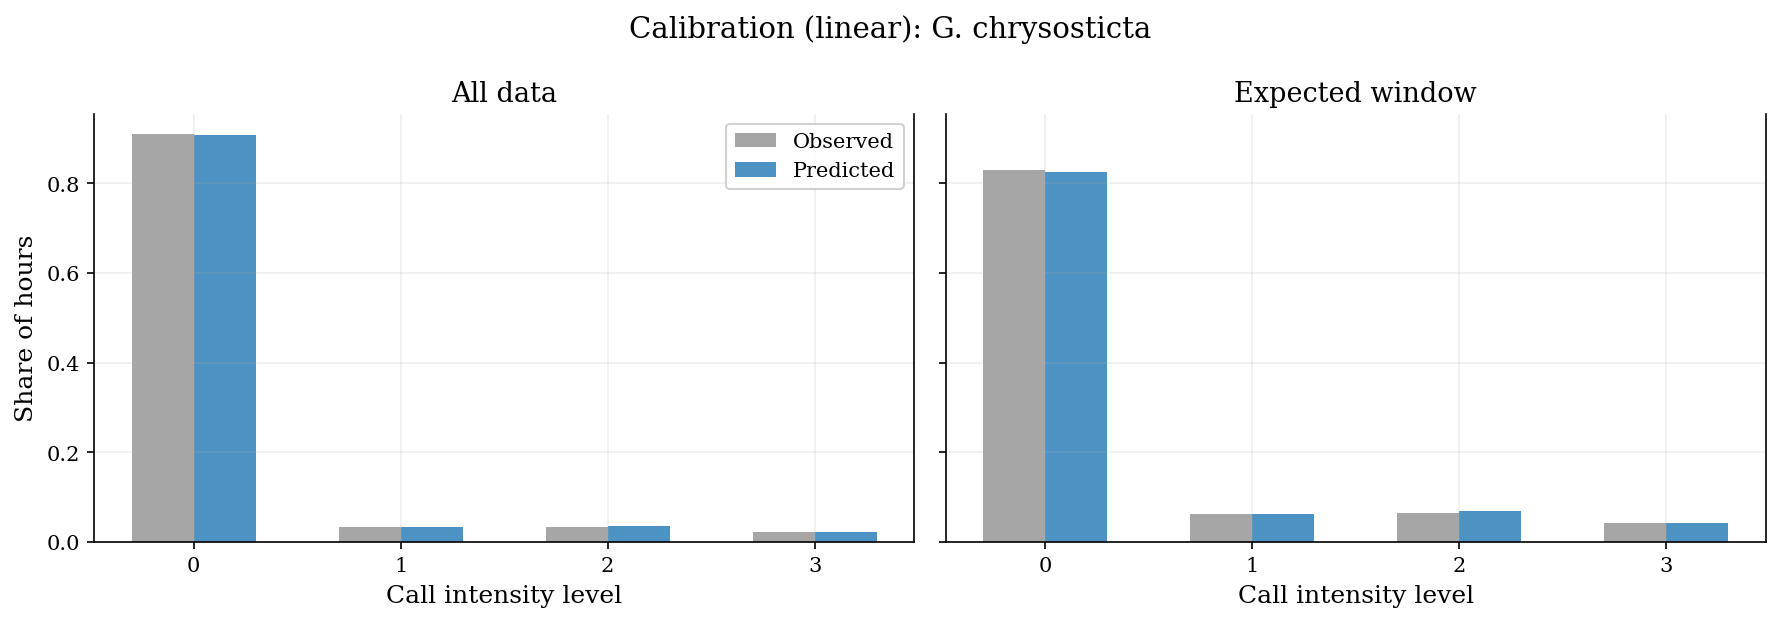

  ✓ Saved: 022_calibration_linear_oreobates.pdf 


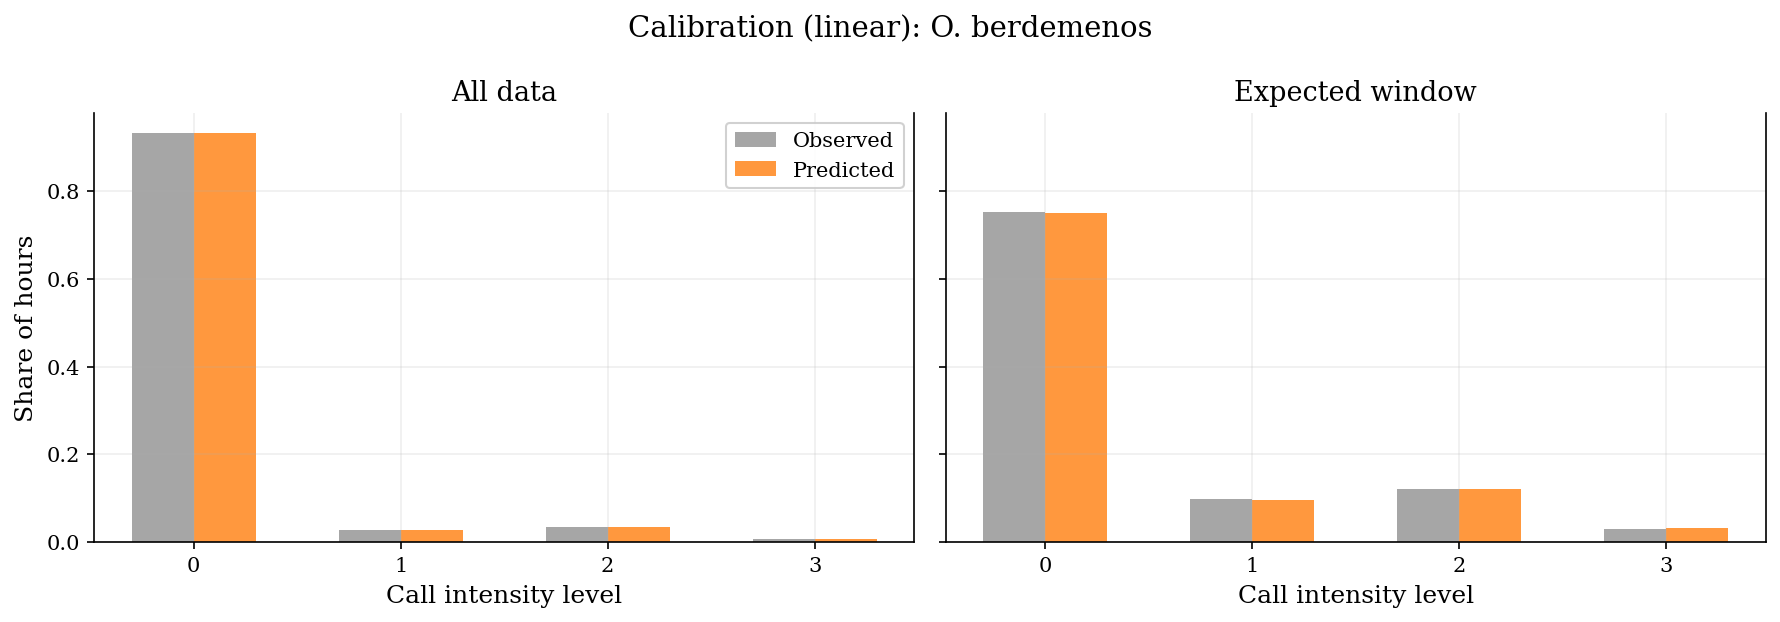

  ✓ Saved: 023_calibration_spline_gastrotheca.pdf 


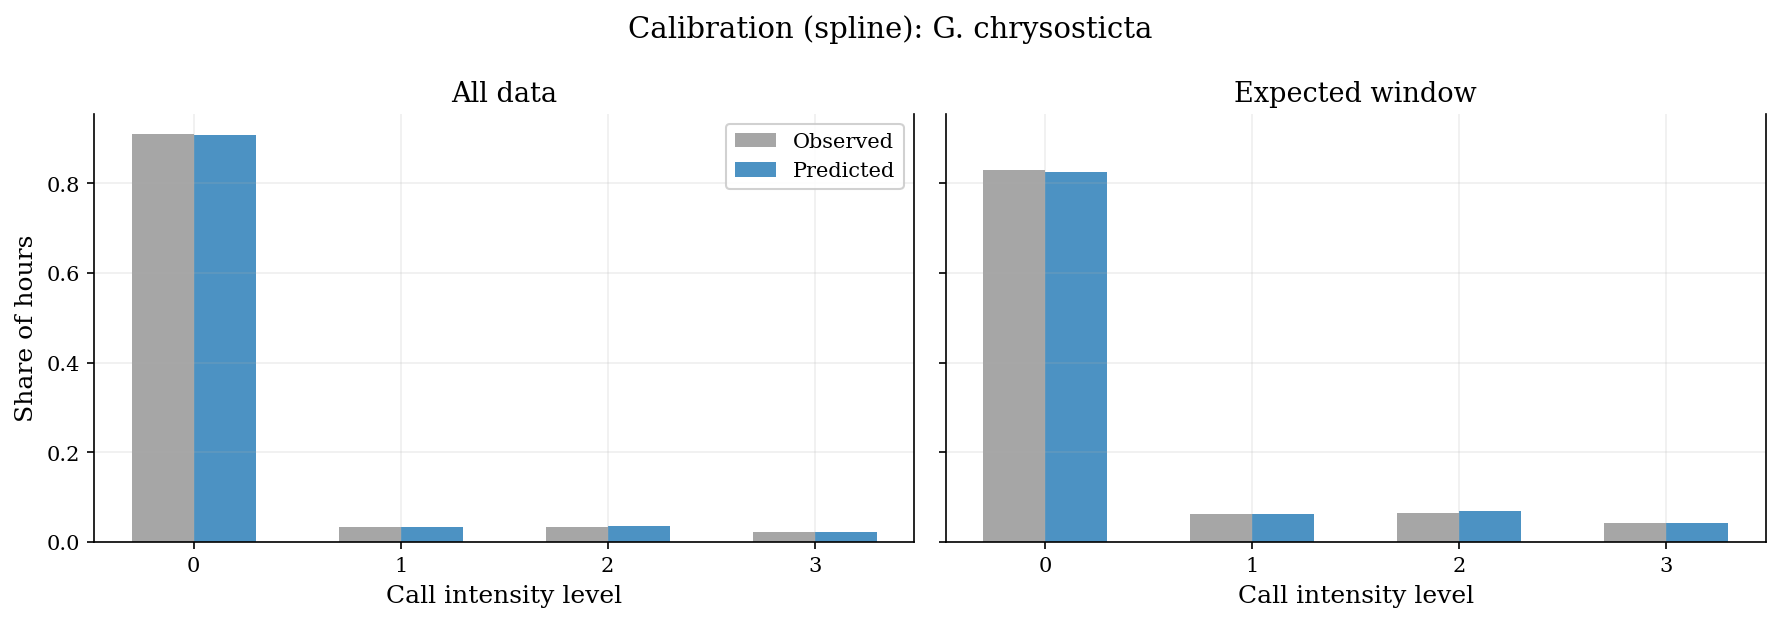

  ✓ Saved: 024_calibration_spline_oreobates.pdf 


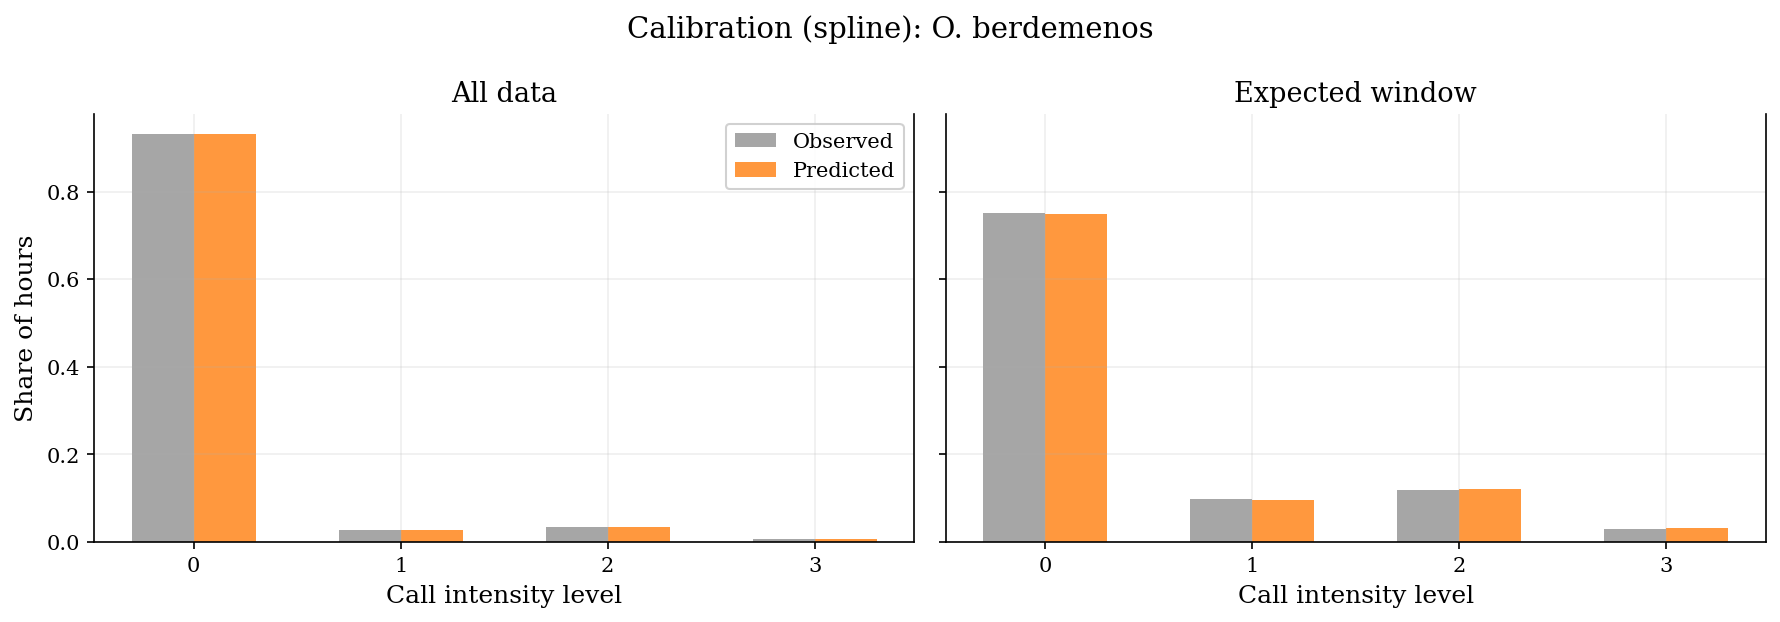

In [80]:
def calibration_table(res, design_info, d: pd.DataFrame, y_col: str):
    X = dmatrix(design_info, d, return_type="dataframe")
    probs = res.model.predict(res.params, exog=X, which="prob")
    probs_np = np.asarray(probs)
    pred_share = probs_np.mean(axis=0)
    obs_counts = d[y_col].value_counts().sort_index()
    obs_share = (obs_counts / obs_counts.sum()).reindex(range(probs_np.shape[1])).fillna(0).values
    out = pd.DataFrame({"category": range(probs_np.shape[1]),
                        "predicted_share": pred_share,
                        "observed_share": obs_share})
    return out

def plot_calibration(fits: dict, tag: str):
    tabs = []
    for sp in SPECIES:
        y_col = fits[sp]["y_col"]
        for scope in ["all", "win"]:
            res = fits[sp][scope]["res"]
            di = fits[sp][scope]["design"]
            d = fits[sp][scope]["df"]
            t = calibration_table(res, di, d, y_col=y_col)
            t["species"] = sp
            t["scope"] = scope
            tabs.append(t)
    calib = pd.concat(tabs, ignore_index=True)
    for sp in SPECIES:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
        for ax, scope, ttl in zip(axes, ["all", "win"], ["All data", "Expected window"]):
            dd = calib[(calib["species"] == sp) & (calib["scope"] == scope)].sort_values("category")
            x = dd["category"].values
            ax.bar(x - 0.15, dd["observed_share"], width=0.3, label="Observed", color="gray", alpha=0.7)
            ax.bar(x + 0.15, dd["predicted_share"], width=0.3, label="Predicted", color=SP_COLOR[sp], alpha=0.8)
            ax.set_title(ttl)
            ax.set_xlabel("Call intensity level")
            ax.set_xticks([0, 1, 2, 3])
            ax.grid(alpha=0.2)
        axes[0].set_ylabel("Share of hours")
        axes[0].legend(framealpha=0.9)
        fig.suptitle(f"Calibration ({tag}): {SP_SHORT[sp]}", fontsize=14)
        fig.tight_layout()
        savefig(fig, f"calibration_{tag}_{sp.split()[0].lower()}")
        plt.show()

plot_calibration(fits_linear, tag="linear")
plot_calibration(fits_spline, tag="spline")

## 8. Prediction curves (raw Temp/RH)
We plot predicted category probabilities and expected call level as a function of temperature / humidity, holding season/time fixed.

  ✓ Saved: 025_curve_temp_linear_gastrotheca_win_other0.pdf 


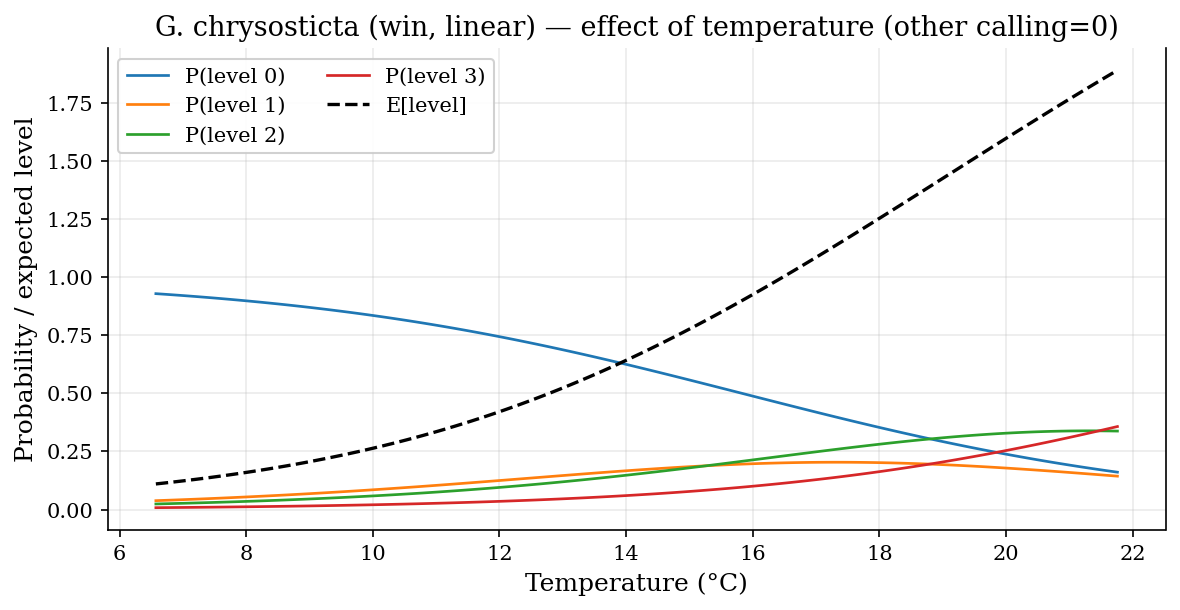

  ✓ Saved: 026_curve_rh_linear_gastrotheca_win_other0.pdf 


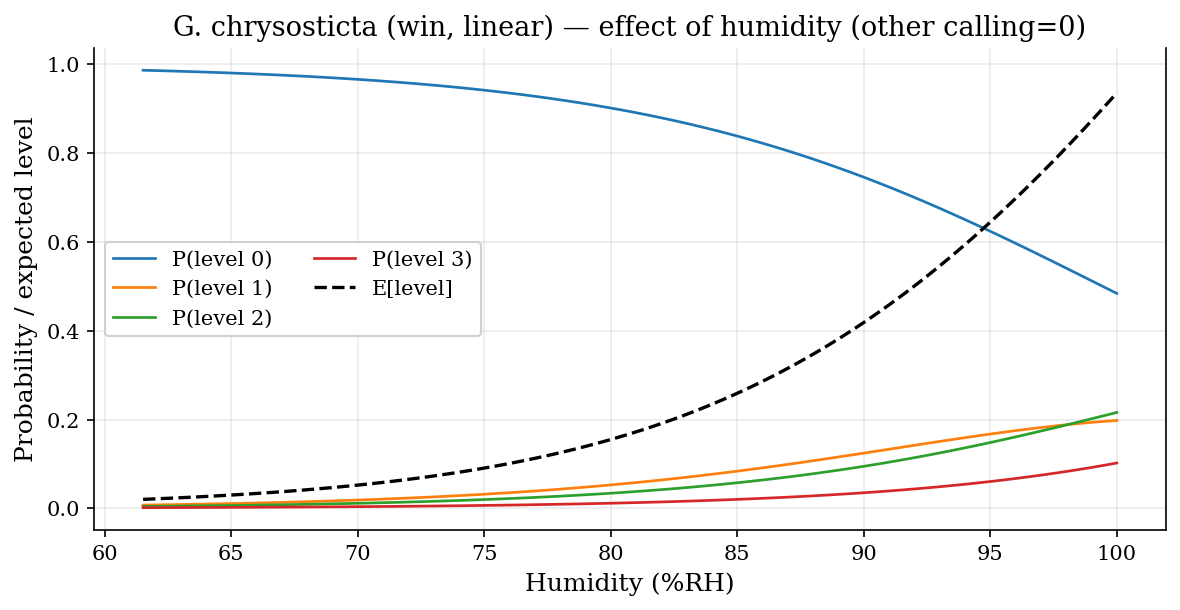

  ✓ Saved: 027_curve_temp_linear_gastrotheca_win_other1.pdf 


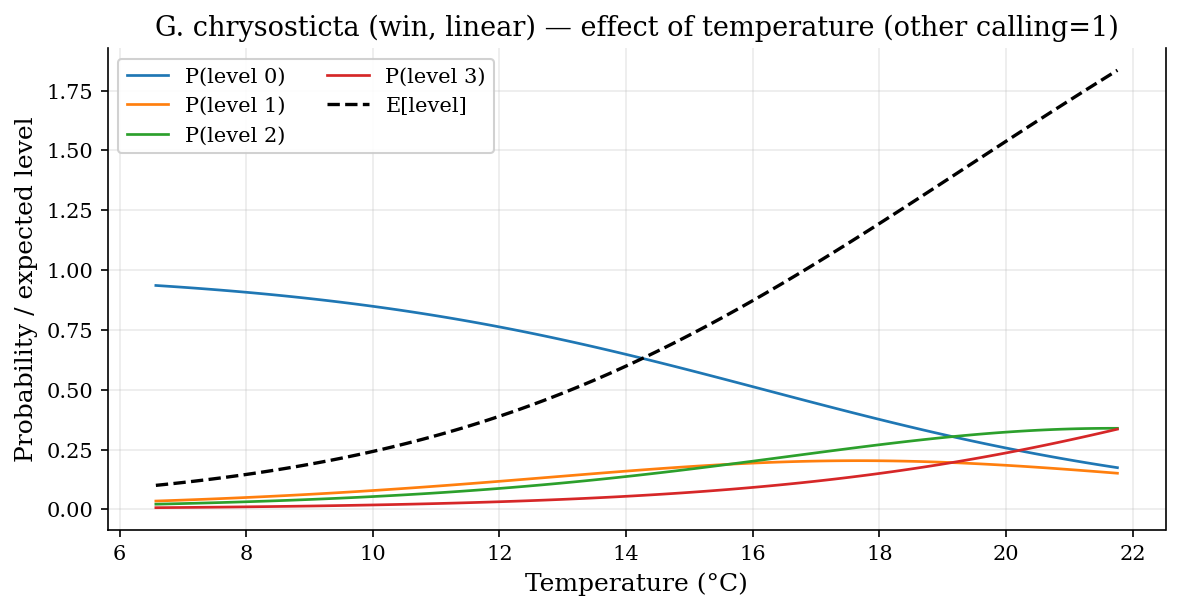

  ✓ Saved: 028_curve_rh_linear_gastrotheca_win_other1.pdf 


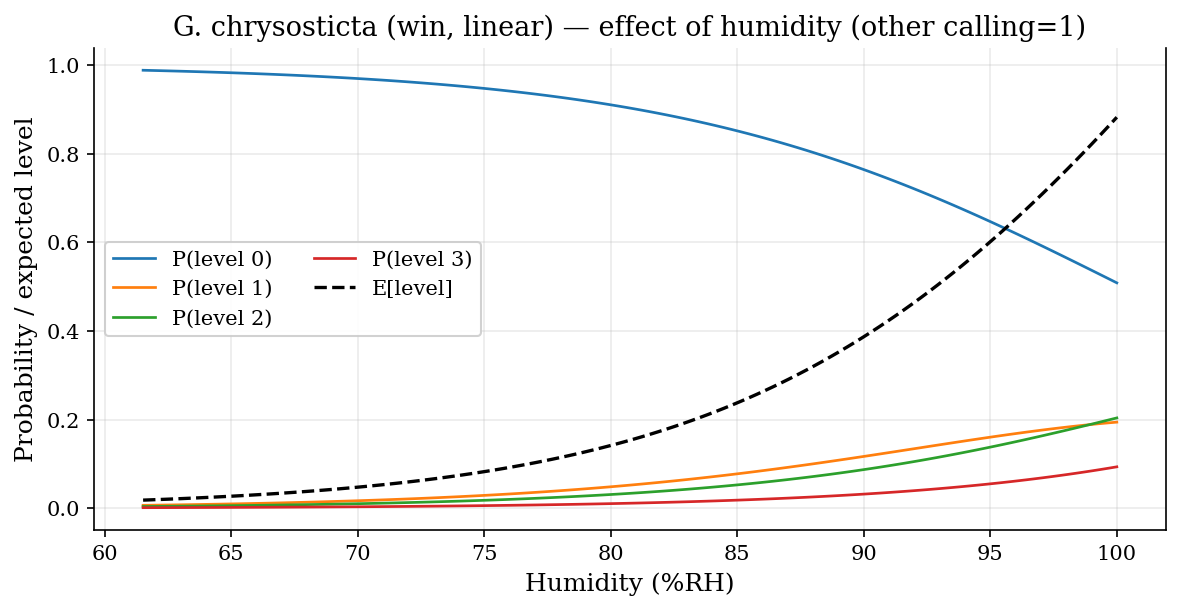

  ✓ Saved: 029_curve_temp_other_compare_linear_gastrotheca_win.pdf 


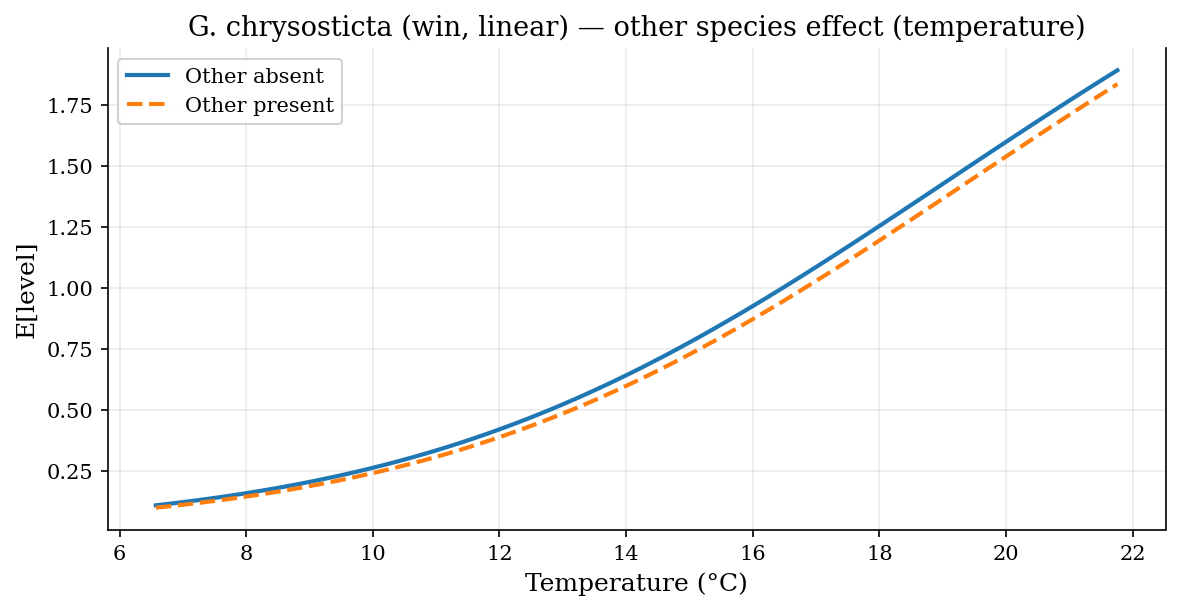

  ✓ Saved: 030_curve_rh_other_compare_linear_gastrotheca_win.pdf 


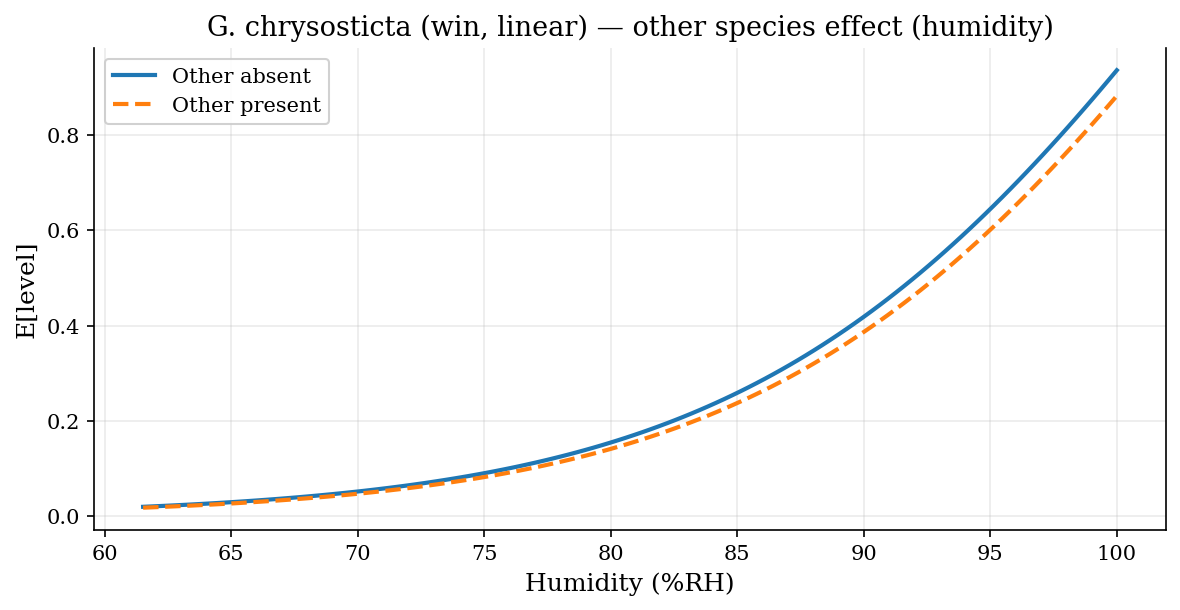

  ✓ Saved: 031_curve_temp_linear_oreobates_win_other0.pdf 


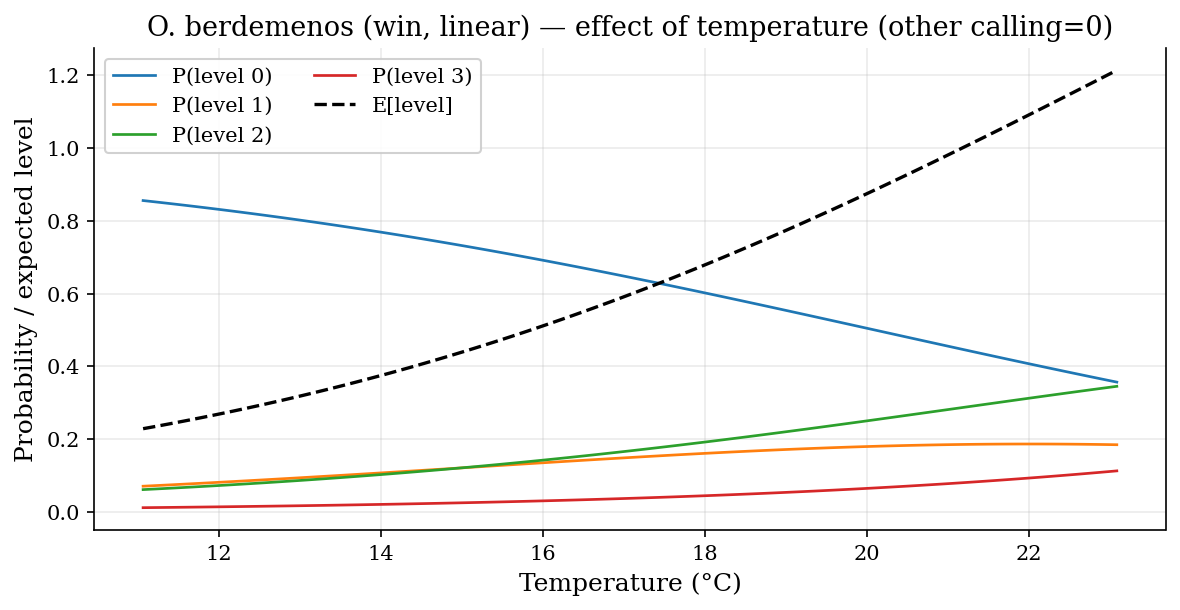

  ✓ Saved: 032_curve_rh_linear_oreobates_win_other0.pdf 


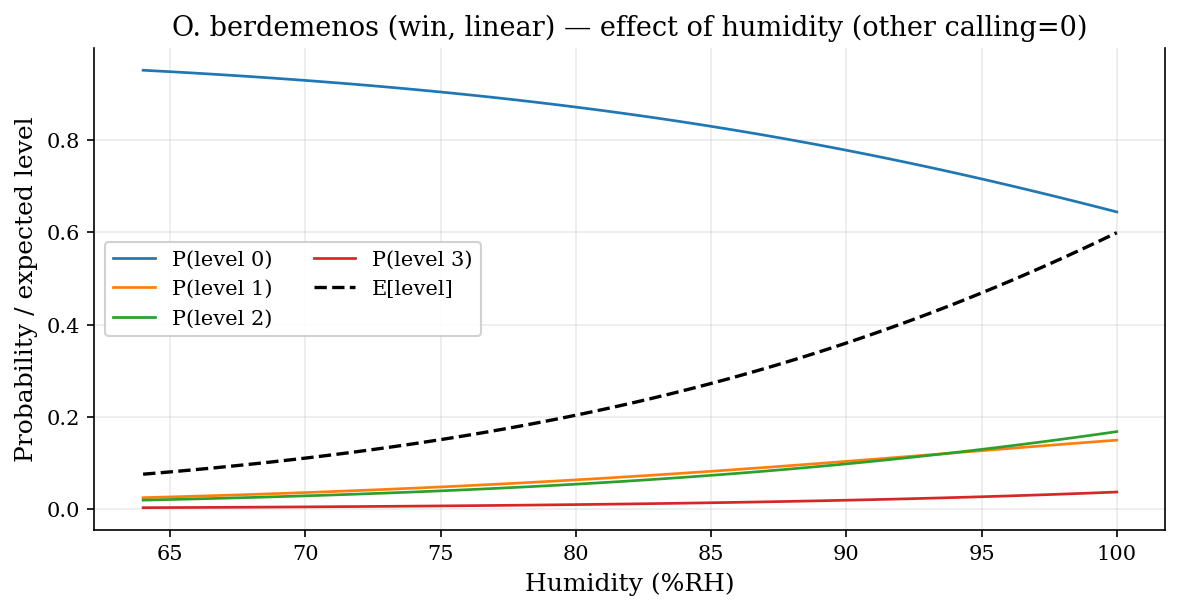

  ✓ Saved: 033_curve_temp_linear_oreobates_win_other1.pdf 


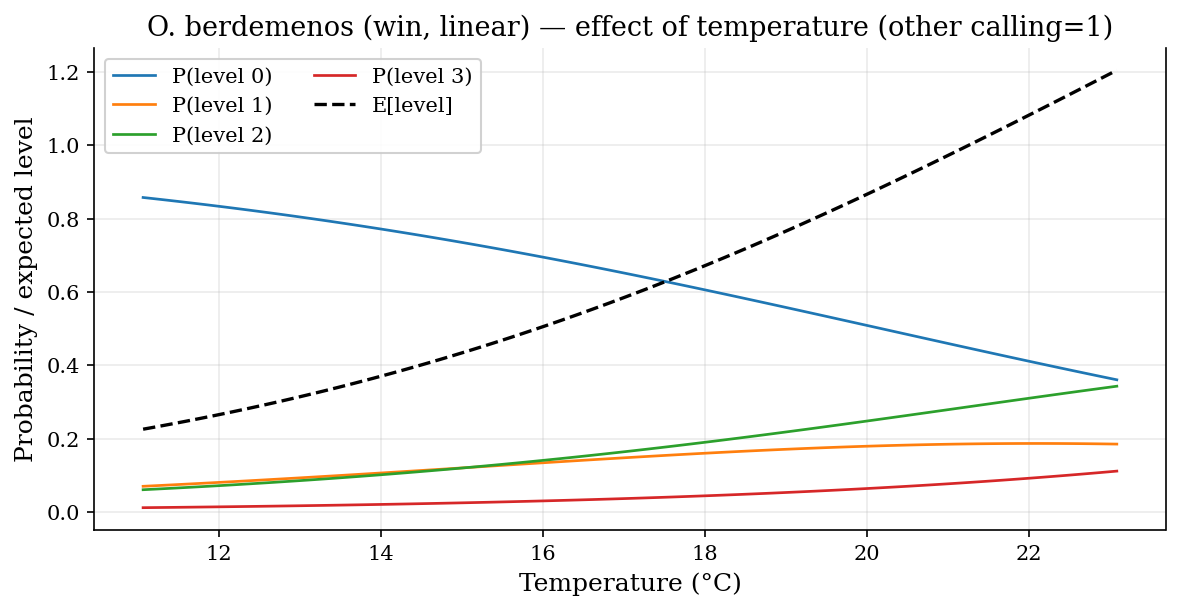

  ✓ Saved: 034_curve_rh_linear_oreobates_win_other1.pdf 


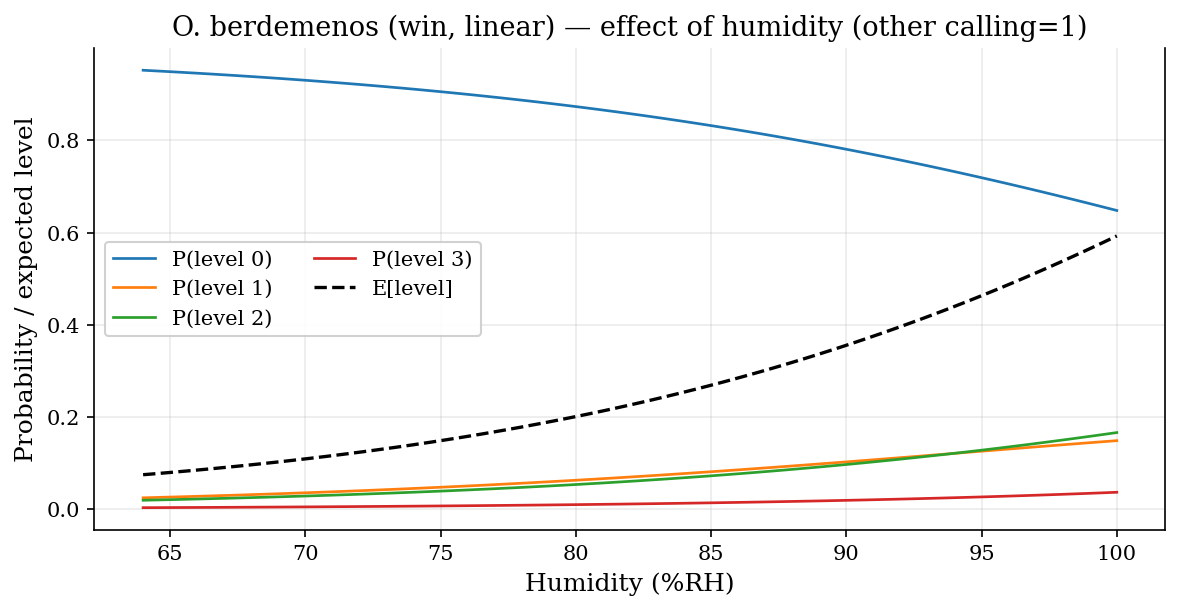

  ✓ Saved: 035_curve_temp_other_compare_linear_oreobates_win.pdf 


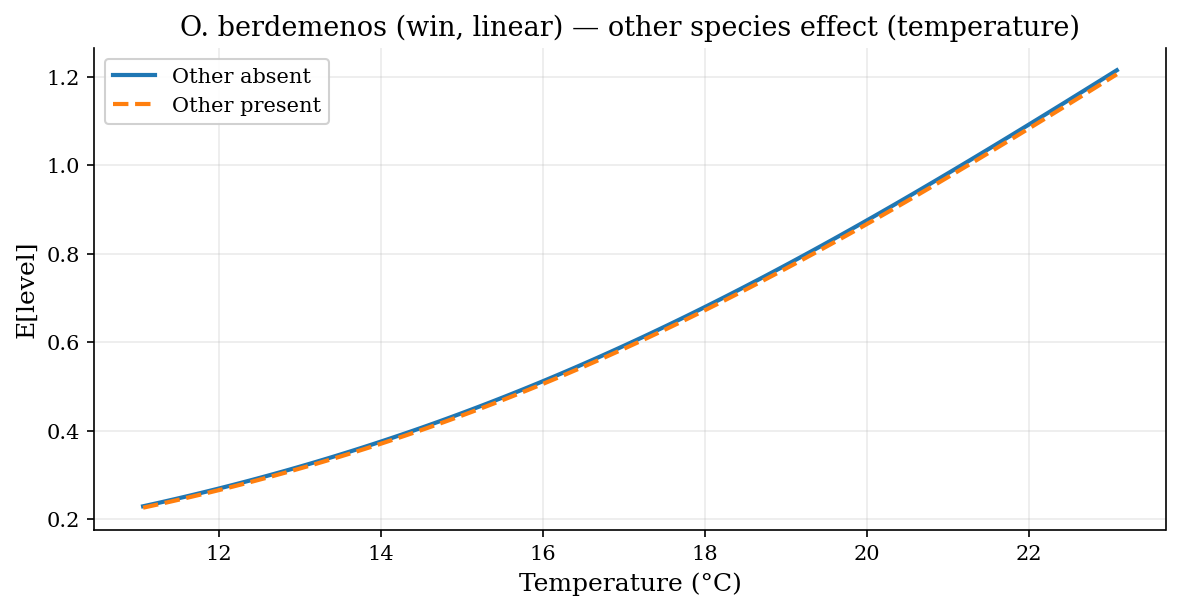

  ✓ Saved: 036_curve_rh_other_compare_linear_oreobates_win.pdf 


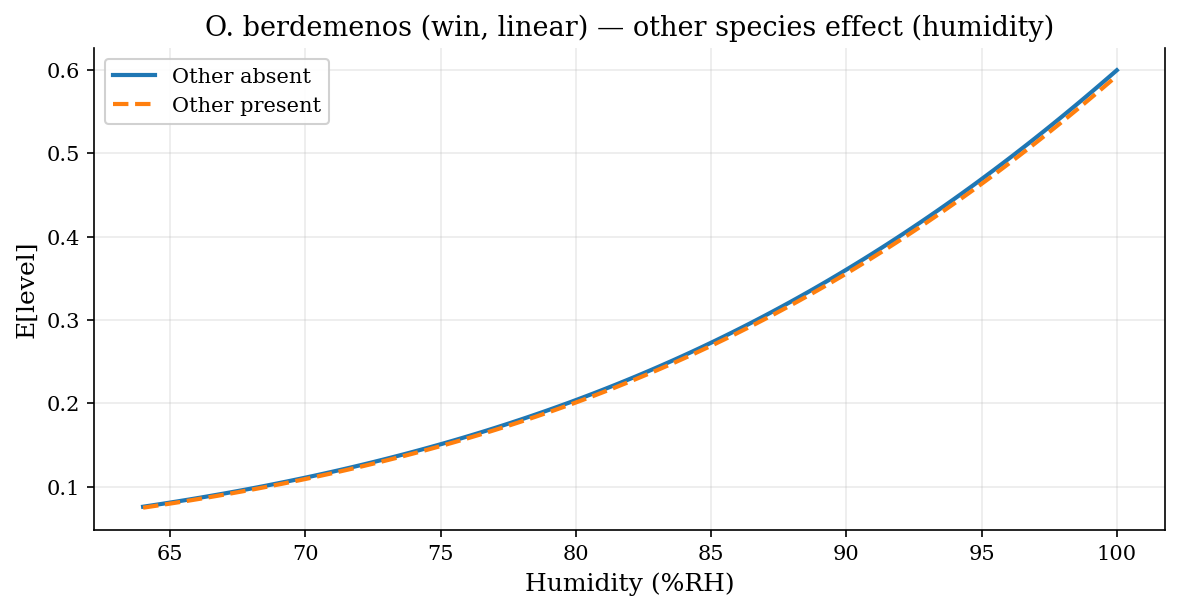

  ✓ Saved: 037_curve_temp_spline_gastrotheca_win_other0.pdf 


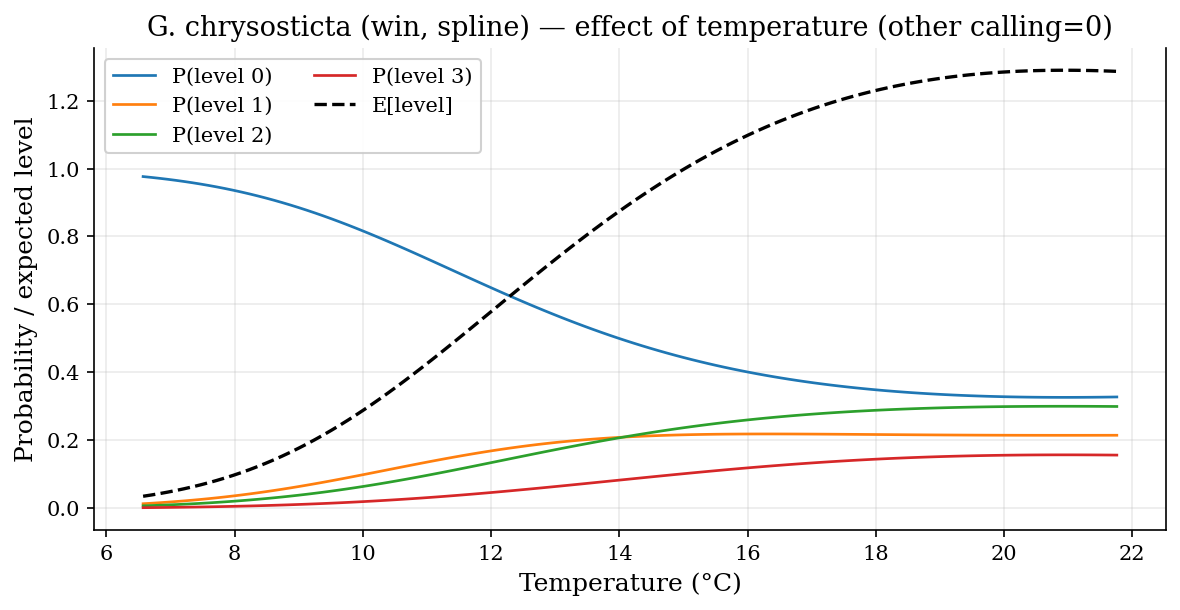

  ✓ Saved: 038_curve_rh_spline_gastrotheca_win_other0.pdf 


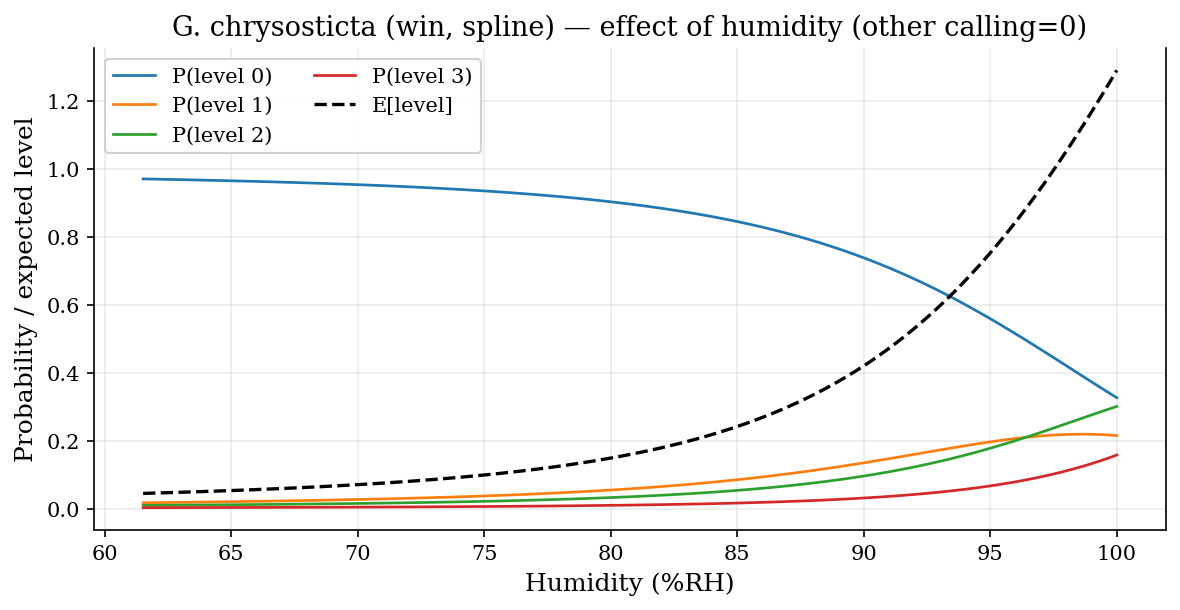

  ✓ Saved: 039_curve_temp_spline_gastrotheca_win_other1.pdf 


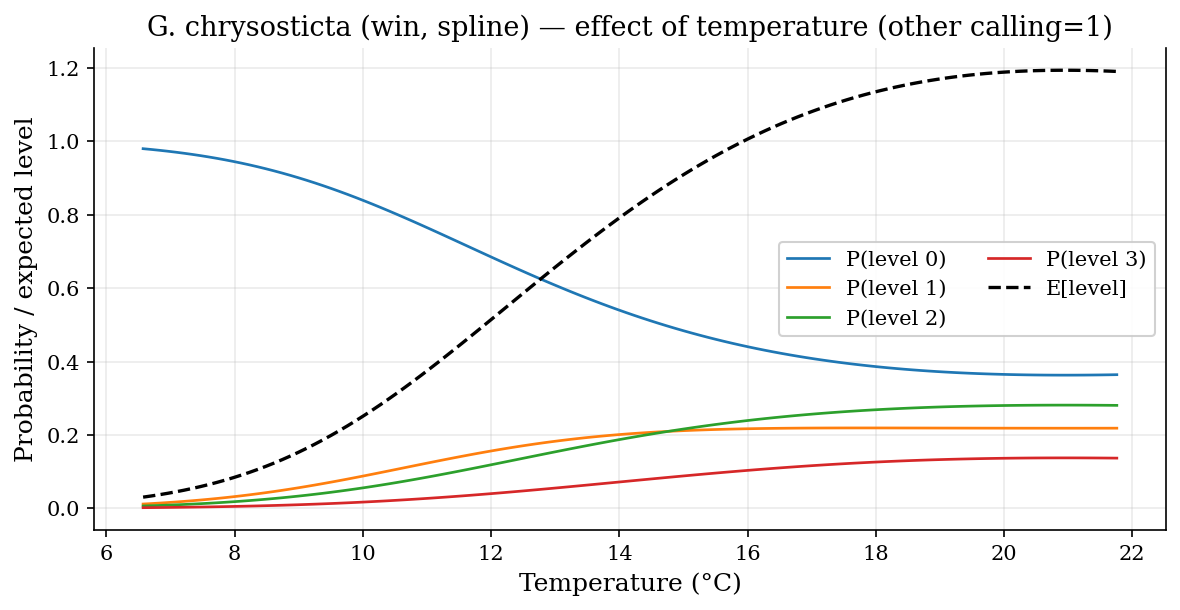

  ✓ Saved: 040_curve_rh_spline_gastrotheca_win_other1.pdf 


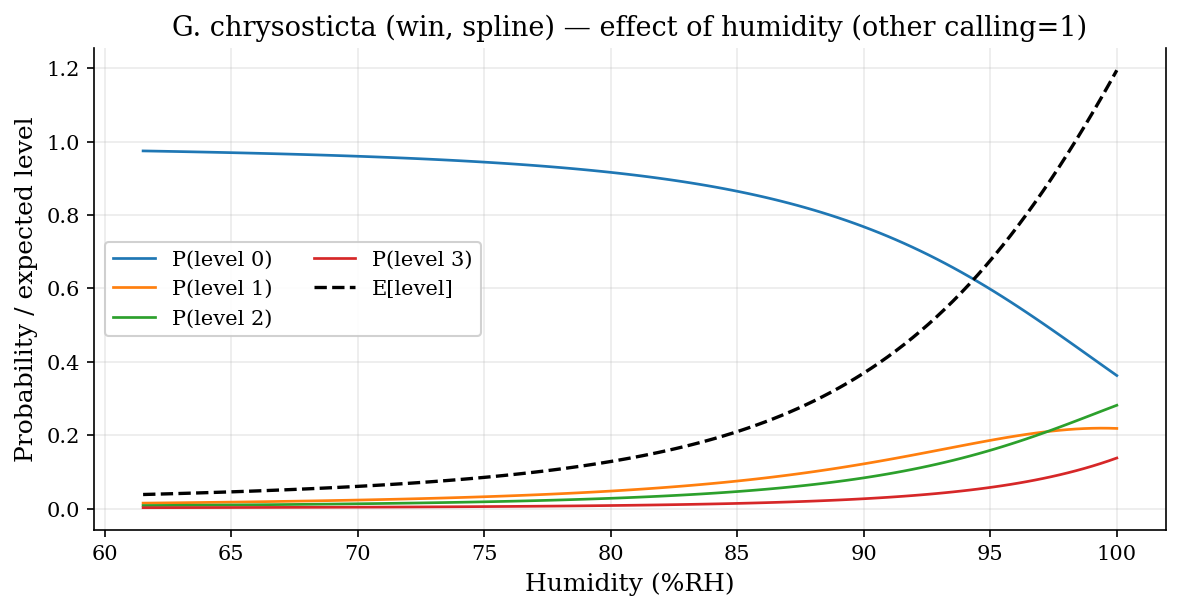

  ✓ Saved: 041_curve_temp_other_compare_spline_gastrotheca_win.pdf 


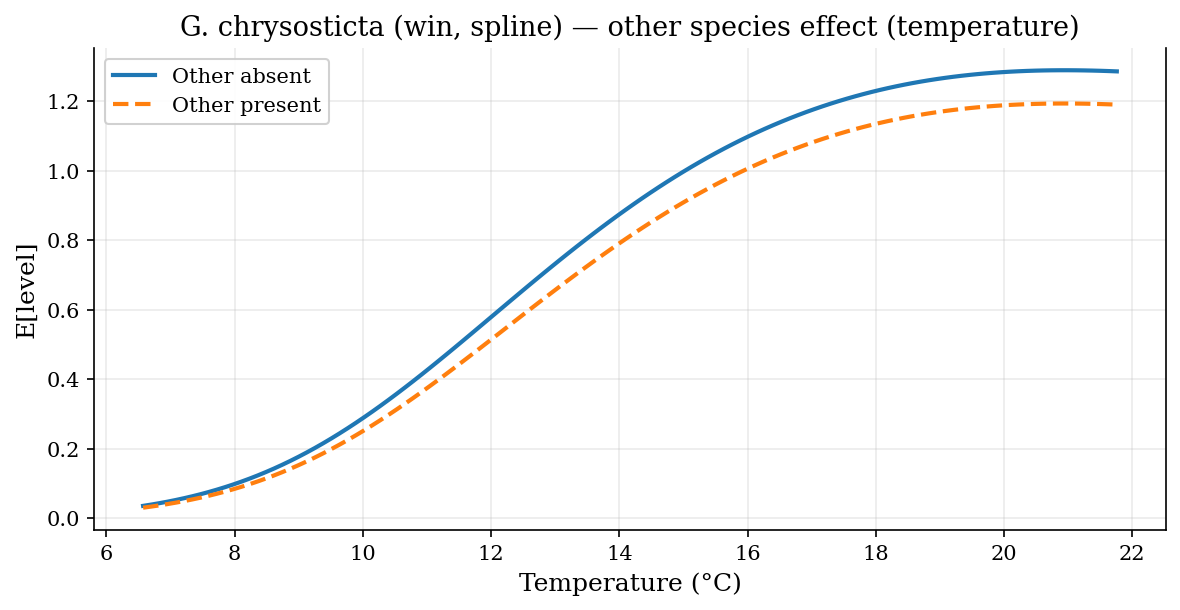

  ✓ Saved: 042_curve_rh_other_compare_spline_gastrotheca_win.pdf 


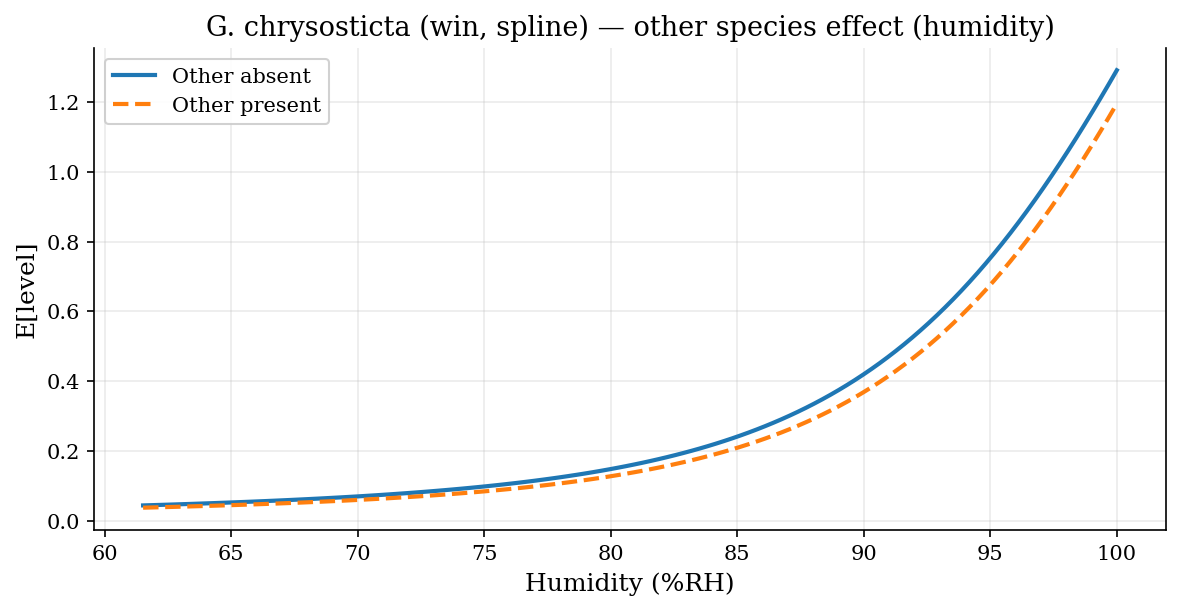

  ✓ Saved: 043_curve_temp_spline_oreobates_win_other0.pdf 


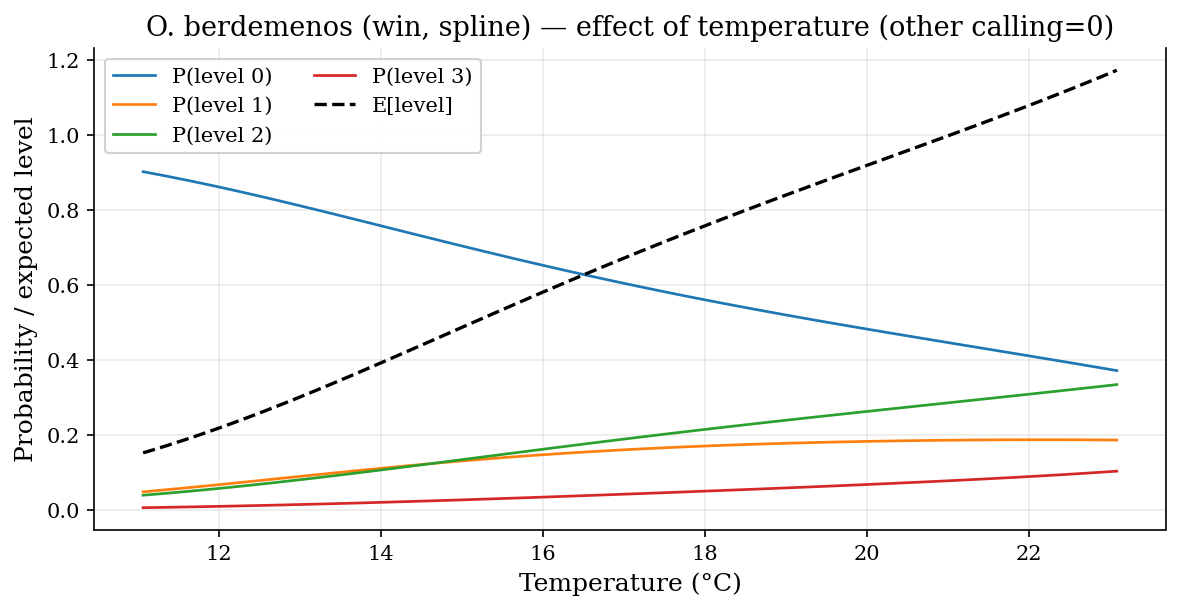

  ✓ Saved: 044_curve_rh_spline_oreobates_win_other0.pdf 


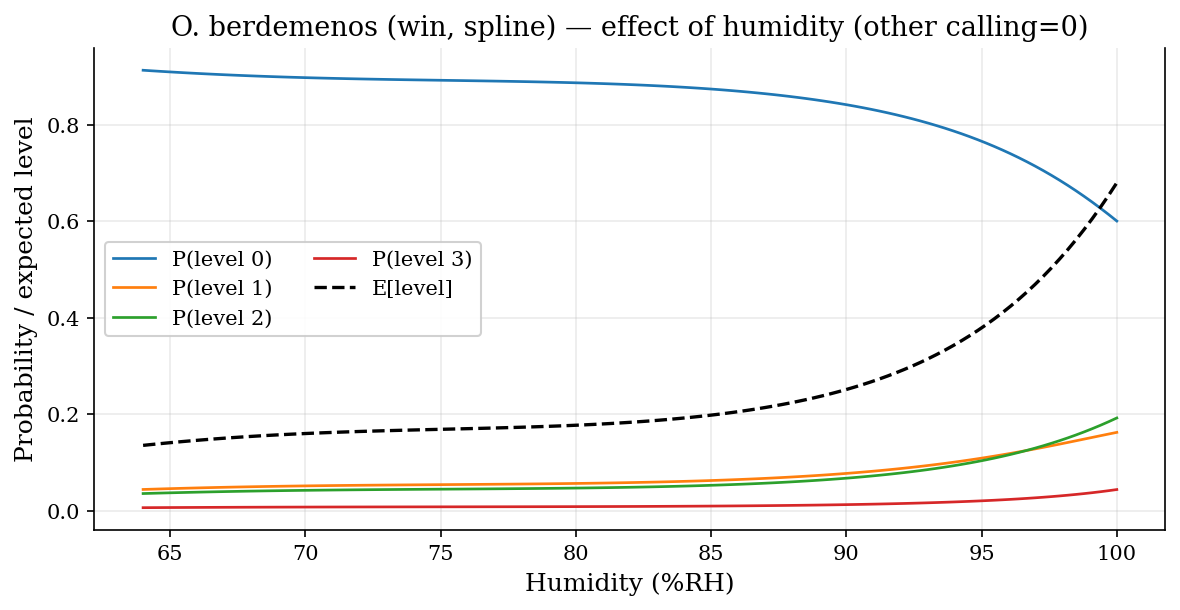

  ✓ Saved: 045_curve_temp_spline_oreobates_win_other1.pdf 


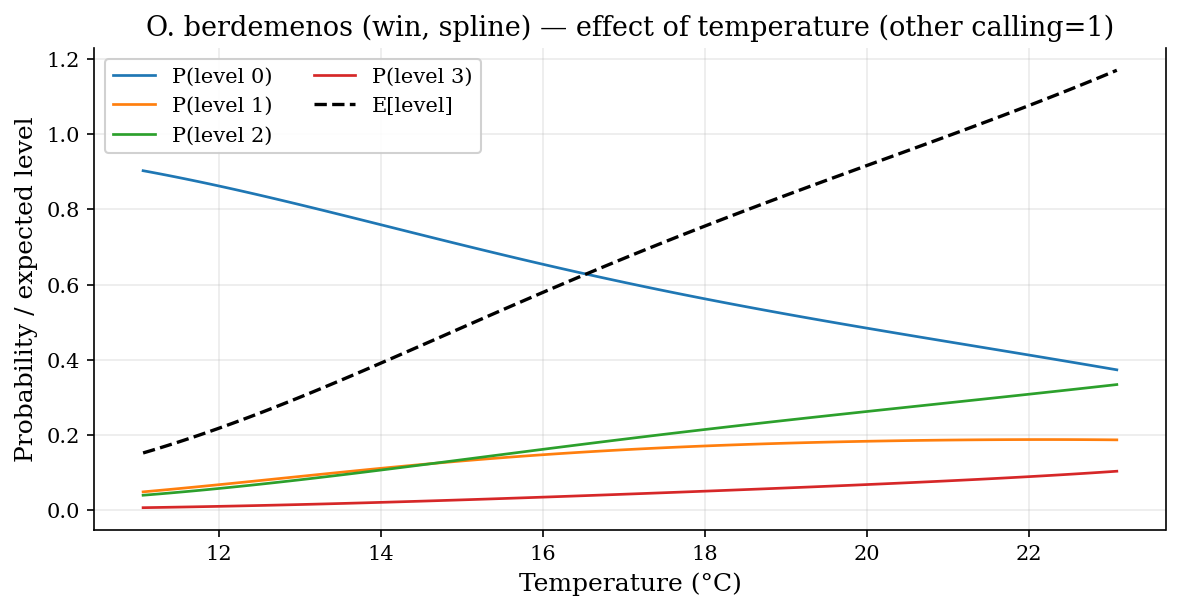

  ✓ Saved: 046_curve_rh_spline_oreobates_win_other1.pdf 


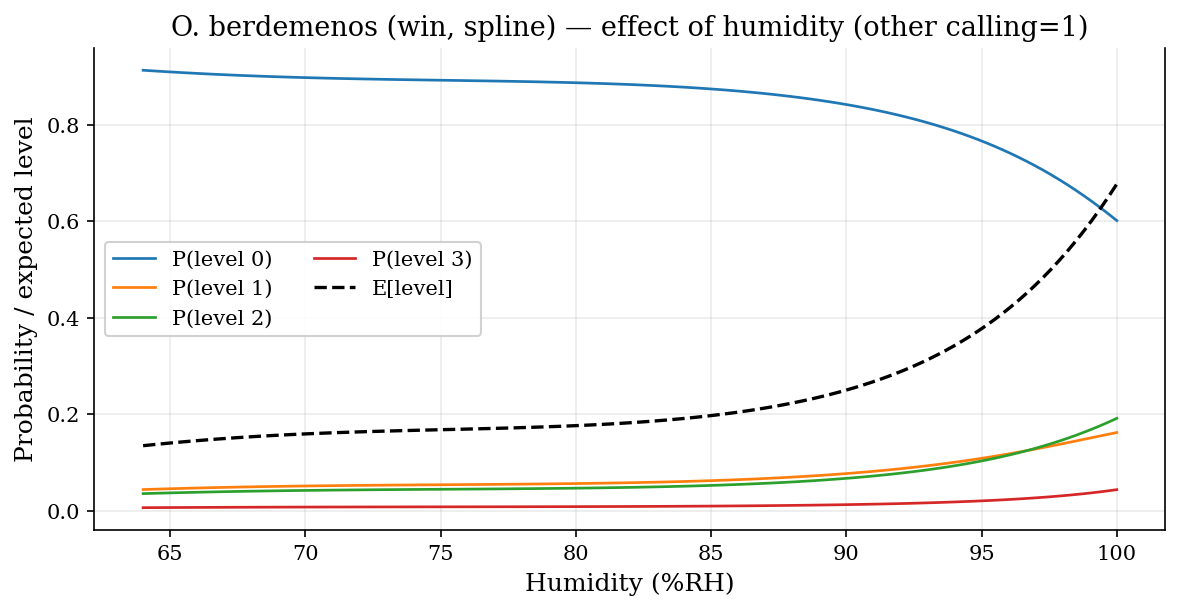

  ✓ Saved: 047_curve_temp_other_compare_spline_oreobates_win.pdf 


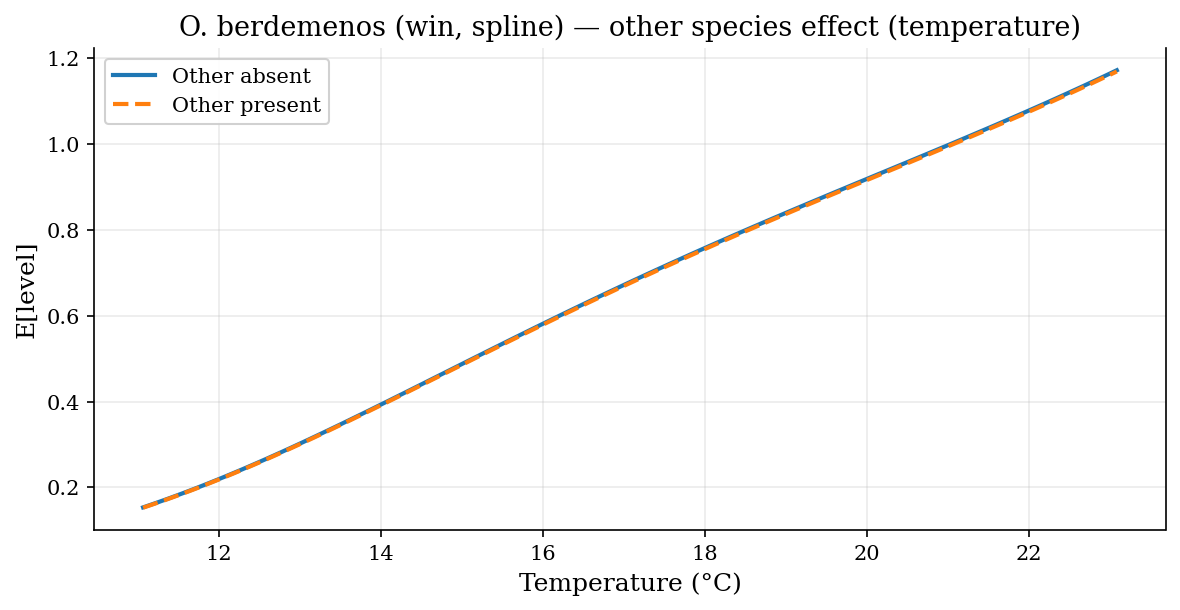

  ✓ Saved: 048_curve_rh_other_compare_spline_oreobates_win.pdf 


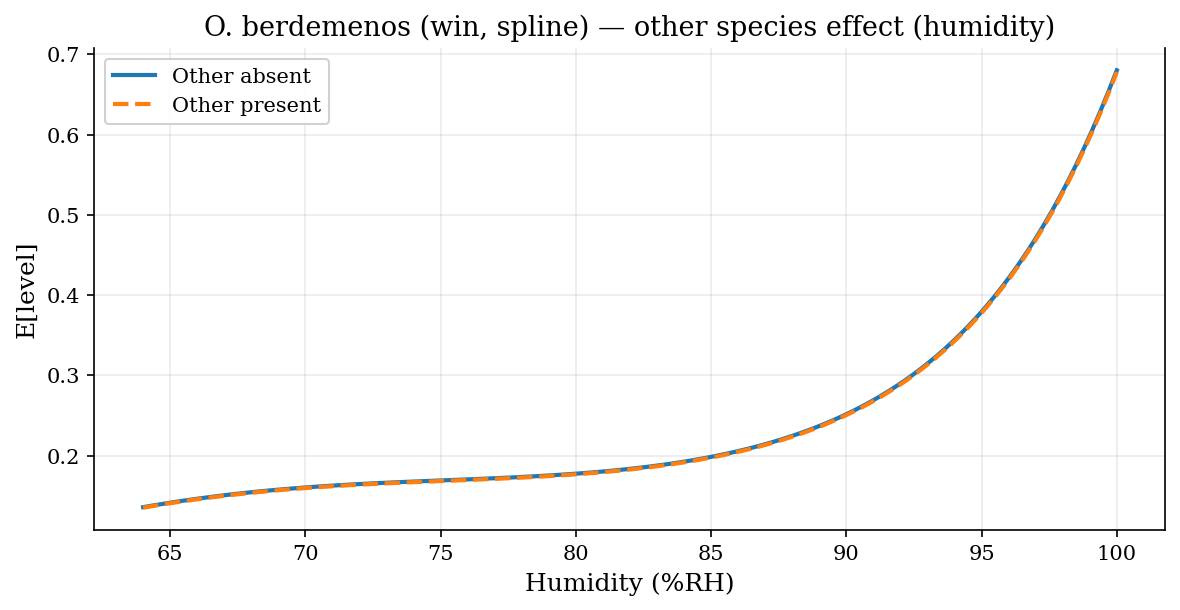

In [81]:
def add_z_cols(d: pd.DataFrame) -> pd.DataFrame:
    """Ensure Temp_z / RH_z exist and are clipped to spline bounds."""
    if "Temp" in d.columns:
        d["Temp_z"] = (d["Temp"] - TEMP_MEAN) / (TEMP_STD if TEMP_STD > 0 else 1.0)
        d["Temp_z"] = d["Temp_z"].clip(TEMPZ_BOUNDS[0], TEMPZ_BOUNDS[1])
    if "RH%" in d.columns:
        d["RH_z"] = (d["RH%"] - RH_MEAN) / (RH_STD if RH_STD > 0 else 1.0)
        d["RH_z"] = d["RH_z"].clip(RHZ_BOUNDS[0], RHZ_BOUNDS[1])
    return d

def fourier_terms_scalar(hour: float, doy: float):
    return {
        "sin_h1": np.sin(two_pi * hour/24.0),
        "cos_h1": np.cos(two_pi * hour/24.0),
        "sin_h2": np.sin(2*two_pi * hour/24.0),
        "cos_h2": np.cos(2*two_pi * hour/24.0),
        "sin_d1": np.sin(two_pi * doy/366.0),
        "cos_d1": np.cos(two_pi * doy/366.0),
        "sin_d2": np.sin(2*two_pi * doy/366.0),
        "cos_d2": np.cos(two_pi * doy/366.0),
    }

# def predict_1d_curve(res, design_info, var: str, grid: np.ndarray,
#                      hour: float, doy: float, other_calling: int,
#                      fixed_temp: float, fixed_rh: float):
#     rows = []
#     f = fourier_terms_scalar(hour, doy)
#     for x in grid:
#         if var == "temp":
#             t = x
#             r = fixed_rh
#         elif var == "rh":
#             t = fixed_temp
#             r = x
#         else:
#             raise ValueError(var)
#         rows.append({"Temp": t, "RH%": r, "other_calling": other_calling, **f})
#     new_df = pd.DataFrame(rows)
#     Xnew = dmatrix(design_info, new_df, return_type="dataframe")
#     probs = res.model.predict(res.params, exog=Xnew, which="prob")
#     probs_np = np.asarray(probs)
#     out = pd.DataFrame({"x": grid})
#     for k in range(probs_np.shape[1]):
#         out[f"p{k}"] = probs_np[:, k]
#     out["E_y"] = sum(k * out[f"p{k}"] for k in range(probs_np.shape[1]))
#     return out

def predict_1d_curve(res, design_info, var: str, grid: np.ndarray,
                     hour: float, doy: float, other_calling: int,
                     fixed_temp: float, fixed_rh: float):
    rows = []
    f = fourier_terms_scalar(hour, doy)
    for x in grid:
        if var == "temp":
            t = x
            r = fixed_rh
        elif var == "rh":
            t = fixed_temp
            r = x
        else:
            raise ValueError(var)
        rows.append({"Temp": t, "RH%": r, "other_calling": other_calling, **f})
    new_df = pd.DataFrame(rows)
    new_df = add_z_cols(new_df)
    Xnew = dmatrix(design_info, new_df, return_type="dataframe")
    probs = res.model.predict(res.params, exog=Xnew, which="prob")
    probs_np = np.asarray(probs)
    out = pd.DataFrame({"x": grid})
    for k in range(probs_np.shape[1]):
        out[f"p{k}"] = probs_np[:, k]
    out["E_y"] = sum(k * out[f"p{k}"] for k in range(probs_np.shape[1]))
    return out



def plot_curve(out: pd.DataFrame, xlabel: str, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for k in [0, 1, 2, 3]:
        ax.plot(out["x"], out[f"p{k}"], linewidth=1.3, label=f"P(level {k})")
    ax.plot(out["x"], out["E_y"], linestyle="--", linewidth=1.6, color="black", label="E[level]")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability / expected level")
    ax.set_title(title)
    ax.legend(ncol=2, framealpha=0.9)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()

def plot_other_compare(out0: pd.DataFrame, out1: pd.DataFrame, xlabel: str, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.plot(out0["x"], out0["E_y"], linewidth=2, label="Other absent")
    ax.plot(out1["x"], out1["E_y"], linewidth=2, linestyle="--", label="Other present")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("E[level]")
    ax.set_title(title)
    ax.legend(framealpha=0.9)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()

for fits, tag in [(fits_linear, "linear"), (fits_spline, "spline")]:
    for sp in SPECIES:
        for scope in ["win"]:
            d = fits[sp][scope]["df"]
            hour0 = float(d["hour"].median())
            doy0 = float(d["doy"].median())
            res = fits[sp][scope]["res"]
            di = fits[sp][scope]["design"]
            t_grid = np.linspace(d["Temp"].quantile(0.05), d["Temp"].quantile(0.95), 120)
            r_grid = np.linspace(d["RH%"].quantile(0.05), d["RH%"].quantile(0.95), 120)
            t0 = float(d["Temp"].median())
            r0 = float(d["RH%"].median())

            out_t0 = predict_1d_curve(res, di, var="temp", grid=t_grid, hour=hour0, doy=doy0, other_calling=0, fixed_temp=t0, fixed_rh=r0)
            out_t1 = predict_1d_curve(res, di, var="temp", grid=t_grid, hour=hour0, doy=doy0, other_calling=1, fixed_temp=t0, fixed_rh=r0)
            out_r0 = predict_1d_curve(res, di, var="rh", grid=r_grid, hour=hour0, doy=doy0, other_calling=0, fixed_temp=t0, fixed_rh=r0)
            out_r1 = predict_1d_curve(res, di, var="rh", grid=r_grid, hour=hour0, doy=doy0, other_calling=1, fixed_temp=t0, fixed_rh=r0)

            for other, out_t, out_r in [(0, out_t0, out_r0), (1, out_t1, out_r1)]:
                plot_curve(out_t, xlabel="Temperature (°C)",
                          title=f"{SP_SHORT[sp]} ({scope}, {tag}) — effect of temperature (other calling={other})",
                          fname=f"curve_temp_{tag}_{sp.split()[0].lower()}_{scope}_other{other}")
                plot_curve(out_r, xlabel="Humidity (%RH)",
                          title=f"{SP_SHORT[sp]} ({scope}, {tag}) — effect of humidity (other calling={other})",
                          fname=f"curve_rh_{tag}_{sp.split()[0].lower()}_{scope}_other{other}")

            plot_other_compare(
                out_t0, out_t1,
                xlabel="Temperature (°C)",
                title=f"{SP_SHORT[sp]} ({scope}, {tag}) — other species effect (temperature)",
                fname=f"curve_temp_other_compare_{tag}_{sp.split()[0].lower()}_{scope}"
            )
            plot_other_compare(
                out_r0, out_r1,
                xlabel="Humidity (%RH)",
                title=f"{SP_SHORT[sp]} ({scope}, {tag}) — other species effect (humidity)",
                fname=f"curve_rh_other_compare_{tag}_{sp.split()[0].lower()}_{scope}"
            )

## 9. ALE + PDP (1D, Temp and RH)
We compute simple 1D partial dependence (PDP) and accumulated local effects (ALE) for Temp and RH.

  ✓ Saved: 049_ale_pdp_linear_gastrotheca_win_temp.pdf 


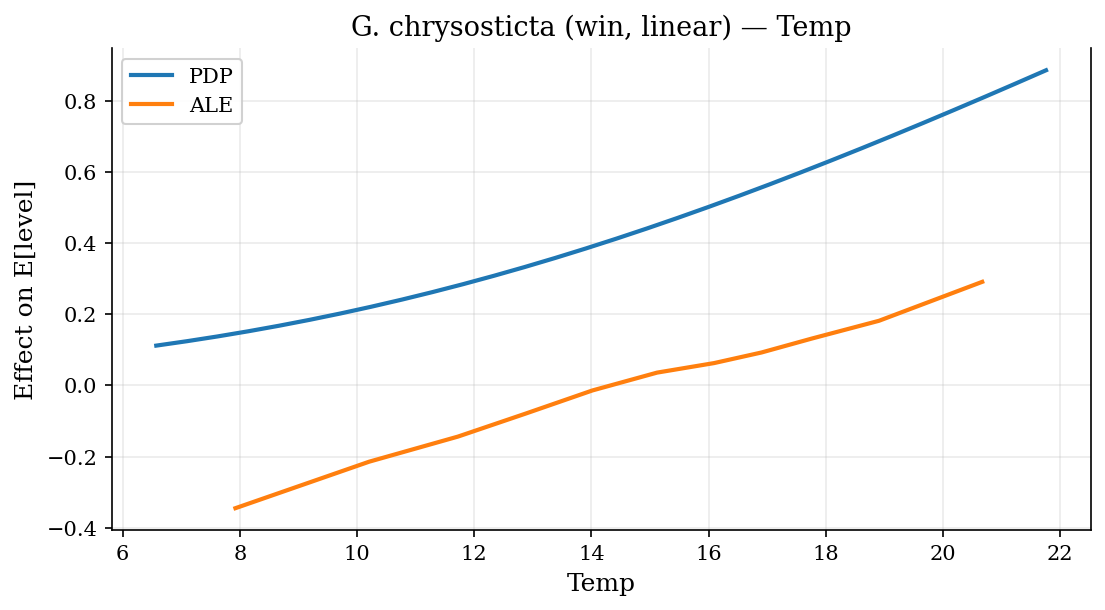

  ✓ Saved: 050_ale_pdp_linear_gastrotheca_win_rh.pdf 


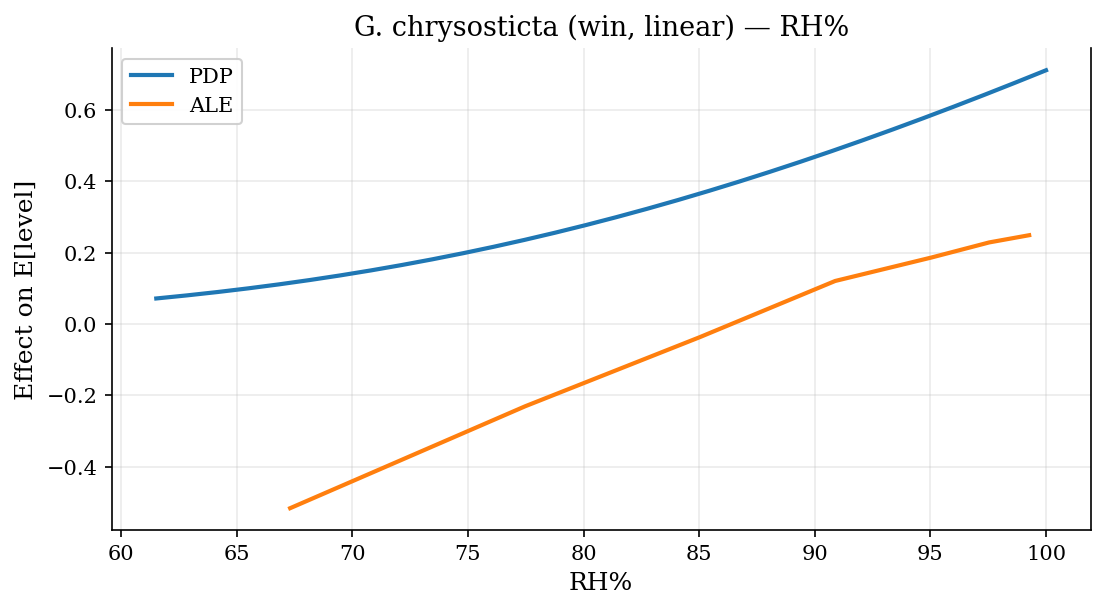

  ✓ Saved: 051_ale_pdp_other_linear_gastrotheca_win_temp.pdf 


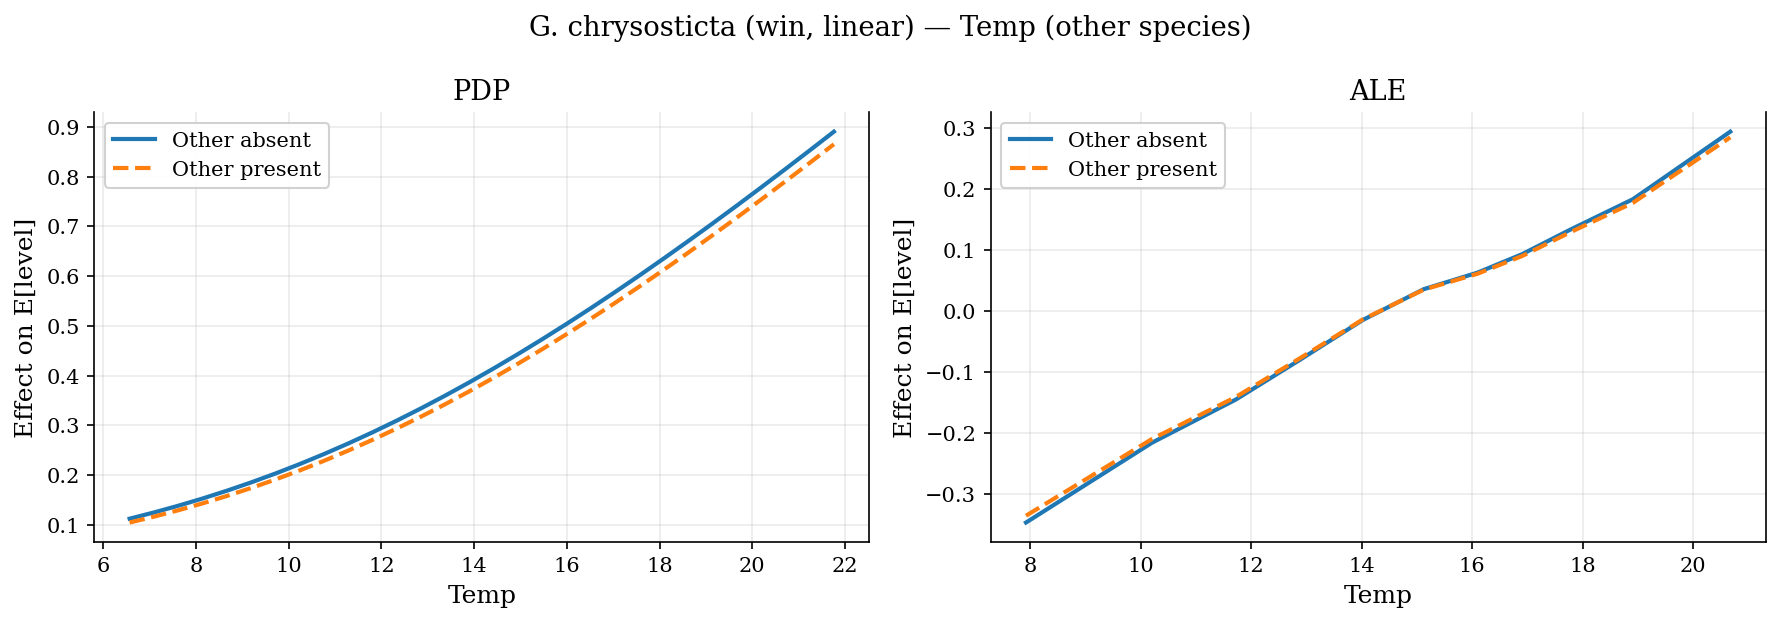

  ✓ Saved: 052_ale_pdp_other_linear_gastrotheca_win_rh.pdf 


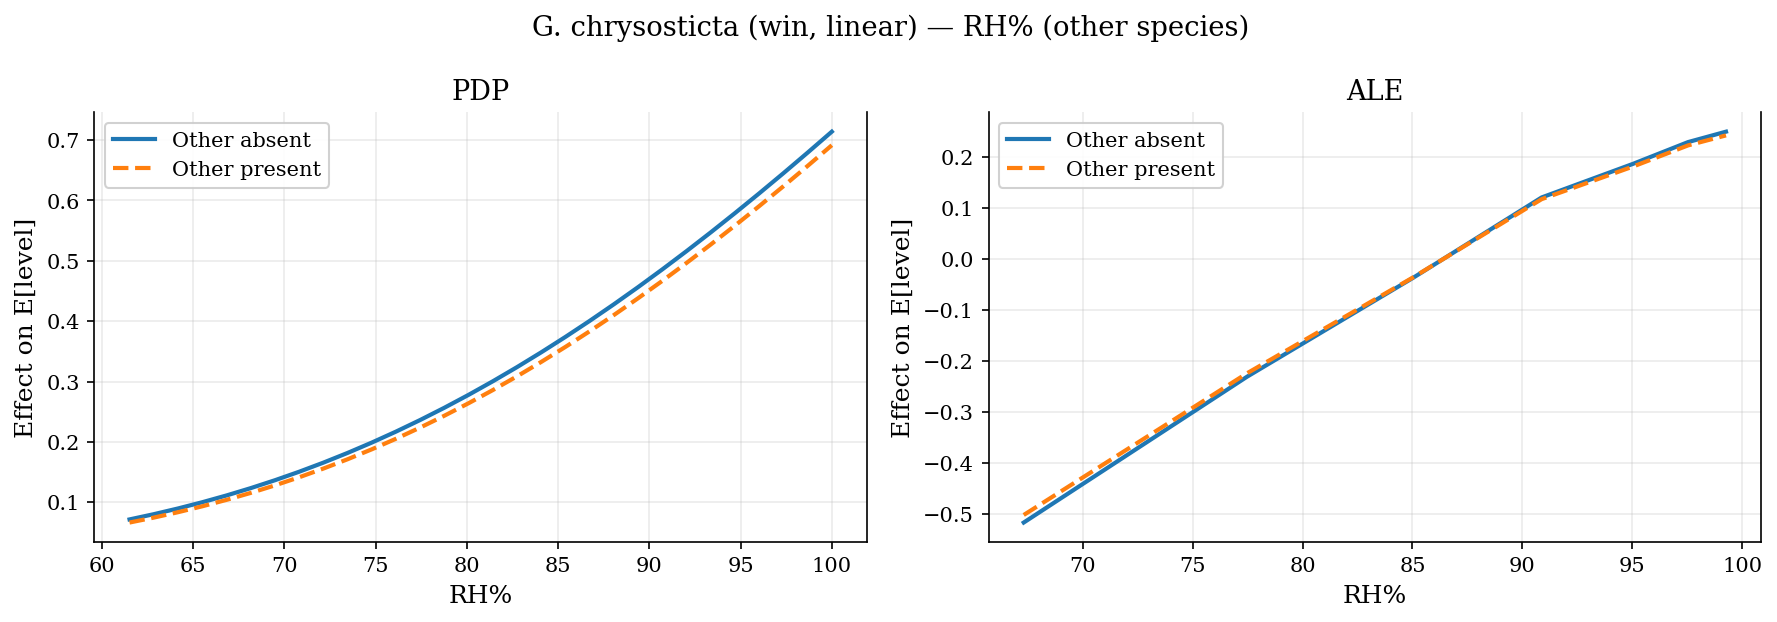

  ✓ Saved: 053_pdp_other_calling_linear_gastrotheca_win.pdf 


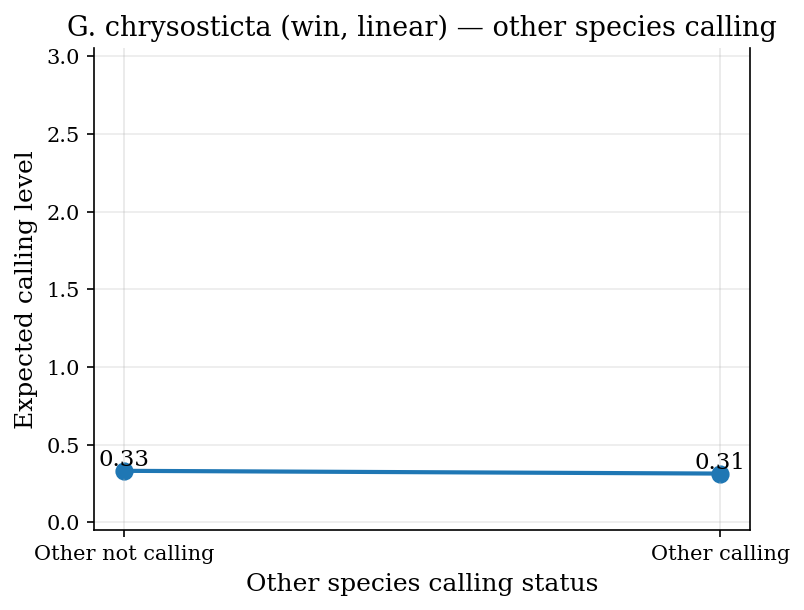

  ✓ Saved: 054_ale_pdp_linear_oreobates_win_temp.pdf 


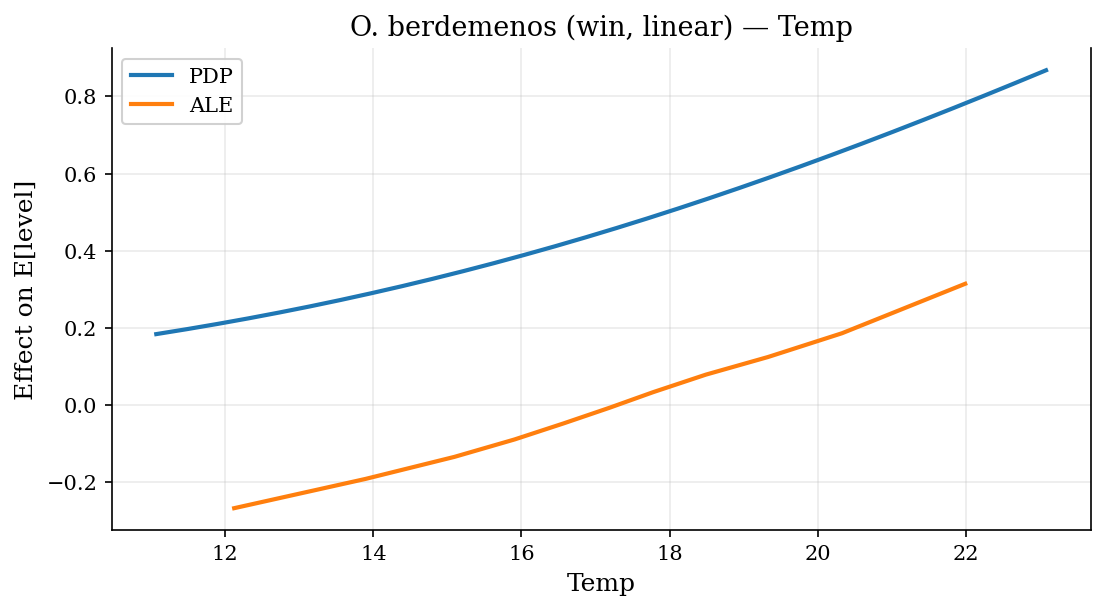

  ✓ Saved: 055_ale_pdp_linear_oreobates_win_rh.pdf 


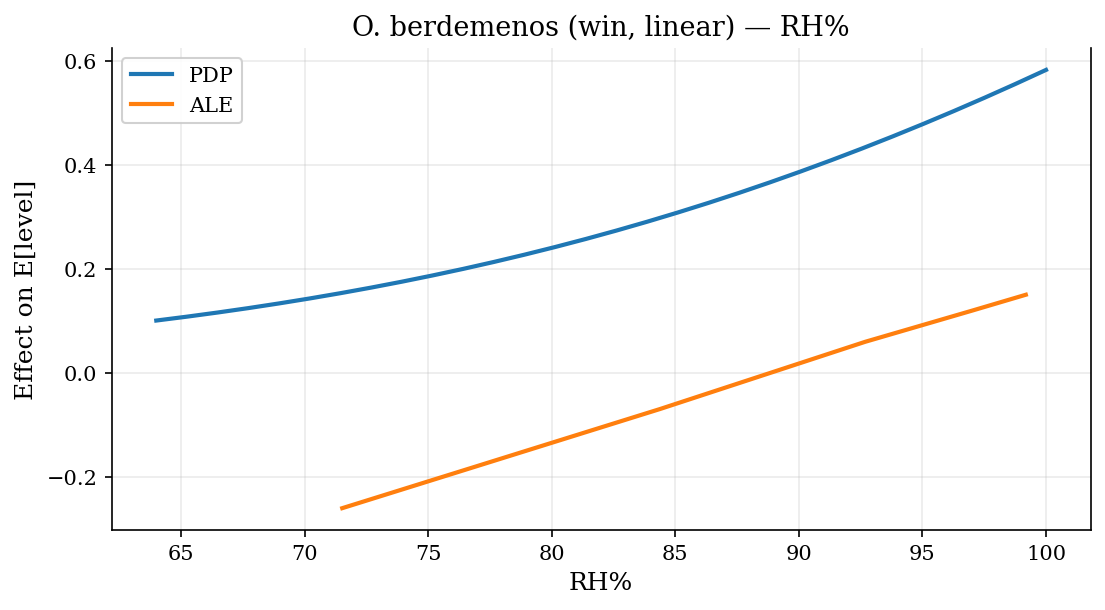

  ✓ Saved: 056_ale_pdp_other_linear_oreobates_win_temp.pdf 


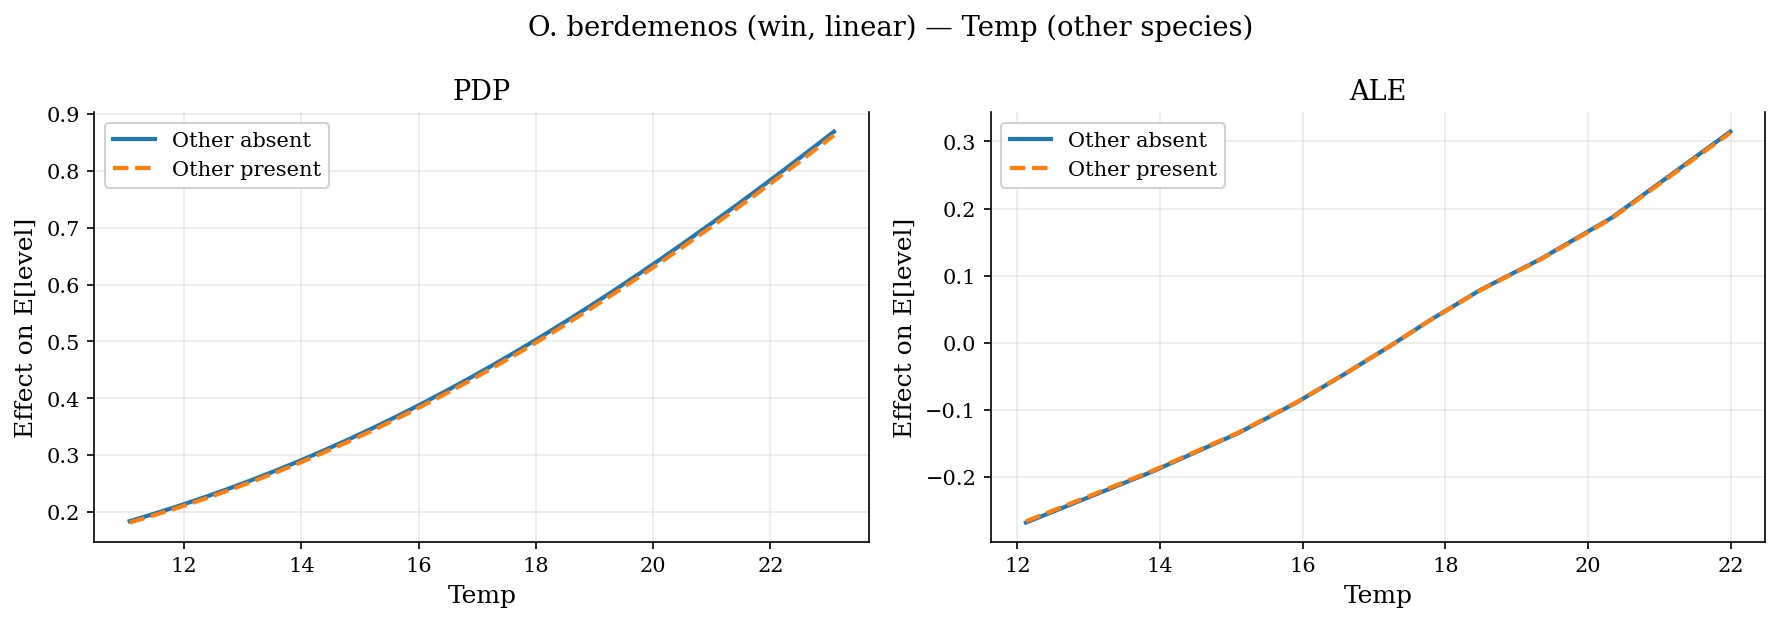

  ✓ Saved: 057_ale_pdp_other_linear_oreobates_win_rh.pdf 


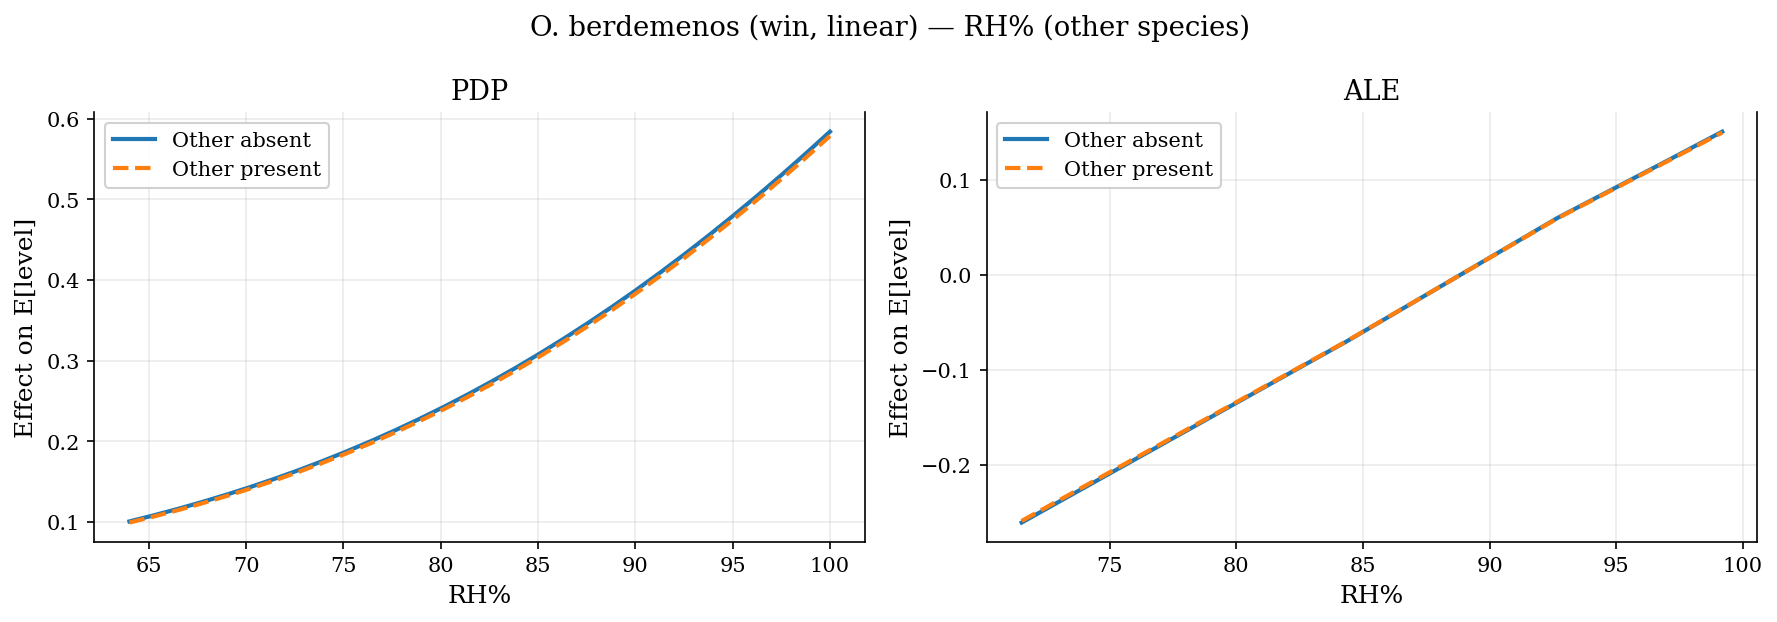

  ✓ Saved: 058_pdp_other_calling_linear_oreobates_win.pdf 


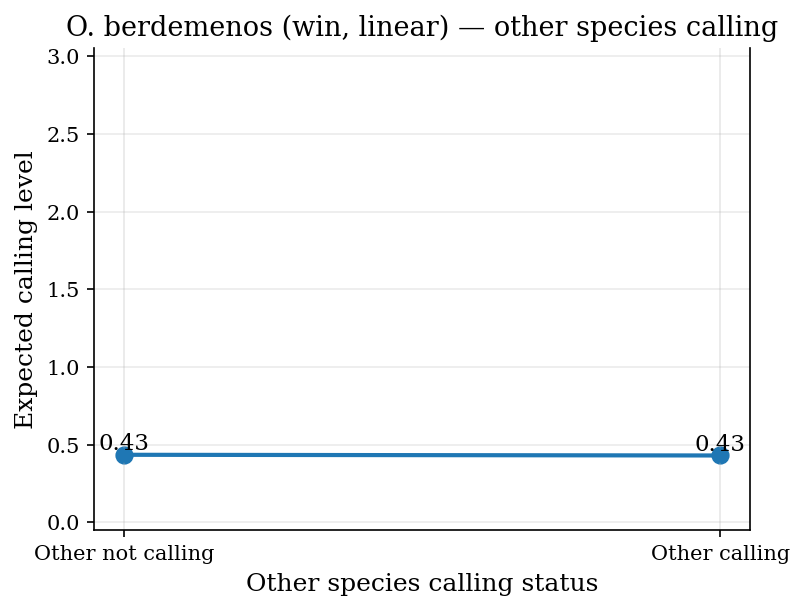

  ✓ Saved: 059_ale_pdp_spline_gastrotheca_win_temp.pdf 


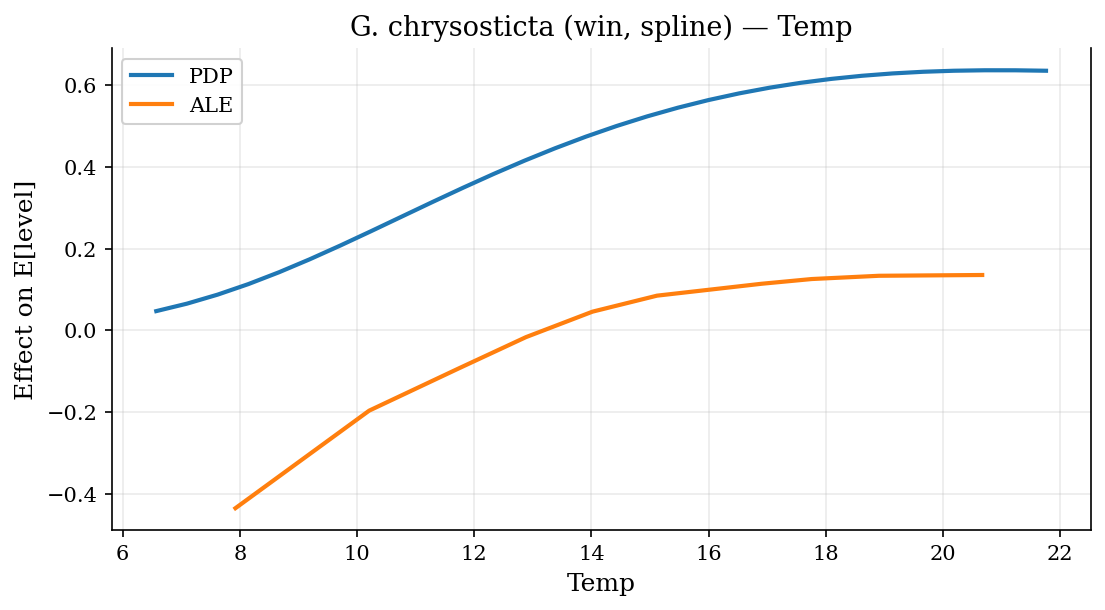

  ✓ Saved: 060_ale_pdp_spline_gastrotheca_win_rh.pdf 


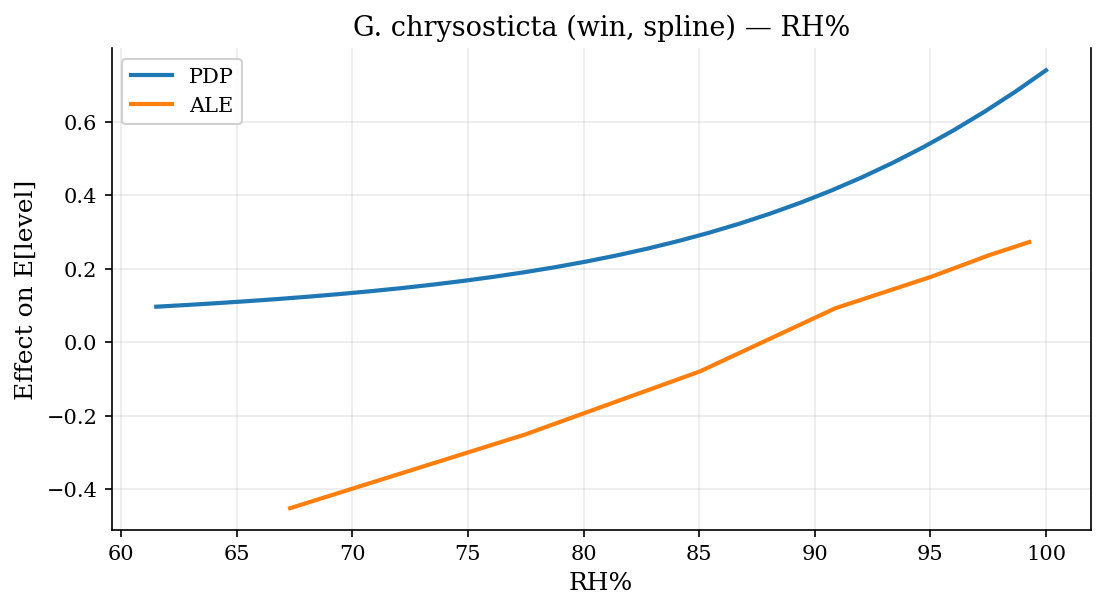

  ✓ Saved: 061_ale_pdp_other_spline_gastrotheca_win_temp.pdf 


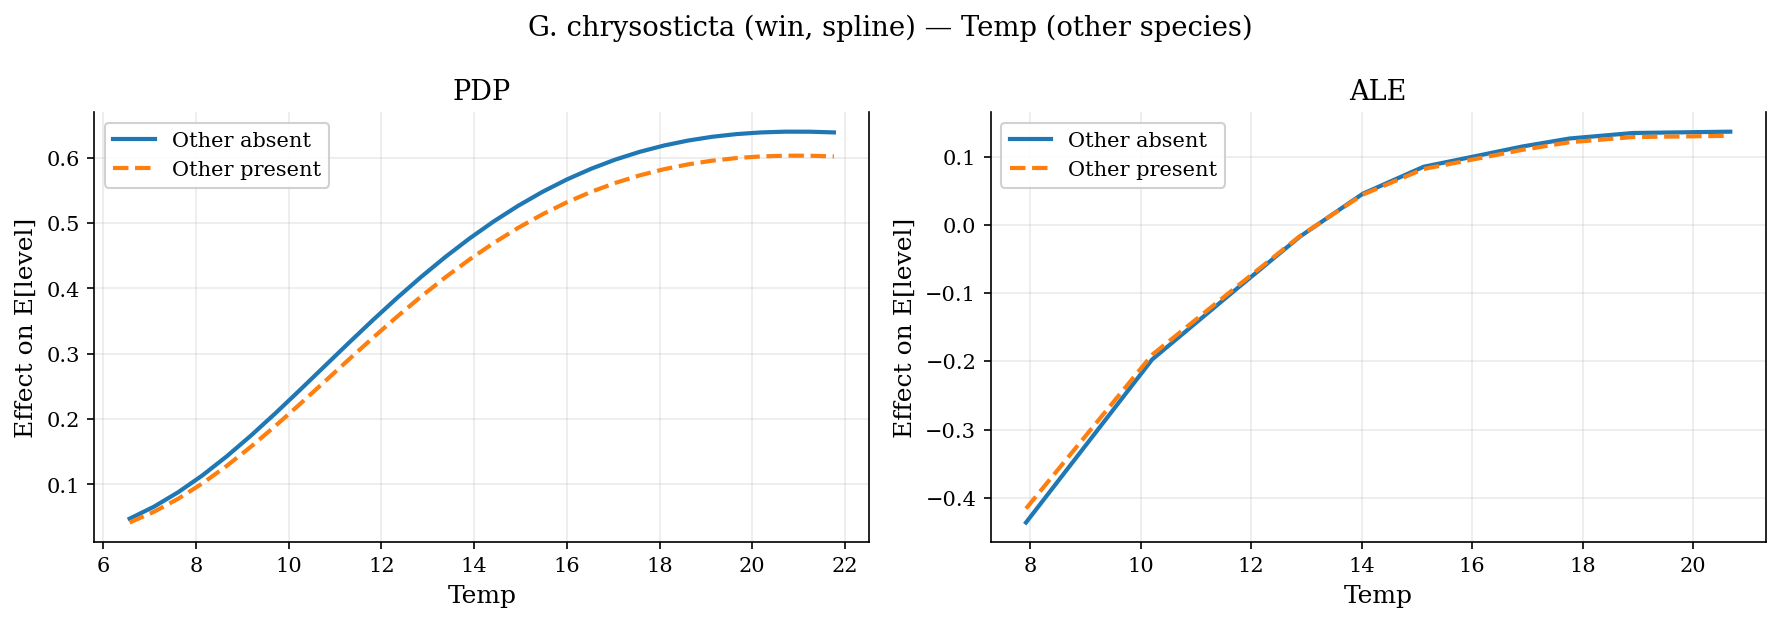

  ✓ Saved: 062_ale_pdp_other_spline_gastrotheca_win_rh.pdf 


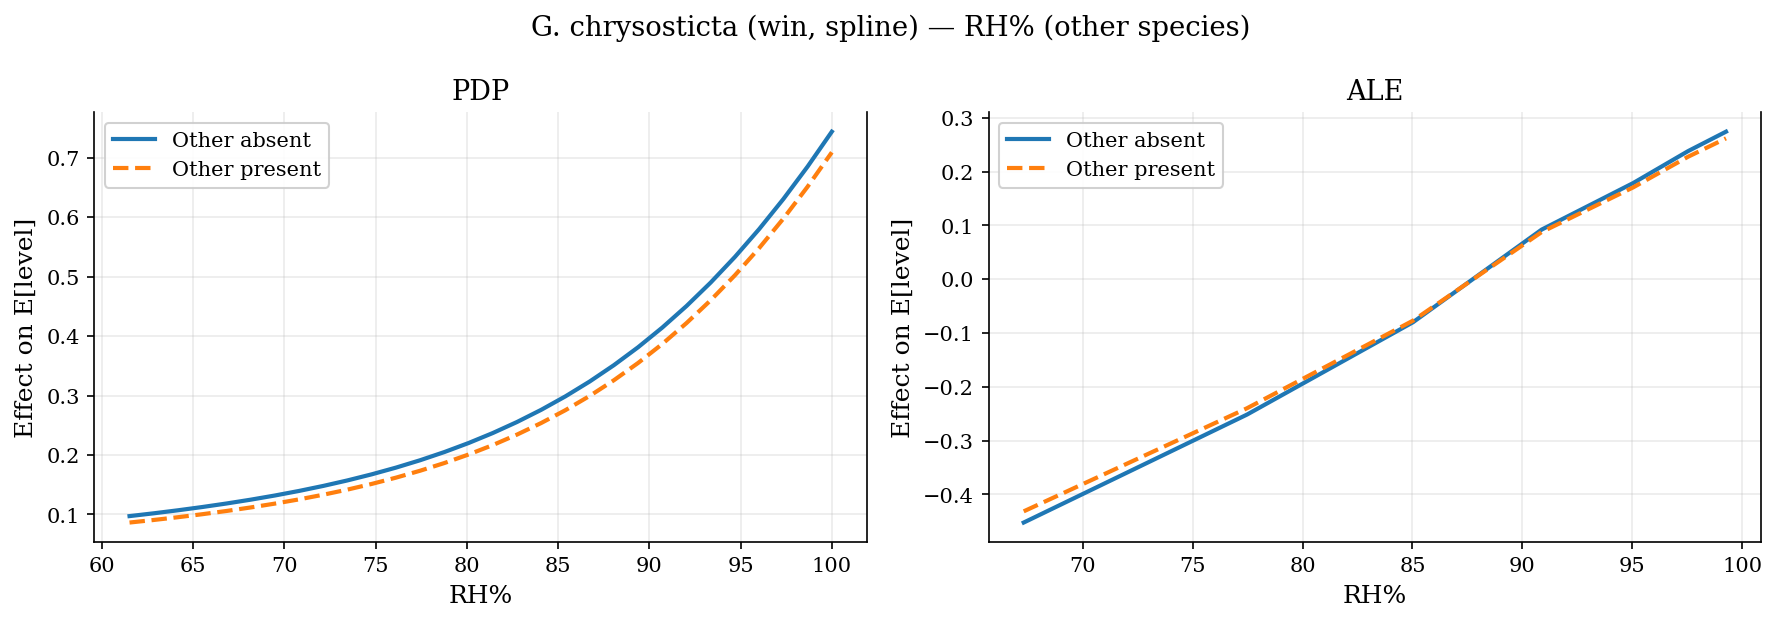

  ✓ Saved: 063_pdp_other_calling_spline_gastrotheca_win.pdf 


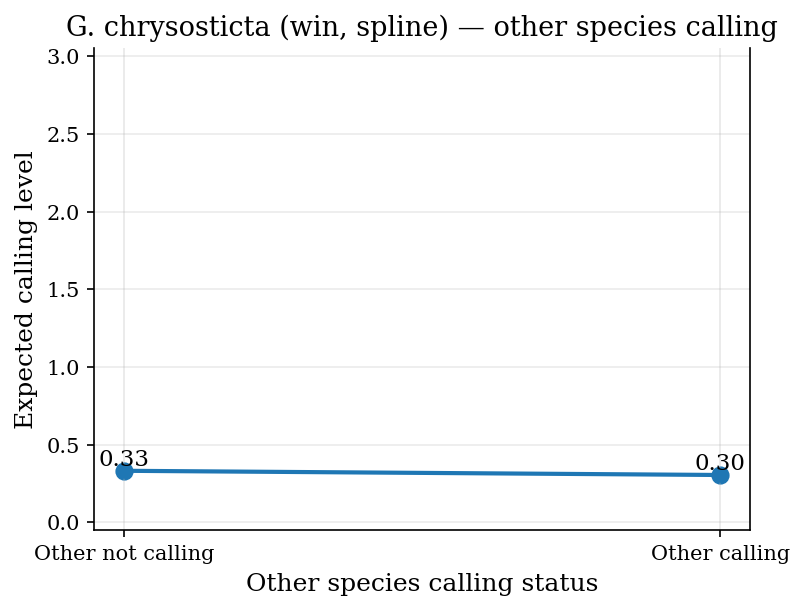

  ✓ Saved: 064_ale_pdp_spline_oreobates_win_temp.pdf 


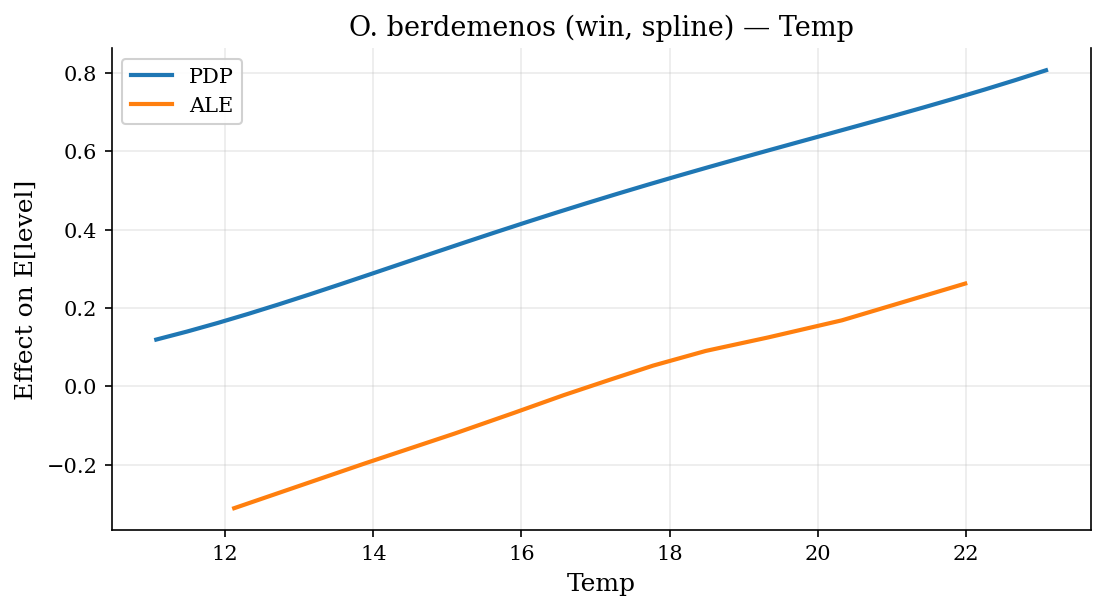

  ✓ Saved: 065_ale_pdp_spline_oreobates_win_rh.pdf 


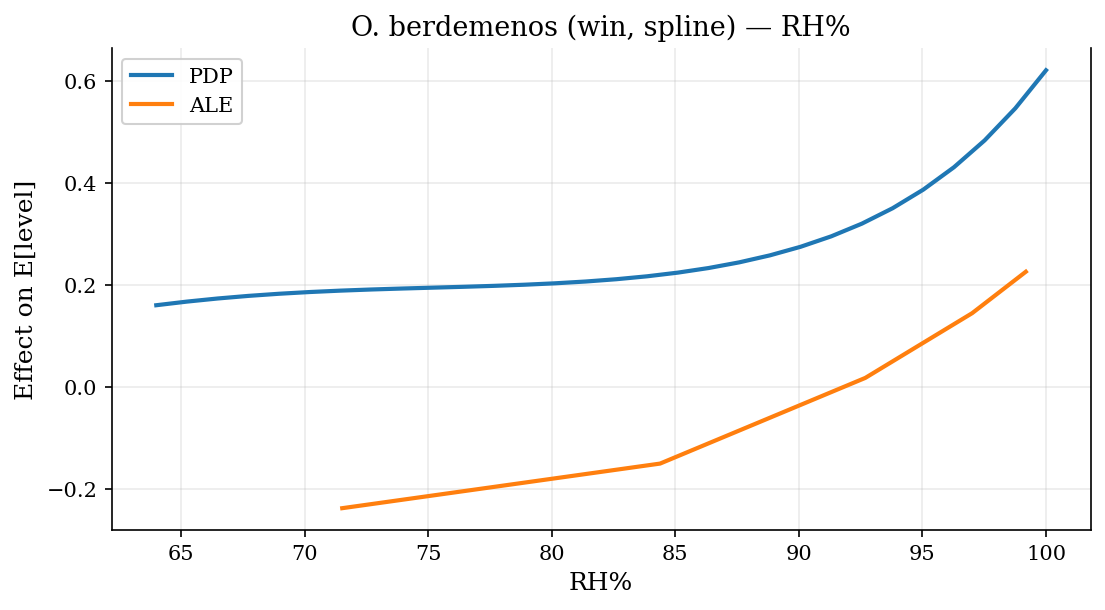

  ✓ Saved: 066_ale_pdp_other_spline_oreobates_win_temp.pdf 


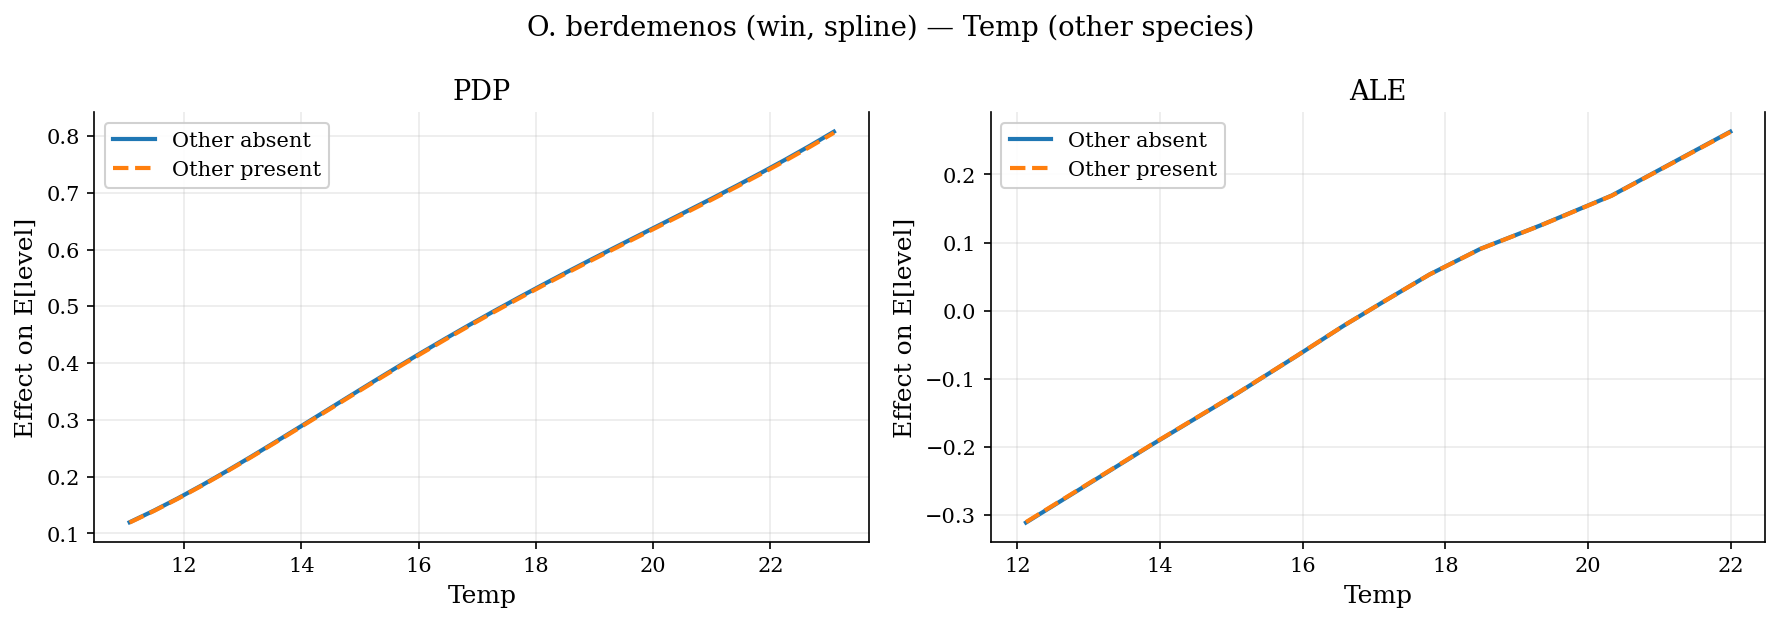

  ✓ Saved: 067_ale_pdp_other_spline_oreobates_win_rh.pdf 


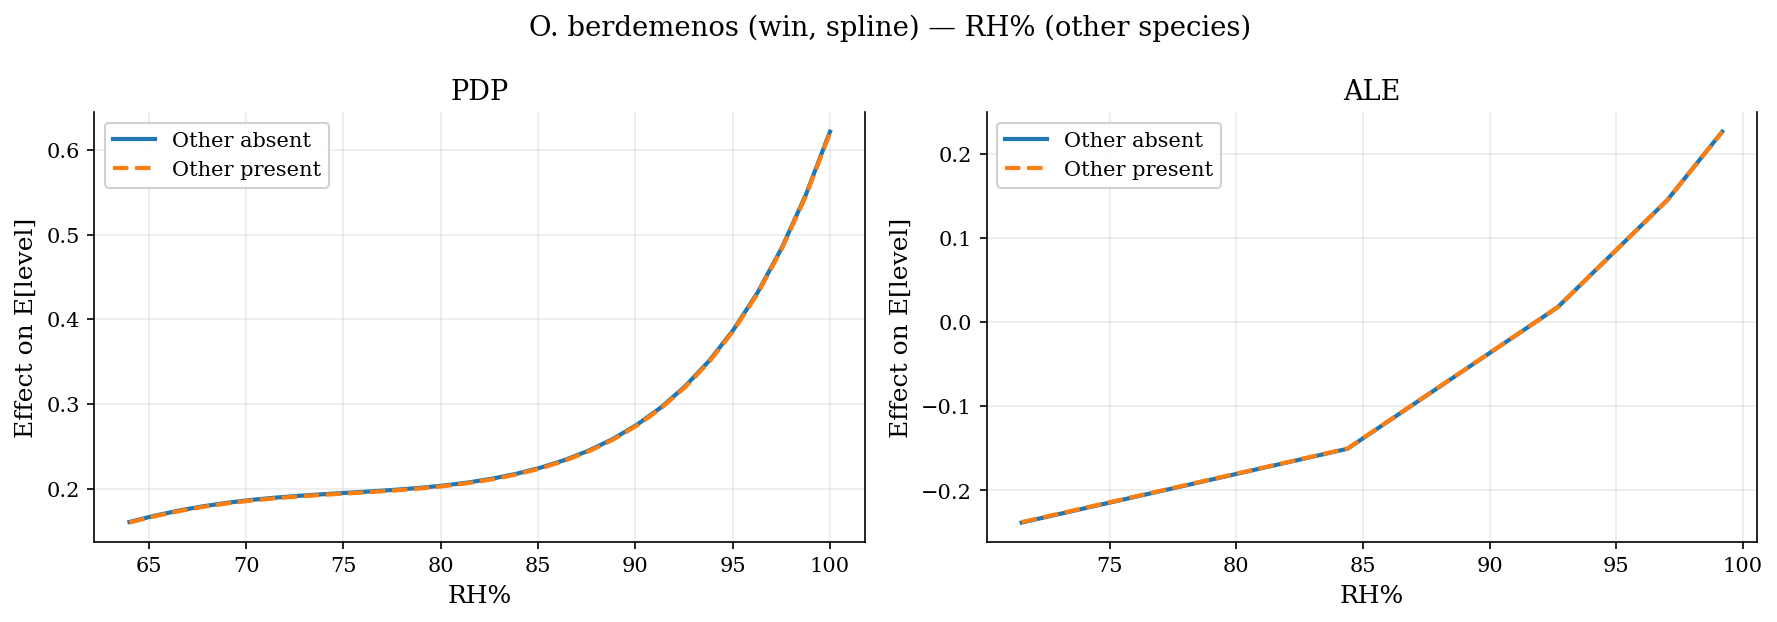

  ✓ Saved: 068_pdp_other_calling_spline_oreobates_win.pdf 


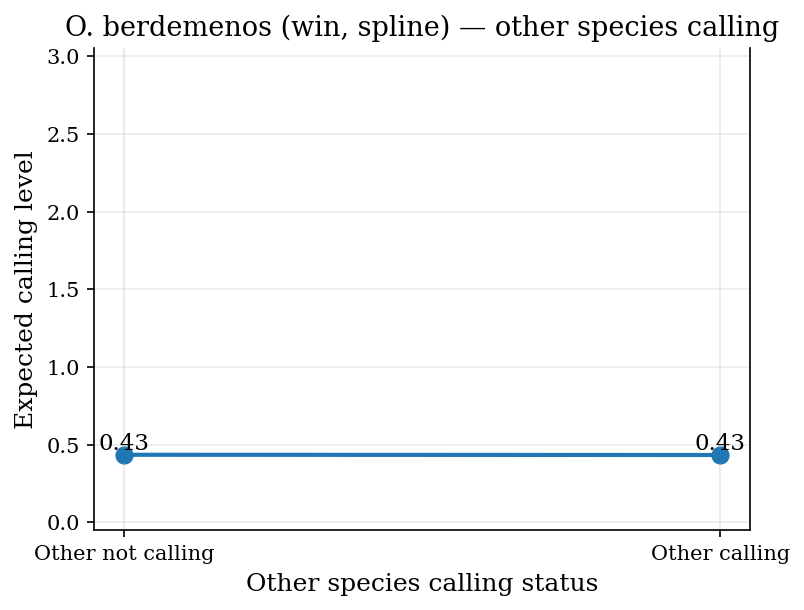

In [82]:


def pdp_1d(res, design_info, d: pd.DataFrame, var: str, grid: np.ndarray):
    base = d.copy()
    out = []
    for x in grid:
        base[var] = x
        base = add_z_cols(base)
        out.append(expected_level(res, design_info, base).mean())
    return pd.DataFrame({"x": grid, "pdp": out})

def pdp_1d_conditional(res, design_info, d: pd.DataFrame, var: str, grid: np.ndarray, other_calling: int):
    base = d.copy()
    base["other_calling"] = other_calling
    out = []
    for x in grid:
        base[var] = x
        base = add_z_cols(base)
        out.append(expected_level(res, design_info, base).mean())
    return pd.DataFrame({"x": grid, "pdp": out})

def ale_1d(res, design_info, d: pd.DataFrame, var: str, grid: np.ndarray):
    # Simple ALE with adjacent bin differences
    vals = d[var].values
    bins = np.quantile(vals, grid)
    bins = np.unique(bins)
    if len(bins) < 3:
        return pd.DataFrame({"x": bins, "ale": np.zeros_like(bins)})
    effects = []
    centers = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (vals >= lo) & (vals <= hi)
        if mask.sum() < 5:
            effects.append(0.0)
            centers.append(0.5 * (lo + hi))
            continue
        d_lo = d.loc[mask].copy()
        d_hi = d.loc[mask].copy()
        d_lo[var] = lo
        d_hi[var] = hi
        d_lo = add_z_cols(d_lo)
        d_hi = add_z_cols(d_hi)
        eff = expected_level(res, design_info, d_hi).mean() - expected_level(res, design_info, d_lo).mean()
        effects.append(eff)
        centers.append(0.5 * (lo + hi))
    ale = np.cumsum(effects)
    ale = ale - np.mean(ale)
    return pd.DataFrame({"x": centers, "ale": ale})

def ale_1d_conditional(res, design_info, d: pd.DataFrame, var: str, grid: np.ndarray, other_calling: int):
    base = d.copy()
    base["other_calling"] = other_calling
    return ale_1d(res, design_info, base, var, grid)

def plot_ale_pdp(res, design_info, d: pd.DataFrame, var: str, tag: str, sp: str, scope: str):
    grid = np.linspace(d[var].quantile(0.05), d[var].quantile(0.95), 30)
    pdp = pdp_1d(res, design_info, d, var, grid)
    ale = ale_1d(res, design_info, d, var, np.linspace(0.05, 0.95, 12))
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(pdp["x"], pdp["pdp"], label="PDP", linewidth=2)
    ax.plot(ale["x"], ale["ale"], label="ALE", linewidth=2)
    ax.set_xlabel(var)
    ax.set_ylabel("Effect on E[level]")
    ax.set_title(f"{SP_SHORT[sp]} ({scope}, {tag}) — {var}")
    ax.legend(framealpha=0.9)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    savefig(fig, f"ale_pdp_{tag}_{sp.split()[0].lower()}_{scope}_{var.lower().replace('%','')}")
    plt.show()

def plot_ale_pdp_other_compare(res, design_info, d: pd.DataFrame, var: str, tag: str, sp: str, scope: str):
    grid = np.linspace(d[var].quantile(0.05), d[var].quantile(0.95), 30)
    ale_grid = np.linspace(0.05, 0.95, 12)
    pdp0 = pdp_1d_conditional(res, design_info, d, var, grid, other_calling=0)
    pdp1 = pdp_1d_conditional(res, design_info, d, var, grid, other_calling=1)
    ale0 = ale_1d_conditional(res, design_info, d, var, ale_grid, other_calling=0)
    ale1 = ale_1d_conditional(res, design_info, d, var, ale_grid, other_calling=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
    axes[0].plot(pdp0["x"], pdp0["pdp"], linewidth=2, label="Other absent")
    axes[0].plot(pdp1["x"], pdp1["pdp"], linewidth=2, linestyle="--", label="Other present")
    axes[0].set_title("PDP")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("Effect on E[level]")
    axes[0].grid(alpha=0.25)
    axes[0].legend(framealpha=0.9)

    axes[1].plot(ale0["x"], ale0["ale"], linewidth=2, label="Other absent")
    axes[1].plot(ale1["x"], ale1["ale"], linewidth=2, linestyle="--", label="Other present")
    axes[1].set_title("ALE")
    axes[1].set_xlabel(var)
    axes[1].set_ylabel("Effect on E[level]")
    axes[1].grid(alpha=0.25)
    axes[1].legend(framealpha=0.9)

    fig.suptitle(f"{SP_SHORT[sp]} ({scope}, {tag}) — {var} (other species)")
    fig.tight_layout()
    savefig(fig, f"ale_pdp_other_{tag}_{sp.split()[0].lower()}_{scope}_{var.lower().replace('%','')}")
    plt.show()


def pdp_binary_other_calling(res, design_info, d: pd.DataFrame):
    """
    Partial dependence of expected calling level on whether the other species
    is calling. All other covariates are left at their observed values.
    """
    out = []
    for val in [0, 1]:
        base = d.copy()
        base["other_calling"] = val
        out.append({
            "other_calling": val,
            "label": "Other not calling" if val == 0 else "Other calling",
            "pdp": expected_level(res, design_info, base).mean()
        })

    return pd.DataFrame(out)


def plot_pdp_other_calling(res, design_info, d: pd.DataFrame, tag: str, sp: str, scope: str):
    """
    Plot PDP of expected calling level against other-species calling status.
    """
    pdp = pdp_binary_other_calling(res, design_info, d)

    fig, ax = plt.subplots(figsize=(5.5, 4.2))

    ax.plot(
        pdp["label"],
        pdp["pdp"],
        marker="o",
        linewidth=2
    )

    ax.scatter(
        pdp["label"],
        pdp["pdp"],
        s=60
    )

    ax.set_xlabel("Other species calling status")
    ax.set_ylabel("Expected calling level")
    ax.set_title(f"{SP_SHORT[sp]} ({scope}, {tag}) — other species calling")
    ax.set_ylim(-0.05, 3.05)
    ax.grid(axis="y", alpha=0.25)

    for i, row in pdp.iterrows():
        ax.text(
            i,
            row["pdp"],
            f"{row['pdp']:.2f}",
            ha="center",
            va="bottom"
        )

    fig.tight_layout()
    savefig(fig, f"pdp_other_calling_{tag}_{sp.split()[0].lower()}_{scope}")
    plt.show()

    return pdp

other_calling_pdp_results = {}

for fits, tag in [(fits_linear, "linear"), (fits_spline, "spline")]:
    for sp in SPECIES:
        for scope in ["win"]:
            res = fits[sp][scope]["res"]
            di = fits[sp][scope]["design"]
            d = fits[sp][scope]["df"]
            plot_ale_pdp(res, di, d, var="Temp", tag=tag, sp=sp, scope=scope)
            plot_ale_pdp(res, di, d, var="RH%", tag=tag, sp=sp, scope=scope)
            plot_ale_pdp_other_compare(res, di, d, var="Temp", tag=tag, sp=sp, scope=scope)
            plot_ale_pdp_other_compare(res, di, d, var="RH%", tag=tag, sp=sp, scope=scope)
            pdp_other = plot_pdp_other_calling(
                res=res,
                design_info=di,
                d=d,
                tag=tag,
                sp=sp,
                scope=scope
            )

            other_calling_pdp_results[(tag, sp, scope)] = pdp_other

## 10. Model comparison: AIC + blocked CV + out-of-sample performance
We compare linear vs spline models using AIC and time-blocked CV (contiguous blocks).

In [83]:
def r2_expected(y: pd.Series, yhat: pd.Series):
    y = y.astype(float)
    yhat = yhat.reindex(y.index)
    sst = float(((y - y.mean())**2).sum())
    sse = float(((y - yhat)**2).sum())
    return np.nan if sst == 0 else 1.0 - sse / sst

def expected_loglik(res, design_info, d: pd.DataFrame, y_col: str):
    X = dmatrix(design_info, d, return_type="dataframe")
    probs = res.model.predict(res.params, exog=X, which="prob")
    probs_np = np.asarray(probs)
    y = d[y_col].astype(int).values
    return np.mean(np.log(np.clip(probs_np[np.arange(len(y)), y], 1e-12, 1.0)))

def _make_block_folds(index: pd.DatetimeIndex, n_folds: int = 8):
    order = np.argsort(index.values)
    n = len(order)
    fold_id = np.full(n, -1, dtype=int)
    edges = np.linspace(0, n, n_folds + 1).astype(int)
    for k in range(n_folds):
        fold_id[edges[k]:edges[k+1]] = k
    inv = np.empty_like(order)
    inv[order] = np.arange(n)
    return fold_id[inv]

def blocked_cv_one(fits: dict, species: str, scope: str = "all", n_folds: int = 8):
    y_col = fits[species]["y_col"]
    base_df = fits[species][scope]["df"].copy().sort_index()
    fold_id = _make_block_folds(base_df.index, n_folds=n_folds)
    rows = []
    for k in range(n_folds):
        train = base_df.loc[fold_id != k].copy()
        test  = base_df.loc[fold_id == k].copy()
        if len(train) < 100 or len(test) < 50:
            continue
        res_k, di_k = fit_ordered_logit(train, y_col=y_col, formula=fits[species]["tag"] == "linear" and linear_formula or spline_formula)
        yhat = expected_level(res_k, di_k, test)
        rows.append({
            "fold": k,
            "n_train": int(len(train)),
            "n_test": int(len(test)),
            "r2_expected": float(r2_expected(test[y_col], yhat)),
            "loglik": float(expected_loglik(res_k, di_k, test, y_col=y_col)),
        })
    return pd.DataFrame(rows)

def compare_models(fits: dict, tag: str):
    rows = []
    for sp in SPECIES:
        y_col = fits[sp]["y_col"]
        for scope in ["all", "win"]:
            res = fits[sp][scope]["res"]
            di = fits[sp][scope]["design"]
            d = fits[sp][scope]["df"]
            yhat = expected_level(res, di, d)
            rows.append({
                "species": sp,
                "scope": scope,
                "tag": tag,
                "n": int(len(d)),
                "aic": float(res.aic),
                "r2_expected": float(r2_expected(d[y_col], yhat)),
                "loglik": float(expected_loglik(res, di, d, y_col=y_col)),
            })
    return pd.DataFrame(rows)

cmp = pd.concat([compare_models(fits_linear, "linear"), compare_models(fits_spline, "spline")], ignore_index=True)
cmp

,species,scope,tag,n,aic,r2_expected,loglik
0,Gastrotheca chrysosticta,all,linear,11303,5499.746952,0.488315,-0.242402
1,Gastrotheca chrysosticta,win,linear,5924,5228.697356,0.461849,-0.439627
2,Oreobates berdemenos,all,linear,11303,4558.424936,0.308841,-0.200762
3,Oreobates berdemenos,win,linear,2785,3788.826788,0.219567,-0.676630
4,Gastrotheca chrysosticta,all,spline,11303,5290.479082,0.537688,-0.232791
5,Gastrotheca chrysosticta,win,spline,5924,5005.829567,0.518741,-0.420141
6,Oreobates berdemenos,all,spline,11303,4509.512612,0.319169,-0.198244
7,Oreobates berdemenos,win,spline,2785,3764.642439,0.231285,-0.670851


In [84]:
print(cmp.sort_values(["species", "scope", "tag"]))


                    species scope     tag      n          aic  r2_expected    loglik
0  Gastrotheca chrysosticta   all  linear  11303  5499.746952     0.488315 -0.242402
4  Gastrotheca chrysosticta   all  spline  11303  5290.479082     0.537688 -0.232791
1  Gastrotheca chrysosticta   win  linear   5924  5228.697356     0.461849 -0.439627
5  Gastrotheca chrysosticta   win  spline   5924  5005.829567     0.518741 -0.420141
2      Oreobates berdemenos   all  linear  11303  4558.424936     0.308841 -0.200762
6      Oreobates berdemenos   all  spline  11303  4509.512612     0.319169 -0.198244
3      Oreobates berdemenos   win  linear   2785  3788.826788     0.219567 -0.676630
7      Oreobates berdemenos   win  spline   2785  3764.642439     0.231285 -0.670851


  ✓ Saved: 069_compare_aic.pdf 


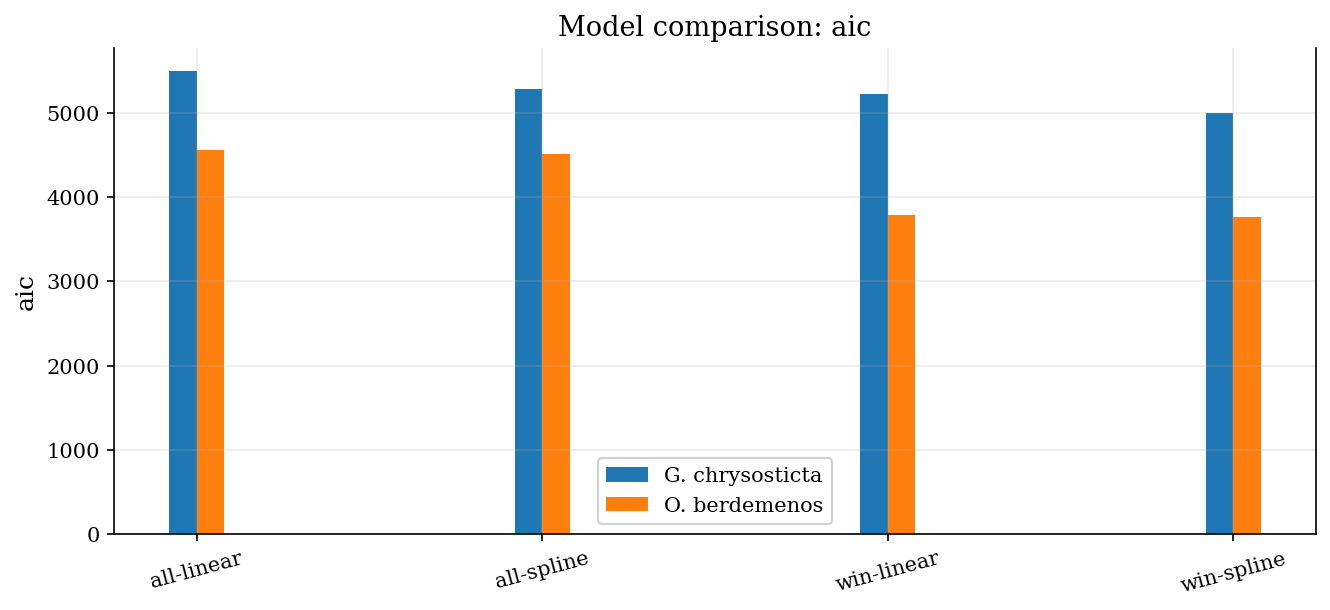

  ✓ Saved: 070_compare_r2_expected.pdf 


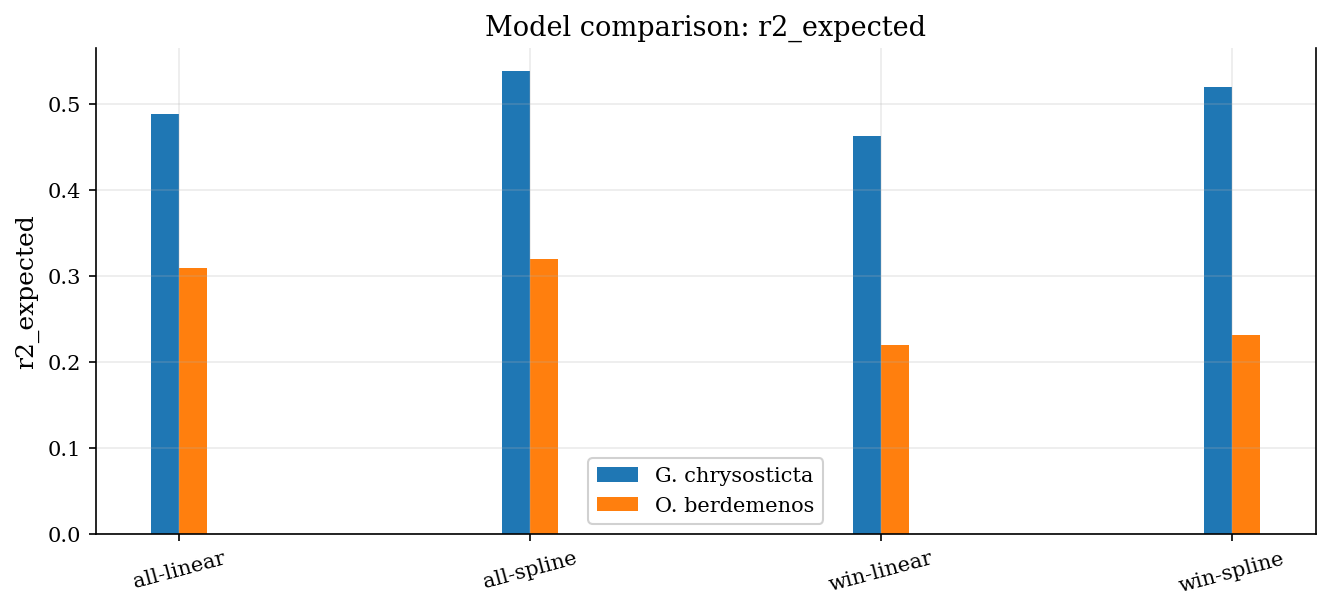

  ✓ Saved: 071_compare_loglik.pdf 


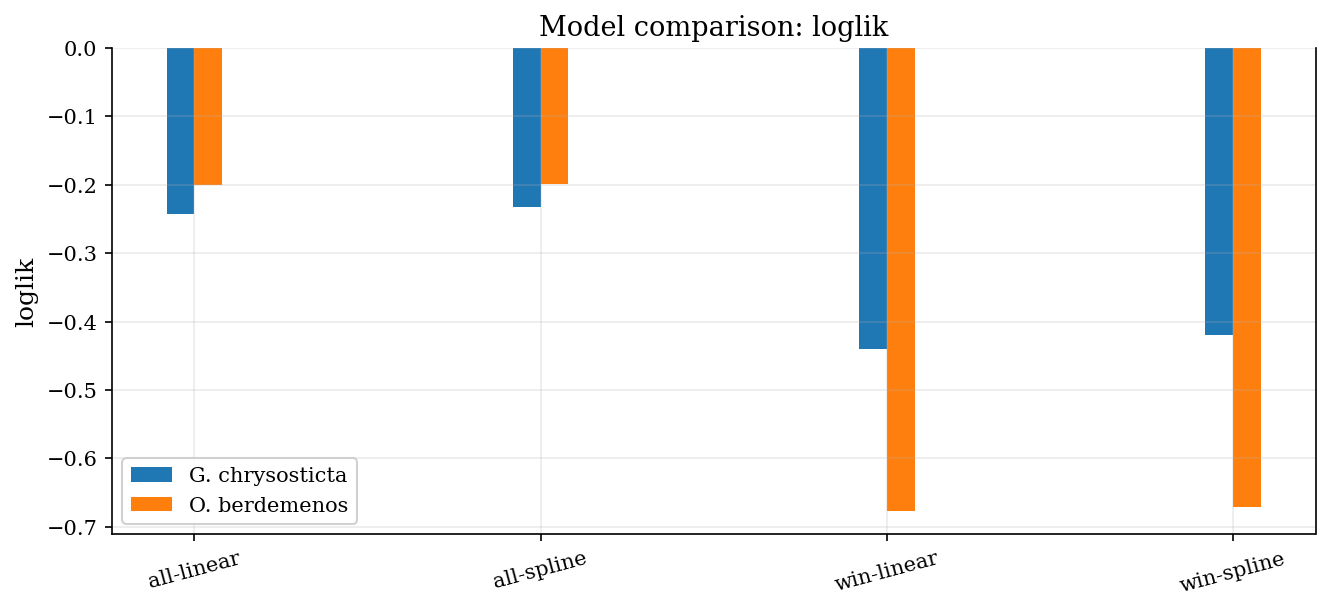

In [85]:
# Plot AIC comparison
for metric in ["aic", "r2_expected", "loglik"]:
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for i, sp in enumerate(SPECIES):
        sub = cmp[cmp["species"] == sp].sort_values(["scope", "tag"])
        xs = np.arange(len(sub)) + (i - 0.5) * 0.08
        ax.bar(xs, sub[metric].values, width=0.08, color=SP_COLOR[sp], label=SP_SHORT[sp])
    ax.set_title(f"Model comparison: {metric}")
    ax.set_ylabel(metric)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["all-linear", "all-spline", "win-linear", "win-spline"], rotation=15)
    ax.grid(alpha=0.25)
    ax.legend(framealpha=0.9)
    fig.tight_layout()
    savefig(fig, f"compare_{metric}")
    plt.show()

In [86]:
# Blocked CV (linear vs spline)
cv_rows = []
for fits, tag in [(fits_linear, "linear"), (fits_spline, "spline")]:
    for sp in SPECIES:
        for scope in ["all", "win"]:
            out = blocked_cv_one(fits, sp, scope=scope, n_folds=8)
            out["species"] = sp
            out["scope"] = scope
            out["tag"] = tag
            cv_rows.append(out)
cv = pd.concat(cv_rows, ignore_index=True)
cv.head()

,fold,n_train,n_test,r2_expected,loglik,species,scope,tag
0,0,9891,1412,0.363261,-0.569187,Gastrotheca chrysosticta,all,linear
1,1,9890,1413,-0.013599,-0.135861,Gastrotheca chrysosticta,all,linear
2,2,9890,1413,-0.001281,-0.008793,Gastrotheca chrysosticta,all,linear
3,3,9890,1413,0.012719,-0.004445,Gastrotheca chrysosticta,all,linear
4,4,9890,1413,0.053661,-0.132299,Gastrotheca chrysosticta,all,linear


  ✓ Saved: 072_blocked_cv_r2.pdf 


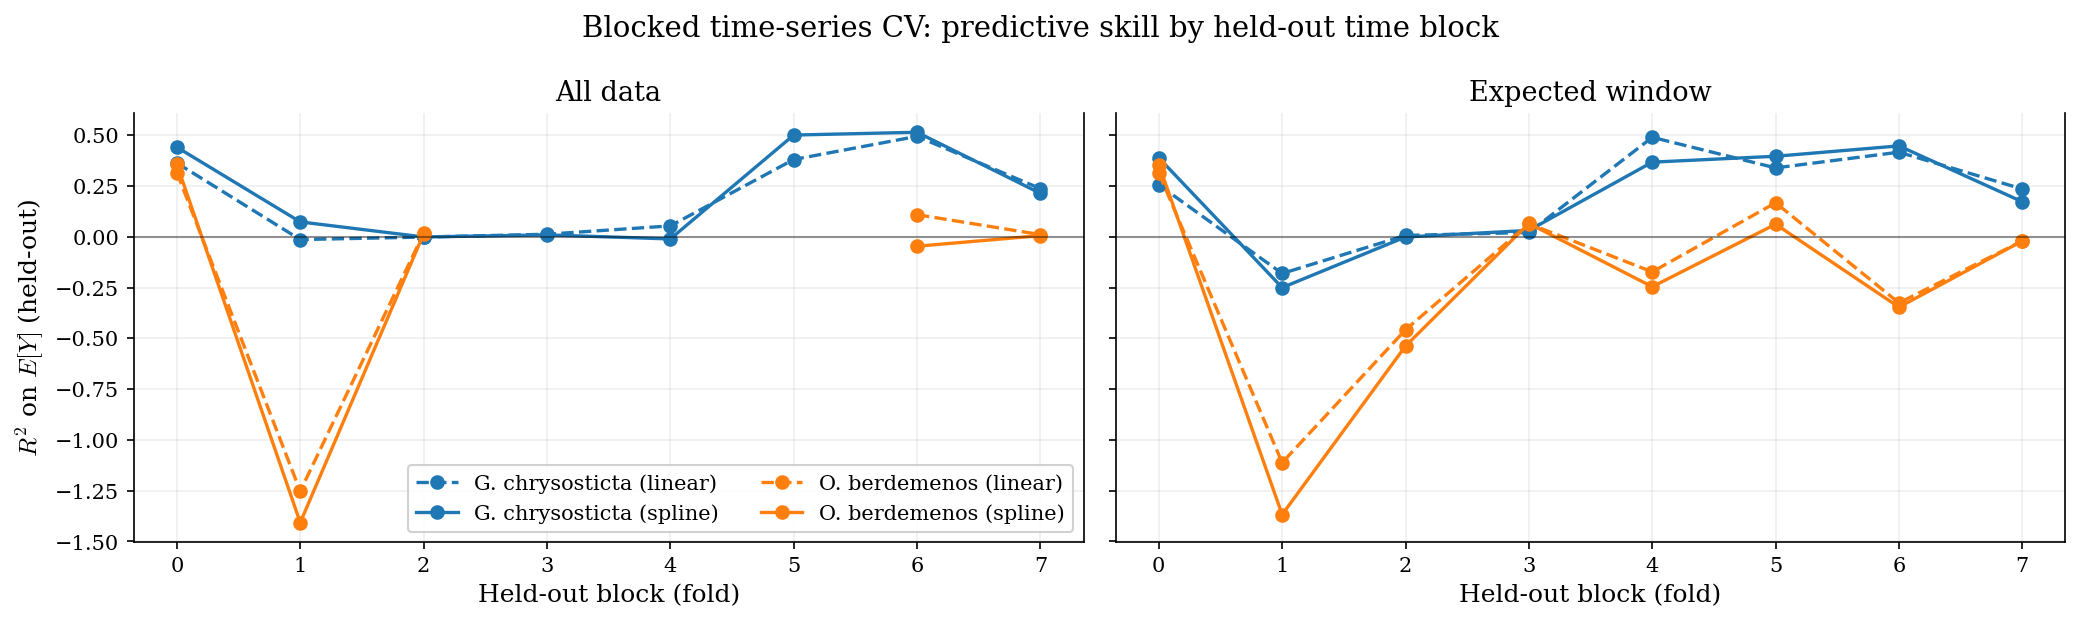

In [87]:
# Plot blocked CV R2 by fold (spline vs linear)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for ax, scope, ttl in zip(axes, ["all", "win"], ["All data", "Expected window"]):
    for sp in SPECIES:
        for tag, ls in [("linear", "--"), ("spline", "-")]:
            dd = cv[(cv["species"] == sp) & (cv["scope"] == scope) & (cv["tag"] == tag)].sort_values("fold")
            ax.plot(dd["fold"], dd["r2_expected"], marker="o", linewidth=1.6, linestyle=ls, color=SP_COLOR[sp], label=f"{SP_SHORT[sp]} ({tag})" if scope == "all" else None)
    ax.axhline(0, color="black", linewidth=1, alpha=0.4)
    ax.set_title(ttl)
    ax.set_xlabel("Held-out block (fold)")
    ax.set_xticks(sorted(cv[cv["scope"] == scope]["fold"].unique()))
    ax.grid(alpha=0.2)
axes[0].set_ylabel(r"$R^2$ on $E[Y]$ (held-out)")
axes[0].legend(framealpha=0.9, ncol=2)
fig.suptitle("Blocked time-series CV: predictive skill by held-out time block", fontsize=14)
fig.tight_layout()
savefig(fig, "blocked_cv_r2")
plt.show()

In [88]:
# Shared latent factor from raw calls
call_cols = ["Gastrotheca chrysosticta", "Oreobates berdemenos"]
Z = df[call_cols].dropna().copy()
Zs = (Z - Z.mean()) / Z.std(ddof=0)
U, S, Vt = np.linalg.svd(Zs.to_numpy(), full_matrices=False)
pc1 = U[:, 0] * S[0]
df.loc[Z.index, "latent_shared_pc1"] = pc1

m = df["latent_shared_pc1"].mean()
s = df["latent_shared_pc1"].std(ddof=0)
df["latent_shared_pc1_s"] = (df["latent_shared_pc1"] - m) / (s if s > 0 else 1.0)

joint_formula = (
    "0 + Temp + Q('RH%') + sin_h1 + cos_h1 + sin_h2 + cos_h2 + sin_d1 + cos_d1 + sin_d2 + cos_d2 + other_calling + latent_shared"
 )

def prep_model_df_joint(df_in: pd.DataFrame, y_col: str, other_call_col: str) -> pd.DataFrame:
    d = prep_model_df(df_in, y_col=y_col, other_call_col=other_call_col)
    d = d.dropna(subset=["latent_shared_pc1_s"]).copy()
    d["latent_shared"] = d["latent_shared_pc1_s"].astype(float)
    return d

fits_joint = {}
for sp in SPECIES:
    y_col = sp
    other_call_col = "oreo_calling" if sp == SPECIES[0] else "gastro_calling"
    base_df = get_species_df(sp)
    d_all = prep_model_df_joint(base_df, y_col=y_col, other_call_col=other_call_col)
    res_all, di_all = fit_ordered_logit(d_all, y_col=y_col, formula=joint_formula)
    d_win_src = base_df.copy()
    d_win = prep_model_df_joint(d_win_src, y_col=y_col, other_call_col=other_call_col)
    res_win, di_win = fit_ordered_logit(d_win, y_col=y_col, formula=joint_formula)
    fits_joint[sp] = {
        "all": {"res": res_all, "design": di_all, "df": d_all},
        "win": {"res": res_win, "design": di_win, "df": d_win},
    }

for sp in SPECIES:
    print("\n" + "="*90)
    print(sp, "(JOINT + shared latent; ALL DATA)")
    print(fits_joint[sp]["all"]["res"].summary())


Gastrotheca chrysosticta (JOINT + shared latent; ALL DATA)
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -618.82
Model:                   OrderedModel   AIC:                             1268.
Method:            Maximum Likelihood   BIC:                             1368.
Date:                Fri, 08 May 2026                                         
Time:                        17:30:18                                         
No. Observations:                5924                                         
Df Residuals:                    5909                                         
Df Model:                          12                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Temp              0.0511      0.031      1.648      0.099      -0

## 11. Joint model with shared latent activity
We approximate a shared latent driver by extracting the first principal component of the two raw call series and include it as a shared covariate.

In [89]:
# Shared latent factor from raw calls
call_cols = ["Gastrotheca chrysosticta", "Oreobates berdemenos"]
Z = df[call_cols].dropna().copy()
Zs = (Z - Z.mean()) / Z.std(ddof=0)
U, S, Vt = np.linalg.svd(Zs.to_numpy(), full_matrices=False)
pc1 = U[:, 0] * S[0]
df.loc[Z.index, "latent_shared_pc1"] = pc1

m = df["latent_shared_pc1"].mean()
s = df["latent_shared_pc1"].std(ddof=0)
df["latent_shared_pc1_s"] = (df["latent_shared_pc1"] - m) / (s if s > 0 else 1.0)

joint_formula = (
    "0 + Temp + RH% + sin_h1 + cos_h1 + sin_h2 + cos_h2 + sin_d1 + cos_d1 + sin_d2 + cos_d2 + other_calling + latent_shared"
 )

def prep_model_df_joint(df_in: pd.DataFrame, y_col: str, other_call_col: str) -> pd.DataFrame:
    d = prep_model_df(df_in, y_col=y_col, other_call_col=other_call_col)
    d = d.dropna(subset=["latent_shared_pc1_s"]).copy()
    d["latent_shared"] = d["latent_shared_pc1_s"].astype(float)
    return d

fits_joint = {}
for sp in SPECIES:
    y_col = sp
    other_call_col = "oreo_calling" if sp == SPECIES[0] else "gastro_calling"
    base_df = get_species_df(sp)
    d_all = prep_model_df_joint(base_df, y_col=y_col, other_call_col=other_call_col)
    res_all, di_all = fit_ordered_logit(d_all, y_col=y_col, formula=joint_formula)
    d_win_src = base_df.copy()
    d_win = prep_model_df_joint(d_win_src, y_col=y_col, other_call_col=other_call_col)
    res_win, di_win = fit_ordered_logit(d_win, y_col=y_col, formula=joint_formula)
    fits_joint[sp] = {
        "all": {"res": res_all, "design": di_all, "df": d_all},
        "win": {"res": res_win, "design": di_win, "df": d_win},
    }

for sp in SPECIES:
    print("\n" + "="*90)
    print(sp, "(JOINT + shared latent; ALL DATA)")
    print(fits_joint[sp]["all"]["res"].summary())

SyntaxError: invalid syntax (<unknown>, line 1)

## Notes / next steps
- If you want to refine the daylight window, replace the 10:00–17:00 rule with sunrise/sunset times.
- For a fully generative joint ordinal model, we can add a Bayesian multivariate ordinal model (PyMC) in a follow-up.

In [ ]:
# Presence / absence effect plot helper
# (added to produce a compact comparison: E[level] when other species absent vs present)

def plot_presence_effect(res, design_info, d: pd.DataFrame, tag: str, sp: str, scope: str, other_col: str):
    """Plot expected ordinal level E[level] when other species is absent vs present.

    Produces a compact bar + connector plot and saves using the numbered savefig helper.
    """
    # Make two copies with other_col forced to 0 and 1
    d0 = d.copy()
    d1 = d.copy()
    d0[other_col] = 0
    d1[other_col] = 1

    def expected_level_from_df(res_obj, di, df_in):
        # Build design matrix and get class probabilities
        X = dmatrix(di, df_in, return_type='dataframe')
        probs = res_obj.model.predict(res_obj.params, exog=X)
        # probs shape: (n_rows, n_classes); expected level is sum(p_k * k)
        classes = np.arange(1, probs.shape[1] + 1)
        return (probs * classes).sum(axis=1)

    e0 = expected_level_from_df(res, design_info, d0).mean()
    e1 = expected_level_from_df(res, design_info, d1).mean()

    fig, ax = plt.subplots(figsize=(4, 4))
    colors = [SP_COLOR.get(sp, '#333333'), '#888888']
    ax.bar([0, 1], [e0, e1], color=colors)
    ax.plot([0, 1], [e0, e1], marker='o', color='k')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Other absent', 'Other present'])
    ax.set_ylabel('E[level]')
    ax.set_title(f"Effect of other species on {sp.split()[0]} — {scope} — {tag}")
    delta = e1 - e0
    ax.annotate(f"Δ={delta:.2f}", xy=(0.5, max(e0, e1)), xytext=(0, 5), textcoords='offset points', ha='center')
    fname = f"presence_effect_{tag}_{sp.split()[0].lower()}_{scope}"
    savefig(fig, fname)
    plt.close(fig)


In [ ]:
plot_presence_effect(fits_joint[SPECIES[0]]["all"]["res"], fits_joint[SPECIES[0]]["all"]["design"], fits_joint[SPECIES[0]]["all"]["df"], tag="joint", sp=SPECIES[0], scope="all", other_col="other_calling")
plot_presence_effect(fits_joint[SPECIES[0]]["win"]["res"], fits_joint[SPECIES[0]]["win"]["design"], fits_joint[SPECIES[0]]["win"]["df"], tag="joint", sp=SPECIES[0], scope="win", other_col="other_calling")
plot_presence_effect(fits_joint[SPECIES[1]]["all"]["res"], fits_joint[SPECIES[1]]["all"]["design"], fits_joint[SPECIES[1]]["all"]["df"], tag="joint", sp=SPECIES[1], scope="all", other_col="other_calling")
plot_presence_effect(fits_joint[SPECIES[1]]["win"]["res"], fits_joint[SPECIES[1]]["win"]["design"], fits_joint[SPECIES[1]]["win"]["df"], tag="joint", sp=SPECIES[1], scope="win", other_col="other_calling")

KeyError: 'Gastrotheca chrysosticta'

In [ ]:
# Generate presence/absence E[level] plots for all fitted models
# This iterates over the stored fits and calls the helper added earlier.

def generate_all_presence_effects():
    # fits_linear and fits_spline hold entries keyed by (tag, sp, scope)
    for model_dict in (fits_linear, fits_spline):
        for key, info in model_dict.items():
            try:
                tag, sp, scope = key
                res = info['res']
                di = info['design_info']
                d = info.get('df', None) or info.get('d', None)
                if d is None:
                    print(f"No df for {key}, skipping")
                    continue
                other_col = 'oreo_calling' if sp.startswith('Gastro') else 'gastro_calling'
                plot_presence_effect(res, di, d, tag=tag, sp=sp, scope=scope, other_col=other_col)
            except Exception as e:
                print(f"Failed presence_effect for {key}: {e}")

# Run generation (comment/uncomment if you prefer to run manually)
# generate_all_presence_effects()


Failed presence_effect for Gastrotheca chrysosticta: too many values to unpack (expected 3)
Failed presence_effect for Oreobates berdemenos: too many values to unpack (expected 3)
Failed presence_effect for Gastrotheca chrysosticta: too many values to unpack (expected 3)
Failed presence_effect for Oreobates berdemenos: too many values to unpack (expected 3)
